# Data
### Both datasets consist of 2d rgb images representing visualized malicious activity

## 48240 dataset (malicious binaries/files etc)
https://ieee-dataport.org/documents/48240-malware-samples-and-binary-visualisation-images-machine-learning-anomaly-detection

## 913 dataset (malicious network traffic) 
https://ieee-dataport.org/open-access/913-malicious-network-traffic-pcaps-and-binary-visualisation-images-dataset

# Prerequisites
## Preferred Tensorflow version

In [32]:
import tensorflow as tf
print(tf.__version__)
!pip install tensorflow-gpu==2.10.0
#!pip install tensorflow[and-cuda]==2.12.0
# restart kernel after installation finishes, then its ready to train on the new version of tensorflow
# the tensorflow version 2.10 was the last to support gpu natively on windows, then starting from 2.11 and up on windows wsl is required for gpu allocation

2.10.0


# 0. Standard training
### The standard training procedure, training is done on the dataset's initial state, without applying any transforms and modifications to them

## 0.1. "Stock" dataset training on 48240 dataset

In [33]:
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
#from tensorflow import keras
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization,MaxPool2D
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam
from keras.regularizers import *
from keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from keras.initializers import he_normal  
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import time
print(tf.__version__)
#print(keras.__version__)
from PIL import ImageFont
import matplotlib.pyplot as plt
import random as rn
import os

start_time = time.time()
results = {}

#-------------
# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
setup_seed(42)
#------------

img_width, img_height = 32, 32
batch_size = 64  
epochs = 1
learn_rate = 0.01

#"""
# -- Creating custom model --
if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

model = Sequential()

# Reduce the size of the convolutional layers
model.add(Conv2D(8, (1, 1), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
#model.add(Dropout(0.1))

model.add(Conv2D(16, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2)) 
#model.add(Dropout(0.1))

model.add(Conv2D(32, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
#model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
#"""

"""
from tensorflow.keras.applications import MobileNetV3Small
#base_model = MobileNetV3Small(include_top=False, input_shape=(img_width,img_height, 3))
base_model = MobileNetV3Small(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
# Freeze all layers in the base model
for layer in base_model.layers:
    layer.trainable = False
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
# Ensure the classification layer is trainable
model.layers[-1].trainable = True
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
"""

"""
from tensorflow.keras.applications import MobileNetV3Large
base_model = MobileNetV3Large(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False
# Ensure the classification layer is trainable
model.layers[-1].trainable = True
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
"""

model.compile(optimizer=Adam(learning_rate=learn_rate), loss='binary_crossentropy', metrics=['accuracy'])
train_dataset = '/kaggle/input/data-48240-60-15-25/Data_48240_60_15_25/Training'
valid_dataset = '/kaggle/input/data-48240-60-15-25/Data_48240_60_15_25/Validation'
testing_path = '/kaggle/input/data-48240-60-15-25/Data_48240_60_15_25/Test'

train_generator = datagen.flow_from_directory(
   train_dataset,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True)
valid_generator = datagen.flow_from_directory(
    valid_dataset,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False)

#test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = datagen.flow_from_directory(
    testing_path, 
    target_size=(img_width, img_height), 
    batch_size=batch_size, 
    class_mode='binary', 
    shuffle=False)

lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',    # Monitor validation loss
    factor=0.3,            # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    patience=3,            # Number of epochs with no improvement after which learning rate will be reduced
    verbose=1,             # Provide output about learning rate changes
    min_lr=1e-8            # Minimum learning rate (optional) (1e-6 = 0.000001)
)

Early_Stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights='True',
    #min_delta=0.1
)

# Checkpoints, save best only true saves the ENTIRE MODEL + its weights, meaning if i wanna retrain i just load model
checkpoint = ModelCheckpoint("best_model.hdf5", monitor='val_loss', verbose=1, save_best_only=True, mode='min', period=1)
callbacks_list = [checkpoint,lr_schedule,Early_Stopping]

# -- Training --
history = model.fit(train_generator, steps_per_epoch=train_generator.n // batch_size, epochs=epochs, validation_data=valid_generator, validation_steps=valid_generator.n // batch_size, callbacks=callbacks_list)
# Loading best model
model.load_weights('best_model.hdf5')
# Evaluating model
valid_generator.reset()
Y_pred = model.predict(valid_generator, valid_generator.n // batch_size + 1)
y_pred = np.where(Y_pred > 0.5, 1, 0)
#model.summary()
print(f"\n-----\n{train_dataset}\n{valid_dataset}\n-----")
#target_names = ['Malware', 'Software']
#print(f"imgWidth = {img_width}, imgHeight = {img_height}\nepochs = {epochs}\nbatch size = {batch_size}\nlearning rate = {learn_rate}\n-----")
print('Confusion Matrix')
cm = confusion_matrix(valid_generator.classes, y_pred)
print(cm)
#print('Classification Report')
#print(classification_report(valid_generator.classes, y_pred, target_names=target_names,zero_division=1,digits=5))
TN, FP, FN, TP = cm.ravel()
print(f"True Positives  (actual Software) (TP): {TP}")
print(f"False Negatives (missed Software) (FN): {FN}")
print(f"True Negatives  (actual Malware)  (TN): {TN}")
print(f"False Positives (missed Malware)  (FP): {FP}")

target_names = ['Malware', 'Software']
print(f"\nimgWidth = {img_width}, imgHeight = {img_height}\nepochs = {epochs}\nbatch size = {batch_size}\nlearning rate = {learn_rate}")
#model.summary()
print('\nClassification Report')
print(classification_report(valid_generator.classes, y_pred, target_names=target_names,zero_division=1,digits=5))

tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True, 
                          show_dtype=False,show_layer_names=True, 
                          rankdir='TB', expand_nested=False, dpi=96)
#model.summary()
#import visualkeras
#visualkeras.layered_view(model, legend=True) 

# Plot training and validation loss and learning rate side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Plot Training and Validation Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot Learning Rate
axes[1].plot(history.history['lr'], label='Learning Rate', color='red')
axes[1].set_title('Learning Rate')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Learning Rate')
axes[1].legend()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

#testing
model.load_weights('best_model.hdf5')
# Predict classes
Y_pred_test = model.predict(test_generator, test_generator.samples // test_generator.batch_size+1)
test_labels = (Y_pred_test > 0.5).astype(int)
print(test_generator.class_indices)
cm = confusion_matrix(test_generator.classes, test_labels)
TN, FP, FN, TP = cm.ravel()
print("[[TN FP]\n[FN TP]]")
print(f"True Positives  (actual Software) (TP): {TP}")
print(f"False Negatives (missed Software) (FN): {FN}")
print(f"True Negatives  (actual Malware)  (TN): {TN}")
print(f"False Positives (missed Malware)  (FP): {FP}")
# Calculate precision, recall, and f1-score for Malware class
print("\nClassification report")
print(classification_report(test_generator.classes, test_labels, zero_division=1, target_names=target_names, digits=5))
report = classification_report(test_generator.classes, test_labels, digits=5, zero_division=1, output_dict=True)

# Extract overall metrics, for a binary classification with 'class_0' and 'class_1', class_0 = malware, class_1 = software
accuracy = report['accuracy']

# Extract metrics for each class
precision_class_0 = report['0']['precision']
recall_class_0 = report['0']['recall']
f1_score_class_0 = report['0']['f1-score']
support_class_0 = report['0']['support']
precision_class_1 = report['1']['precision']
recall_class_1 = report['1']['recall']
f1_score_class_1 = report['1']['f1-score']
support_class_1 = report['1']['support']

# Optionally extract macro/micro/weighted averages if available
macro_avg_precision = report['macro avg']['precision']
macro_avg_recall = report['macro avg']['recall']
macro_avg_f1 = report['macro avg']['f1-score']
weighted_avg_precision = report['weighted avg']['precision']
weighted_avg_recall = report['weighted avg']['recall']
weighted_avg_f1 = report['weighted avg']['f1-score']

results["init   -> stock"] = {
    #"region": region_identifier,
    "TP": TP,
    "TN": TN,
    "FP": FP,
    "FN": FN,
    "test_acc": round(accuracy,5),
    "precision": round(macro_avg_precision,5),
    "recall": round(macro_avg_recall,5),
    "f1_score": round(macro_avg_f1,5)
    #"init_test_acc": 
}
# print the whole dictionary 
for key,value in results.items():
    print(f"'{key}': {value},")
    
    
# calculate elapesed runtime
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60
runtime_hours = runtime_minutes / 60

print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")

2.10.0


FileNotFoundError: [WinError 3] The system cannot find the path specified: '/kaggle/input/data-48240-60-15-25/Data_48240_60_15_25/Training'

## 0.2. "Stock" dataset training on 913 dataset

In [ ]:
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
#from tensorflow import keras
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization,MaxPool2D
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam
from keras.regularizers import *
from keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from keras.initializers import he_normal  
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import time
print(tf.__version__)
#print(keras.__version__)
from PIL import ImageFont
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random as rn

#-------------
# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
setup_seed(41)
#------------

start_time = time.time()
results = {}

img_width, img_height = 256, 1024
batch_size = 32
epochs = 100
learn_rate = 0.001

#"""
# Creating model
if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

model = Sequential()

model.add(Conv2D(8, (1, 1), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
#model.add(Dropout(0.1))

model.add(Conv2D(16, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2)) 
#model.add(Dropout(0.1))

model.add(Conv2D(32, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001) ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
#model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
#"""

"""
from tensorflow.keras.applications import MobileNetV3Small
#base_model = MobileNetV3Small(include_top=False, input_shape=(img_width,img_height, 3))
base_model = MobileNetV3Small(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
# Freeze all layers in the base model
for layer in base_model.layers:
    layer.trainable = False
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
# Ensure the classification layer is trainable
model.layers[-1].trainable = True
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
"""

"""
from tensorflow.keras.applications import MobileNetV3Large
base_model = MobileNetV3Large(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
#base_model = MobileNetV3Large(weights=None,include_top=False,input_shape=(img_width,img_height, 3))

# Make sure the entire model is trainable
#base_model.trainable = True

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False
# Ensure the classification layer is trainable
model.layers[-1].trainable = True
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
"""

model.compile(optimizer=Adam(learning_rate=learn_rate), loss='binary_crossentropy', metrics=['accuracy'])


train_dataset = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20\\Training'
valid_dataset = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20\\Validation'
testing_path = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20\\Test'

train_generator = datagen.flow_from_directory(
   train_dataset,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True)
valid_generator = datagen.flow_from_directory(
    valid_dataset,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False)

test_generator = datagen.flow_from_directory(
    testing_path, 
    target_size=(img_width, img_height), 
    batch_size=batch_size, 
    class_mode='binary', 
    shuffle=False)

lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.5,            # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    patience=3,            # Number of epochs with no improvement after which learning rate will be reduced
    verbose=1,             # Provide output about learning rate changes
    min_lr=1e-6            # Minimum learning rate (optional) (1e-6 = 0.000001)
)

# Checkpoints
checkpoint = ModelCheckpoint("best_model.hdf5", monitor='val_loss', verbose=1, save_best_only=True, mode='min', period=1)
#callbacks_list = [checkpoint,lr_schedule]
callbacks_list = [checkpoint]

# -- Training --
history = model.fit(train_generator, steps_per_epoch=train_generator.n // batch_size, epochs=epochs, validation_data=valid_generator, validation_steps=valid_generator.n // batch_size, callbacks=callbacks_list)

# predicting on validation set
model.load_weights('best_model.hdf5') # Loading best model
valid_generator.reset()
Y_pred = model.predict(valid_generator, valid_generator.n // batch_size + 1)
y_pred = np.where(Y_pred > 0.5, 1, 0)
print(f"\n-----\n{train_dataset}\n{valid_dataset}\n-----")
target_names = ['Malware', 'Software']
print(f"imgWidth = {img_width}, imgHeight = {img_height}\nepochs = {epochs}\nbatch size = {batch_size}\nlearning rate = {learn_rate}\n-----")
print('Confusion Matrix')
print(confusion_matrix(valid_generator.classes, y_pred))
print('Classification Report')
print(classification_report(valid_generator.classes, y_pred, target_names=target_names,zero_division=1, digits=5))

#tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True,show_dtype=False,show_layer_names=True,rankdir='TB', expand_nested=False, dpi=96)
#model.summary()
#import visualkeras
#visualkeras.layered_view(model, legend=True) 

# -- Plot Training and Validation Loss --
# Plot training and validation loss and learning rate side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
# Plot Learning Rate
axes[1].plot(history.history['lr'], label='Learning Rate', color='red')
axes[1].set_title('Learning Rate')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Learning Rate')
axes[1].legend()
# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# -- Predict on the attack scenarios --
model.load_weights('best_model.hdf5')

y_pred_test_model = model.predict(test_generator, test_generator.n // batch_size + 1)
Y_pred_test = y_pred_test_model
y_pred_test_model = np.where(y_pred_test_model > 0.5, 1, 0)
#cm = confusion_matrix(test_generator.classes, test_labels)
#print(cm)
#print("test_labels: ",test_labels)
test_labels = y_pred_test_model
print(test_generator.class_indices)
summ = 0 
print("------------------")
for i in range (0,len(test_generator.filenames)):
    detection_status = "Undetected      " if y_pred_test_model[i] > 0.5 else "Detected Malware"
    print(detection_status,"-",test_labels[i],"-","{:.8f}".format(Y_pred_test[i][0])," - ",test_generator.filenames[i])
    summ = summ + Y_pred_test[i][0]
print("------------------")
print("-> Avg malware accuracy: ",summ/13)
    
# calculate elapesed runtime
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60
runtime_hours = runtime_minutes / 60

print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")

2.10.0
Found 696 images belonging to 2 classes.
Found 172 images belonging to 2 classes.
Found 13 images belonging to 1 classes.
Epoch 1/100
21/21 [==============================] - ETA: 0s - loss: 9.8558 - accuracy: 0.7726 
Epoch 1: val_loss improved from inf to 3.30246, saving model to best_model.hdf5
21/21 [==============================] - 6s 257ms/step - loss: 9.8558 - accuracy: 0.7726 - val_loss: 3.3025 - val_accuracy: 0.7000
Epoch 2/100
21/21 [==============================] - ETA: 0s - loss: 2.2410 - accuracy: 0.8554
Epoch 2: val_loss improved from 3.30246 to 0.42084, saving model to best_model.hdf5
21/21 [==============================] - 5s 252ms/step - loss: 2.2410 - accuracy: 0.8554 - val_loss: 0.4208 - val_accuracy: 0.8500
Epoch 3/100
21/21 [==============================] - ETA: 0s - loss: 0.5357 - accuracy: 0.8795
Epoch 3: val_loss did not improve from 0.42084
21/21 [==============================] - 5s 259ms/step - loss: 0.5357 - accuracy: 0.8795 - val_loss: 0.5199 - va

KeyboardInterrupt: 

# 1. Naive-DWT-Ensemble
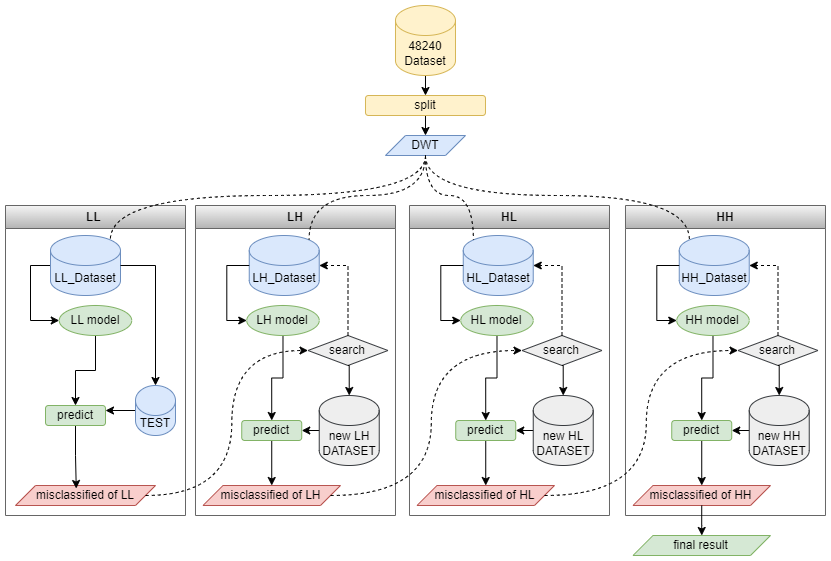

## 1.1. Naive-DWT-Ensemble on 48240 dataset (pretransformed DWT)
### works with versions 2.12 and 2.10 of tensorflow

In [ ]:

import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import numpy as np
#import tensorflow_decision_forests as tfdf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization,MaxPool2D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
from keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from keras.callbacks import Callback
import os
import shutil
from shutil import copyfile
import time
import random as rn
print(tf.__version__)
start_time = time.time()
results = {}
COUNT = 0
TP_COUNT=0
TN_COUNT=0


#-------------
# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
setup_seed(42)
#------------

def print_results(dictionairy):
    print("--------------")
    # Calculate the maximum width for each field
    max_widths = {}
    for key, value in dictionairy.items():
        for field, val in value.items():
            val_str = f"{val:.5f}" if isinstance(val, float) else str(val)
            if field not in max_widths:
                max_widths[field] = len(val_str)
            else:
                max_widths[field] = max(max_widths[field], len(val_str))

    # Print the results with consistent spacing
    for key, value in dictionairy.items():
        print(f"'{key}': {{", end="")
        for field, val in value.items():
            val_str = f"{val:.5f}" if isinstance(val, float) else str(val)
            print(f"'{field}': {val_str:<{max_widths[field]}}", end=", ")
        print("}")

def run_region_pipeline(img_width, img_height,batch_size,epochs,learn_rate,option,region_count,region, datasets,all_regions_length, previous_misclassified_folder=None, previous_region=None):
    training_path, validation_path, test_folder = datasets
    last_FP, last_FN = 0, 0
    initial_TP, initial_TN = 0,0
    print(f"-----{region}-----")
    last_region=""
    first_region=""
    
    model,datagen = run_cnn(img_width, img_height,batch_size,epochs,learn_rate,option,training_path, validation_path, region)

    if region_count==all_regions_length:
        last_region = region
    elif region_count==1:
        first_region = region
    
    isinitial=False
    print(f"-----testing on the initial test dataset-----")
    
    if region_count== 1:
        isinitial=True
        misclassified_folder = f'misclassified_folder_{region}'
        initial_TP, initial_TN = testing(datagen,isinitial,test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    else:
        misclassified_folder = f'init_misclassified_folder_{region}'
        isinitial=True
        testing(datagen,isinitial,test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    # for inbetween accs for each region separately, this does not count for the transfer learning
    #testing(test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region)
    
    misclassified_folder = f'misclassified_folder_{region}'
    if previous_misclassified_folder:
        search_folder = test_folder
        validation_of_misclassified = f"misclassified_from_{previous_region}_to_{region}"
        test_path = transfer_misclassified_to_next_region(f"_{previous_region}", f"_{region}", previous_misclassified_folder, search_folder, validation_of_misclassified)
        print(f"-----testing misclassified of {previous_region} in {region}-----")
        if(region_count==all_regions_length):
            isinitial=False
            last_FP, last_FN = testing(datagen,isinitial,test_path, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
        else:
            isinitial=False
            testing(datagen,isinitial,test_path, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    else:
        last_FP, last_FN = 0, 0
    
    if region_count== 1:
        return model, initial_TP, initial_TN, misclassified_folder, last_FP, last_FN
    else:
        return model, misclassified_folder, last_FP, last_FN

def custom(img_width,img_height):
    # Creating model
    if K.image_data_format() == 'channels_first':
        input_shape = (3, img_width, img_height)
    else:
        input_shape = (img_width, img_height, 3)

    model = Sequential()

    # Reduce the size of the convolutional layers
    model.add(Conv2D(8,  (1, 1), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))
    
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))

    model.add(Conv2D(32, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    outputs = model.add(Dense(1, activation='sigmoid'))
    
    return model,outputs
    #"""

def mobile_netv3_small(img_width,img_height):
    from tensorflow.keras.applications import MobileNetV3Small
    #base_model = MobileNetV3Small(include_top=False, input_shape=(img_width,img_height, 3))
    base_model = MobileNetV3Small(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze all layers in the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    return model, outputs 

def mobile_netv3_large(img_width,img_height):
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    
    return model, outputs 

def efficientnet(img_width,img_height):
    from tensorflow.keras.applications import EfficientNetV2L
    #tf.keras.backend.set_image_data_format('channels_last')
    base_model = EfficientNetV2L(include_top=False, input_shape=(img_width,img_height, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Freeze the layers of the base model
    #for layer in base_model.layers:
    #    layer.trainable = False
    return model, outputs 
    
def res_net(img_width,img_height):
    from tensorflow.keras.applications.resnet_v2 import ResNet50V2
    base_model = ResNet50V2(input_shape=(img_width,img_height,3), include_top=False) # include top = false better for transfer learning
    # Freeze all layers in the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    
    return model, outputs

def xception(img_width,img_height):
    from tensorflow.keras.applications import Xception
    #base_model = Xception(input_shape=(img_width,img_height,3), include_top=False)
    base_model = Xception(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    #for layer in base_model.layers:
    #    layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    model.layers[-1].trainable = True
    return model, outputs

def dense_net(img_width,img_height):
    from tensorflow.keras.applications import DenseNet121
    # -- stock densenet121 model --
    base_model = DenseNet121(input_shape=(img_width, img_height, 3), include_top=False)
    #for layer in base_model.layers:
    #    layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    #model.layers[-1].trainable = True
    return model, outputs

def dense_net_201(img_width,img_height):
    from tensorflow.keras.applications import DenseNet201
    # -- stock densenet121 model --
    #base_model = DenseNet201(input_shape=(img_width, img_height, 3), include_top=False)
    base_model = DenseNet201(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    for layer in base_model.layers:
        layer.trainable = False
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    model.layers[-1].trainable = True
    return model, outputs

def inceptionv3(img_width,img_height):
    from tensorflow.keras.applications import InceptionV3
    # -- stock densenet121 model --
    base_model = InceptionV3(input_shape=(img_width, img_height, 3), include_top=False)
    #for layer in base_model.layers:
    #    layer.trainable = False
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    #model.layers[-1].trainable = True
    return model, outputs

def vgg16(img_width,img_height):
    from tensorflow.keras.applications import VGG16
    # -- stock densenet121 model --
    base_model = VGG16(input_shape=(img_width, img_height, 3), include_top=False)
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return model, outputs

def random_forest(img_width,img_height):
    model = tfdf.keras.RandomForestModel()
    return model

def testing(datagen,isinitial,testing_path, model, imgWidth, imgHeight, batch_size, save_path, region_identifier,last_region,first_region,previous_region):
    global COUNT
    COUNT = COUNT+1
    global TP_COUNT
    global TN_COUNT
    
    TP,TN,FP,FN=0,0,0,0
    print(testing_path)
    if os.path.isdir(testing_path)==False:
        return FP,FN
    
    test_generator = datagen.flow_from_directory(
        testing_path, 
        target_size=(imgWidth, imgHeight), 
        batch_size=batch_size, 
        class_mode='binary', 
        shuffle=False)  # keep data in the same order as labels
    
    # Load best model
    model.load_weights(region_identifier+"_best_model.keras")
    # Predict classes
    Y_pred_test = model.predict(test_generator, test_generator.samples // test_generator.batch_size+1)
    test_labels = (Y_pred_test > 0.5).astype(int)
    filenames = test_generator.filenames
    #debug misclassified/classified samples
    #print("\n{:<60} | {:<12} | {:<6} | {:<14}".format('Filename', 'Prediction', 'Label', 'Status'))
    #print("{:<60} + {:<12} + {:<6} + {:<14}".format('-'*8, '-'*10, '-'*5, '-'*7))
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    else:
        shutil.rmtree(save_path)
    malwarepath = os.path.join(save_path, "Malware")
    softwarepath = os.path.join(save_path, "Software")
    os.makedirs(malwarepath, exist_ok=True)
    os.makedirs(softwarepath, exist_ok=True)
    
    misclassified_images = []  # Keeping track of misclassified images
    count = 0
    for i in range(len(filenames)):
        detection_status = "Software" if test_labels[i][0] == 1 else "Malware"
        #debug misclassified/classified samples
        #print(" "+"{:<60} | {:<12.6f} | {:<6d} | {:<14}".format(filenames[i], Y_pred_test[i][0], test_labels[i][0], detection_status))
        # Extract the folder from the path
        folder_path = os.path.dirname(filenames[i])

        #print("[+] folder path: ",folder_path," - detection_status: ",detection_status)
        # If the image is misclassified, add it to the list and copy it to the misclassified directory
        if folder_path != detection_status:
            # debugging print of misclassified
            #print(" "+"{:<60} | {:<12.6f} | {:<6d} | {:<14}".format(filenames[i], Y_pred_test[i][0], test_labels[i][0], detection_status))
            misclassified_images.append(filenames[i])
            # Construct the source and destination paths
            #print(filenames[i])
            src_path = os.path.join(testing_path, filenames[i])
            dst_path = os.path.join(save_path, filenames[i])
            shutil.copyfile(src_path, dst_path)
            #print(" src:",src_path,"\n"," dst:",dst_path)
            count = count + 1
        else:
            if isinitial == False:
                # TP = MALWARE = label -> 0, TN = SOFTWARE = label -> 1
                if detection_status == "Malware":
                    TP_COUNT = TP_COUNT+1
                else:
                    TN_COUNT = TN_COUNT+1

    #print("count:",count)
    print(test_generator.class_indices)
    cm = confusion_matrix(test_generator.classes, test_labels)
    print(cm)
    TN, FP, FN, TP = cm.ravel()
    print("[[TN FP]\n[FN TP]]")
    print(f"True Positives  (actual Software) (TP): {TP}")
    print(f"False Negatives (missed Software) (FN): {FN}")
    print(f"True Negatives  (actual Malware)  (TN): {TN}")
    print(f"False Positives (missed Malware)  (FP): {FP}")
    target_names = ['Malware','Software']
    print(classification_report(test_generator.classes, test_labels, zero_division=1, target_names=target_names, digits=5))
    report = classification_report(test_generator.classes, test_labels, digits=5, zero_division=1, output_dict=True)

    # Extract overall metrics, for a binary classification with 'class_0' and 'class_1', class_0 = malware, class_1 = software
    accuracy = report['accuracy']

    # Extract metrics for each class
    precision_class_0 = report['0']['precision']
    recall_class_0 = report['0']['recall']
    f1_score_class_0 = report['0']['f1-score']
    support_class_0 = report['0']['support']
    precision_class_1 = report['1']['precision']
    recall_class_1 = report['1']['recall']
    f1_score_class_1 = report['1']['f1-score']
    support_class_1 = report['1']['support']

    # Optionally extract macro/micro/weighted averages if available
    macro_avg_precision = report['macro avg']['precision']
    macro_avg_recall = report['macro avg']['recall']
    macro_avg_f1 = report['macro avg']['f1-score']
    weighted_avg_precision = report['weighted avg']['precision']
    weighted_avg_recall = report['weighted avg']['recall']
    weighted_avg_f1 = report['weighted avg']['f1-score']

    """
    # Print all the extracted metrics
    print(f"Accuracy: {accuracy}")

    print(f"\nClass 0 Metrics:")
    print(f"Precision: {precision_class_0}")
    print(f"Recall: {recall_class_0}")
    print(f"F1-Score: {f1_score_class_0}")
    print(f"Support: {support_class_0}")

    print(f"\nClass 1 Metrics:")
    print(f"Precision: {precision_class_1}")
    print(f"Recall: {recall_class_1}")
    print(f"F1-Score: {f1_score_class_1}")
    print(f"Support: {support_class_1}")

    print(f"\nMacro Average Metrics:")
    print(f"Precision: {macro_avg_precision}")
    print(f"Recall: {macro_avg_recall}")
    print(f"F1-Score: {macro_avg_f1}")

    print(f"\nWeighted Average Metrics:")
    print(f"Precision: {weighted_avg_precision}")
    print(f"Recall: {weighted_avg_recall}")
    print(f"F1-Score: {weighted_avg_f1}")
    """
    var="init"
    if isinitial==True:
        results[str(COUNT)+"_"+var+"   -> "+region_identifier] = {
            #"region": region_identifier,
             "TP": TP,
             "TN": TN,
             "FP": FP,
             "FN": FN,
             "test_acc": round(accuracy,5),
             "precision": round(macro_avg_precision,5),
             "recall": round(macro_avg_recall,5),
             "f1_score": round(macro_avg_f1,5)
        }
    else:
        results[str(COUNT)+"_"+str(previous_region)+"     -> "+region_identifier] = {
            #"region": region_identifier,
            "TP": TP,
            "TN": TN,
            "FP": FP,
            "FN": FN,
            "test_acc": round(accuracy,5),
            "precision": round(macro_avg_precision,5),
            "recall": round(macro_avg_recall,5),
            "f1_score": round(macro_avg_f1,5)
        }
    
    print("current region:",region_identifier)
    print("previous region: ",previous_region)
    
    for key,value in results.items():
        print(f"'{key}': {value},")
    
    if region_identifier == last_region:
        last_FN = cm[0][1]
        last_FP = cm[1][0]
        return last_FP,last_FN
    elif region_identifier == first_region:
        initial_TP = cm[0][0]
        initial_TN = cm[1][1]
        return initial_TP, initial_TN

def transfer_misclassified_to_next_region(previous_region,next_region,misclassified_folder,search_folder,validation_for_next_region):
    if not os.path.exists(validation_for_next_region):
        os.makedirs(validation_for_next_region)
    else:
        shutil.rmtree(validation_for_next_region)

    def extract_and_modify_filename(filename):
        extracted_string = filename.split(previous_region+".png")[0] # Extract the portion before "region.png"
        return extracted_string + next_region +".png"  # Append "next region" and return

    extracted_strings = [] # Create a list to store the extracted strings
    for root, _, files in os.walk(misclassified_folder):  # Walk through the misclassified folder
        for file in files:
            extracted_string = extract_and_modify_filename(file)
            #print("-> ",extracted_string)
            extracted_strings.append(extracted_string)
        
    print("misclassified samples length: ",len(extracted_strings))
    print("search folder: ",search_folder)
    # Walk through the search folder and copy matching files to the destination folder
    for root, _, files in os.walk(search_folder):
        for file in files:
            for extracted_string in extracted_strings:
                if extracted_string in file:
                    source_file_path = os.path.join(root, file)
                    destination_subfolder = os.path.join(validation_for_next_region, os.path.basename(root))
                    # Create the subfolder if it doesn't exist
                    if not os.path.exists(destination_subfolder):
                        os.makedirs(destination_subfolder)
                    # Copy the file to the appropriate subfolder
                    shutil.copy(source_file_path, os.path.join(destination_subfolder, file))

    return validation_for_next_region

def run_cnn(img_width, img_height,batch_size,epochs,learn_rate,option,training_path,validation_path,region_identifier):
    if (option=="densenet"):
        model,outputs = dense_net(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
    elif (option=="densenet_201"):
        model,outputs = dense_net_201(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
    elif (option=="resnet"):
        model,outputs = res_net(img_width,img_height)  
    elif (option=="mobile_netv3_small"):
        model,outputs = mobile_netv3_small(img_width,img_height)
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
    elif (option=="mobile_netv3_large"):
        model,outputs = mobile_netv3_large(img_width,img_height)
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
    elif (option=="efficientnet"):
        model,outputs = efficientnet(img_width,img_height)
    elif (option=="inceptionv3"):
        model,outputs = inceptionv3(img_width,img_height)
    elif (option=="custom"):
        model,outputs = custom(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
        #train_datagen = ImageDataGenerator(rescale=1. / 255)
        #valid_datagen = ImageDataGenerator(rescale=1. / 255)
    elif (option=="vgg16"):
        model,outputs = vgg16(img_width,img_height)
    elif (option=="xception"):
        from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=xception_preprocess_input)
        model,outputs = xception(img_width,img_height)
    
    model.compile(optimizer=Adam(learning_rate=learn_rate), loss='binary_crossentropy', metrics=['accuracy'])

    train_generator = datagen.flow_from_directory(
        training_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True)

    valid_generator = datagen.flow_from_directory(
        validation_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False)
    
    lr_schedule = ReduceLROnPlateau(
        monitor='val_loss',  # Monitor validation loss
        factor=0.3,            # Factor by which the learning rate will be reduced (new_lr = lr * factor)
        patience=3,            # Number of epochs with no improvement after which learning rate will be reduced
        verbose=1,             # Provide output about learning rate changes
        min_lr=1e-6            # Minimum learning rate (optional) (1e-6 = 0.000001)
    )
    
    Early_Stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        verbose=1,
        restore_best_weights='True',
        #min_delta=0.1
    )

    # Checkpoints
    checkpoint = ModelCheckpoint(region_identifier+"_best_model.keras", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    callbacks_list = [checkpoint,lr_schedule]

    # Training
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.n // batch_size,
        epochs=epochs,
        validation_data=valid_generator,
        validation_steps=valid_generator.n // batch_size,
        callbacks=[callbacks_list]
    )

    # Evaluating model
    model.load_weights(region_identifier+"_best_model.keras") # Loading best model
    valid_generator.reset()
    Y_pred = model.predict(valid_generator, valid_generator.n // batch_size + 1)
    y_pred = np.where(Y_pred > 0.5, 1, 0)
    cm = confusion_matrix(valid_generator.classes, y_pred)
    print('Confusion Matrix')
    print(cm)
    TN, FP, FN, TP = cm.ravel()
    print("[[TN FP]\n[FN TP]]")
    print(f"True Positives  (actual Software) (TP): {TP}")
    print(f"False Negatives (missed Software) (FN): {FN}")
    print(f"True Negatives  (actual Malware)  (TN): {TN}")
    print(f"False Positives (missed Malware)  (FP): {FP}")
    print('Classification Report')
    target_names = ['Malware', 'Software']
    print(f"\nimgWidth = {img_width}, imgHeight = {img_height}\nepochs = {epochs}\nbatch size = {batch_size}\nlearning rate = {learn_rate}")
    #model.summary()
    print(classification_report(valid_generator.classes, y_pred, target_names=target_names,zero_division=1,digits=5))
    
    # Plot training and validation loss and learning rate side by side
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
    # Plot Training and Validation Loss
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    # Plot Learning Rate
    axes[1].plot(history.history['lr'], label='Learning Rate', color='red')
    axes[1].set_title('Learning Rate')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Learning Rate')
    axes[1].legend()
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

    return model,datagen

#------------------ main ----------
start_time = time.time()

#img_width, img_height = 32,32
#batch_size = 64
#epochs = 1
#learn_rate = 0.001
#learn_rate = 0.0001 #-> good for epochs = 15 and higher, 25epochs -> 85 tescc
#learn_rate = 0.000001
#option="resnet"
#option="densenet"
#option="densenet_201"
#option="mobile_netv3_small"
#option="efficientnet"
#option="custom"
#option="inceptionv3"
#option="vgg16"
#option="mobile_netv3_large"
#option="xception"

# Define datasets for each region
#"""
datasets_dict = {
    "LL": ['/kaggle/input/data-48240-db2-lvl1-ll-60-15-25/Data_48240_db2_lvl1_LL_60_15_25/Training',
           '/kaggle/input/data-48240-db2-lvl1-ll-60-15-25/Data_48240_db2_lvl1_LL_60_15_25/Validation',
           '/kaggle/input/data-48240-db2-lvl1-ll-60-15-25/Data_48240_db2_lvl1_LL_60_15_25/Test'],
    "LH": ['/kaggle/input/data-48240-db2-lvl1-lh-60-15-25/Data_48240_db2_lvl1_LH_60_15_25/Training',
           '/kaggle/input/data-48240-db2-lvl1-lh-60-15-25/Data_48240_db2_lvl1_LH_60_15_25/Validation',
           '/kaggle/input/data-48240-db2-lvl1-lh-60-15-25/Data_48240_db2_lvl1_LH_60_15_25/Test'],
    "HL": ['/kaggle/input/data-48240-db2-lvl1-hl-60-15-25/Data_48240_db2_lvl1_HL_60_15_25/Training',
           '/kaggle/input/data-48240-db2-lvl1-hl-60-15-25/Data_48240_db2_lvl1_HL_60_15_25/Validation',
           '/kaggle/input/data-48240-db2-lvl1-hl-60-15-25/Data_48240_db2_lvl1_HL_60_15_25/Test'],
    "HH": ['/kaggle/input/data-48240-db2-lvl1-hh-60-15-25/Data_48240_db2_lvl1_HH_60_15_25/Training',
           '/kaggle/input/data-48240-db2-lvl1-hh-60-15-25/Data_48240_db2_lvl1_HH_60_15_25/Validation',
           '/kaggle/input/data-48240-db2-lvl1-hh-60-15-25/Data_48240_db2_lvl1_HH_60_15_25/Test']
}
#"""

#regions = ["LL","LL","LL","LL"] 
regions = ["LL","LH","HL","HH"] 
# TODO NEXT BELOW
#regions = ["LL", "LH", "HL", "HH","LL", "LH", "HL", "HH","LL", "LH", "HL", "HH"]
model0 = {"model": ["densenet"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model1 = {"model": ["densenet_201"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model2 = {"model": ["xception"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model3 = {"model": ["resnet"],"epochs": [1],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model4 = {"model": ["inceptionv3"],"epochs": [1],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}

#--------------
regions = ["LL","LH","HL","HH"] 
model5 = {"model": ["mobile_netv3_large"],"epochs": [30],"learn_rate": [0.01],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model6 = {"model": ["mobile_netv3_small"],"epochs": [30],"learn_rate": [0.01],"batch_size" : [64],"img_width": [128],"img_height": [128]}

model7 = {"model": ["custom"],"epochs": [1],"learn_rate": [0.01],"batch_size" : [64],"img_width": [128],"img_height": [128]}

#models_to_train = [model4,model1,model2,model3]
# TODO NEXT BELOW
models_to_train = [model7,model7,model7,model7]

for i in models_to_train:
    print(i)
all_regions_length = len(regions)
print("all regions count: ",all_regions_length)
# manage regions at first gets initial_TP, initial_TN, and in the end of the procedure we get the last_FP, last_FN which is what we need for the final confusion matrix and final classification report
initial_TP, initial_TN, last_FP, last_FN = 0, 0, 0, 0
previous_misclassified_folder = None
previous_region = None
region_count = 0
models_index = 0
for region in regions:
    region_count = region_count + 1
    dataset = datasets_dict[region]
    if (region_count==1):
        #models_to_train[models_index]["img_width"], models_to_train[models_index]["img_height"],models_to_train[models_index]["batch_size"],models_to_train[models_index]["epochs"],models_to_train[models_index]["learn_rate"],models_to_train[models_index]["model"][0]
        
        model, initial_TP, initial_TN, previous_misclassified_folder, last_FP, last_FN = run_region_pipeline(
            models_to_train[models_index]["img_width"][0], models_to_train[models_index]["img_height"][0],models_to_train[models_index]["batch_size"][0],models_to_train[models_index]["epochs"][0],models_to_train[models_index]["learn_rate"][0],models_to_train[models_index]["model"][0],region_count,region, dataset,all_regions_length, previous_misclassified_folder, previous_region)
        models_index = models_index +1 
    else:
        model, previous_misclassified_folder, last_FP, last_FN = run_region_pipeline(
            models_to_train[models_index]["img_width"][0], models_to_train[models_index]["img_height"][0],models_to_train[models_index]["batch_size"][0],models_to_train[models_index]["epochs"][0],models_to_train[models_index]["learn_rate"][0],models_to_train[models_index]["model"][0],region_count,region, dataset,all_regions_length, previous_misclassified_folder, previous_region)
        models_index = models_index +1 
    previous_region = region

# Generate the overall report
last_TP = initial_TP + TP_COUNT
last_TN = initial_TN + TN_COUNT
print("-------------[ OVERALL REPORT ]--------------")
final_confusion_matrix = tf.constant([[last_TN, last_FP],
                  [last_FN, last_TP]])
print(final_confusion_matrix)
print("Final True Positives   (actual Software): ", last_TN)
print("Final True Negatives   (actual Malware) : ", last_TP)
print("Final False Negatives: (missed Software): ", last_FP)
print("Final False Positives: (missed Malware) : ", last_FN)
#final_confusion_matrix = np.array([[last_TP, last_FP], [last_FN, last_TN]])
#print(final_confusion_matrix)

# Calculate precision, recall, and f1-score for Malware class
precision_malware = last_TP / (last_TP + last_FP)
recall_malware = last_TP / (last_TP + last_FN)
f1_score_malware = 2 * (precision_malware * recall_malware) / (precision_malware + recall_malware)
# Calculate precision, recall, and f1-score for Software class
precision_software = last_TN / (last_TN + last_FN)
recall_software = last_TN / (last_TN + last_FP)
f1_score_software = 2 * (precision_software * recall_software) / (precision_software + recall_software)
print('Classification Report')
print('                    precision    recall    f1-score   support')
print()
print('     Malware       {:.5f}      {:.5f}      {:.5f}       {}'.format(precision_malware, recall_malware, f1_score_malware, np.sum(final_confusion_matrix[0, :])))
print('     Software      {:.5f}      {:.5f}      {:.5f}       {}'.format(precision_software, recall_software, f1_score_software, np.sum(final_confusion_matrix[1, :])))
print()
accuracy = (last_TP + last_TN) / np.sum(final_confusion_matrix)
print('    accuracy                                 {:.5f}    {}'.format(accuracy, np.sum(final_confusion_matrix)))
print('   macro avg       {:.5f}      {:.5f}      {:.5f}       {}'.format((precision_malware + precision_software) / 2, (recall_malware + recall_software) / 2, (f1_score_malware + f1_score_software) / 2, np.sum(final_confusion_matrix)))
print('weighted avg       {:.5f}      {:.5f}      {:.5f}       {}'.format((last_TP * precision_malware + last_TN * precision_software) / np.sum(final_confusion_matrix), (last_TP * recall_malware + last_TN * recall_software) / np.sum(final_confusion_matrix), (last_TP * f1_score_malware + last_TN * f1_score_software) / np.sum(final_confusion_matrix), np.sum(final_confusion_matrix)))

#macro avg
macro_avg_precision = (precision_malware + precision_software) / 2
macro_avg_recall = (recall_malware + recall_software) / 2
macro_avg_f1_score = (f1_score_malware + f1_score_software) / 2
# insert the final results in the dictionairy
results["final         "] = {
    #"region": region_identifier,
    "TP": last_TP,
    "TN": last_TN,
    "FP": last_FP,
    "FN": last_FN,
    "test_acc": round(accuracy,5),
    "precision": round(macro_avg_precision,5),
    "recall": round(macro_avg_recall,5),
    "f1_score": round(macro_avg_f1_score,5)
    #"init_test_acc": 
}

print("\n")
#print("model: ",option)
#print("epochs: ",epochs)
# print the whole dictionary 
#for key,value in results.items():
#    print(f"'{key}': {value},")

for i in models_to_train:
    print(i)

print_results(results)

# Calculate elapsed runtime
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60
runtime_hours = runtime_minutes / 60
print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")

## 1.2. Naive-DWT-Ensemble on 913 dataset (pretransformed DWT)

2.10.0
{'model': ['custom'], 'epochs': [5], 'learn_rate': [0.001], 'batch_size': [64], 'img_width': [32], 'img_height': [32]}
{'model': ['custom'], 'epochs': [5], 'learn_rate': [0.001], 'batch_size': [64], 'img_width': [32], 'img_height': [32]}
{'model': ['custom'], 'epochs': [5], 'learn_rate': [0.001], 'batch_size': [64], 'img_width': [32], 'img_height': [32]}
{'model': ['custom'], 'epochs': [5], 'learn_rate': [0.001], 'batch_size': [64], 'img_width': [32], 'img_height': [32]}
all regions count:  4
-----LL-----
Found 696 images belonging to 2 classes.
Found 172 images belonging to 2 classes.
Epoch 1/5
10/10 [==============================] - ETA: 0s - loss: 0.5899 - accuracy: 0.7468
Epoch 1: val_loss improved from inf to 0.68771, saving model to LL_best_model.keras
10/10 [==============================] - 4s 338ms/step - loss: 0.5899 - accuracy: 0.7468 - val_loss: 0.6877 - val_accuracy: 0.6406 - lr: 0.0010
Epoch 2/5
10/10 [==============================] - ETA: 0s - loss: 0.3682 - acc

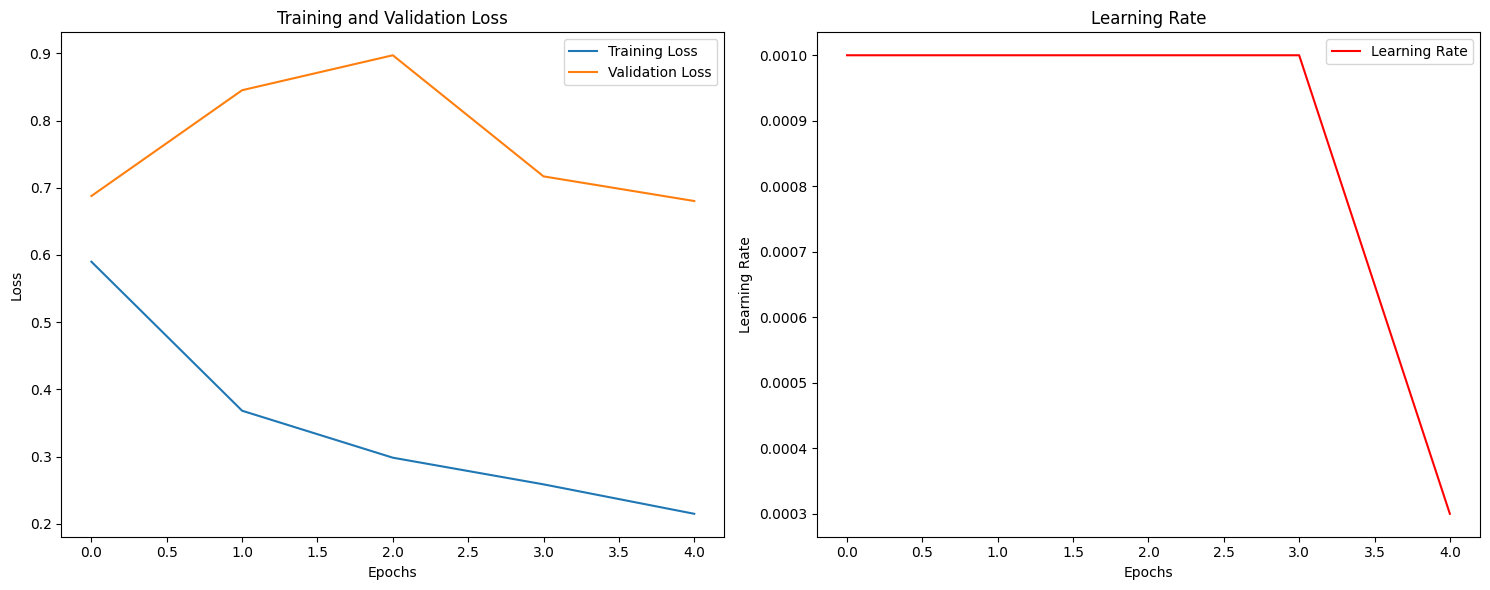

-----testing on the initial test dataset-----
/kaggle/input/data913-80-20-db2-lvl1-ll/data913_80_20_db2_lvl1_LL/Test
Found 13 images belonging to 1 classes.
1/1 [==============================] - 0s 196ms/step
{'malware': 0}
------------------
Undetected       - [1] - 0.69195586  -  malware/0day_LL.png
Undetected       - [1] - 0.67329407  -  malware/blackEnergy_LL.png
Undetected       - [1] - 0.74603623  -  malware/distcc_exec_backdoor_LL.png
Undetected       - [1] - 0.60892391  -  malware/hydra_ftp_LL.png
Undetected       - [1] - 0.60880852  -  malware/hydra_ssh_LL.png
Undetected       - [1] - 0.63908392  -  malware/java_rmi_LL.png
Undetected       - [1] - 0.77365756  -  malware/mirai_LL.png
Undetected       - [1] - 0.61187762  -  malware/netbios_ssn_LL.png
Undetected       - [1] - 0.67147881  -  malware/ruby_drb_LL.png
Undetected       - [1] - 0.67466384  -  malware/smtp_LL.png
Detected Malware - [0] - 0.38881388  -  malware/tomcat_LL.png
Undetected       - [1] - 0.68046671  -  malwa

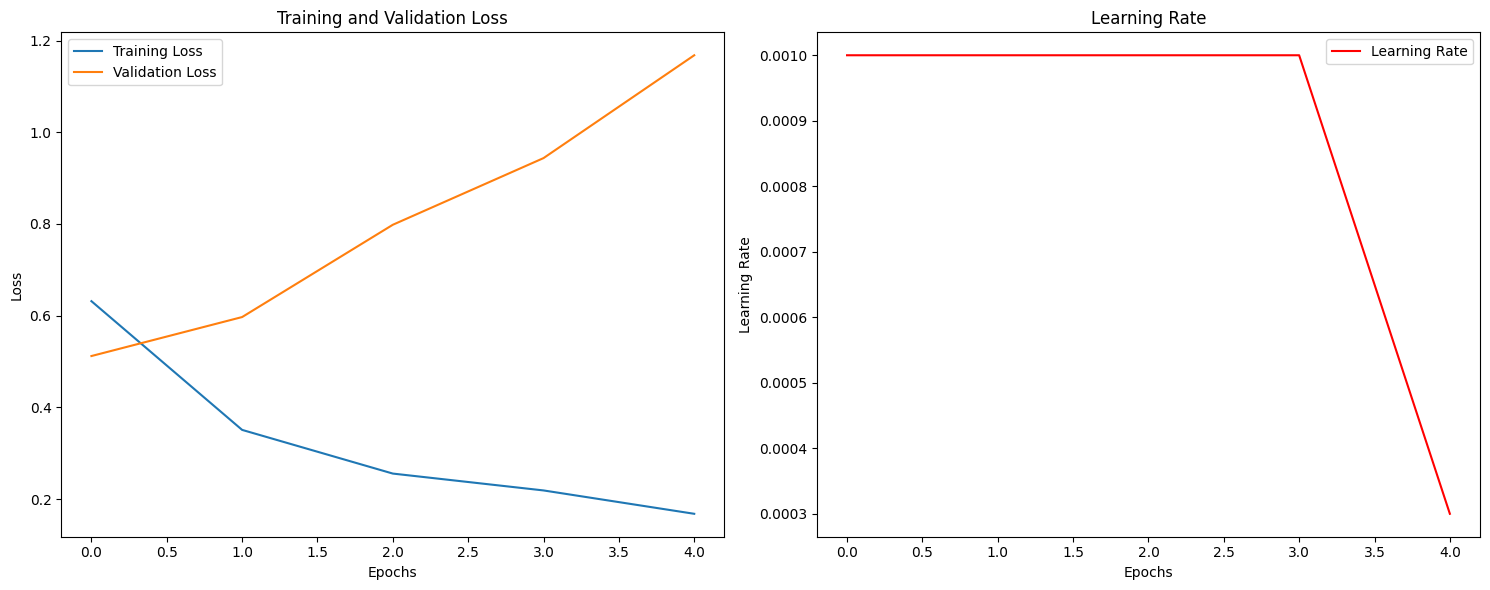

-----testing on the initial test dataset-----
/kaggle/input/data913-80-20-db2-lvl1-lh/data913_80_20_db2_lvl1_LH/Test
Found 13 images belonging to 1 classes.
1/1 [==============================] - 0s 149ms/step
{'malware': 0}
------------------
Detected Malware - [0] - 0.46156293  -  malware/0day_LH.png
Detected Malware - [0] - 0.49462453  -  malware/blackEnergy_LH.png
Undetected       - [1] - 0.53434420  -  malware/distcc_exec_backdoor_LH.png
Detected Malware - [0] - 0.29329258  -  malware/hydra_ftp_LH.png
Detected Malware - [0] - 0.35008228  -  malware/hydra_ssh_LH.png
Detected Malware - [0] - 0.35351935  -  malware/java_rmi_LH.png
Undetected       - [1] - 0.50867987  -  malware/mirai_LH.png
Detected Malware - [0] - 0.35975534  -  malware/netbios_ssn_LH.png
Detected Malware - [0] - 0.34007204  -  malware/ruby_drb_LH.png
Detected Malware - [0] - 0.45288771  -  malware/smtp_LH.png
Detected Malware - [0] - 0.33269125  -  malware/tomcat_LH.png
Detected Malware - [0] - 0.36770064  -  malwa

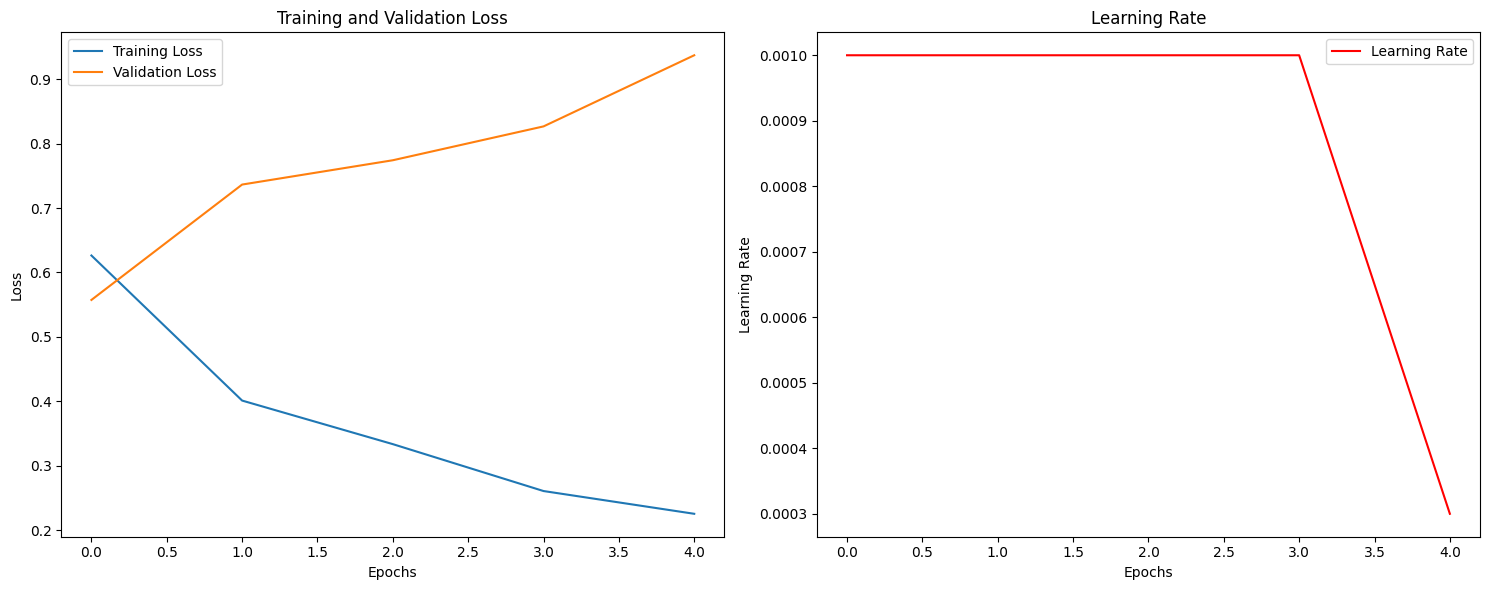

-----testing on the initial test dataset-----
/kaggle/input/data913-80-20-db2-lvl1-hl/data913_80_20_db2_lvl1_HL/Test
Found 13 images belonging to 1 classes.
1/1 [==============================] - 0s 163ms/step
{'malware': 0}
------------------
Detected Malware - [0] - 0.43134293  -  malware/0day_HL.png
Detected Malware - [0] - 0.41657370  -  malware/blackEnergy_HL.png
Detected Malware - [0] - 0.40234545  -  malware/distcc_exec_backdoor_HL.png
Detected Malware - [0] - 0.29739043  -  malware/hydra_ftp_HL.png
Detected Malware - [0] - 0.31595531  -  malware/hydra_ssh_HL.png
Detected Malware - [0] - 0.33826727  -  malware/java_rmi_HL.png
Detected Malware - [0] - 0.42563766  -  malware/mirai_HL.png
Detected Malware - [0] - 0.33633646  -  malware/netbios_ssn_HL.png
Detected Malware - [0] - 0.35960248  -  malware/ruby_drb_HL.png
Detected Malware - [0] - 0.39702874  -  malware/smtp_HL.png
Detected Malware - [0] - 0.41302460  -  malware/tomcat_HL.png
Detected Malware - [0] - 0.33157551  -  malwa

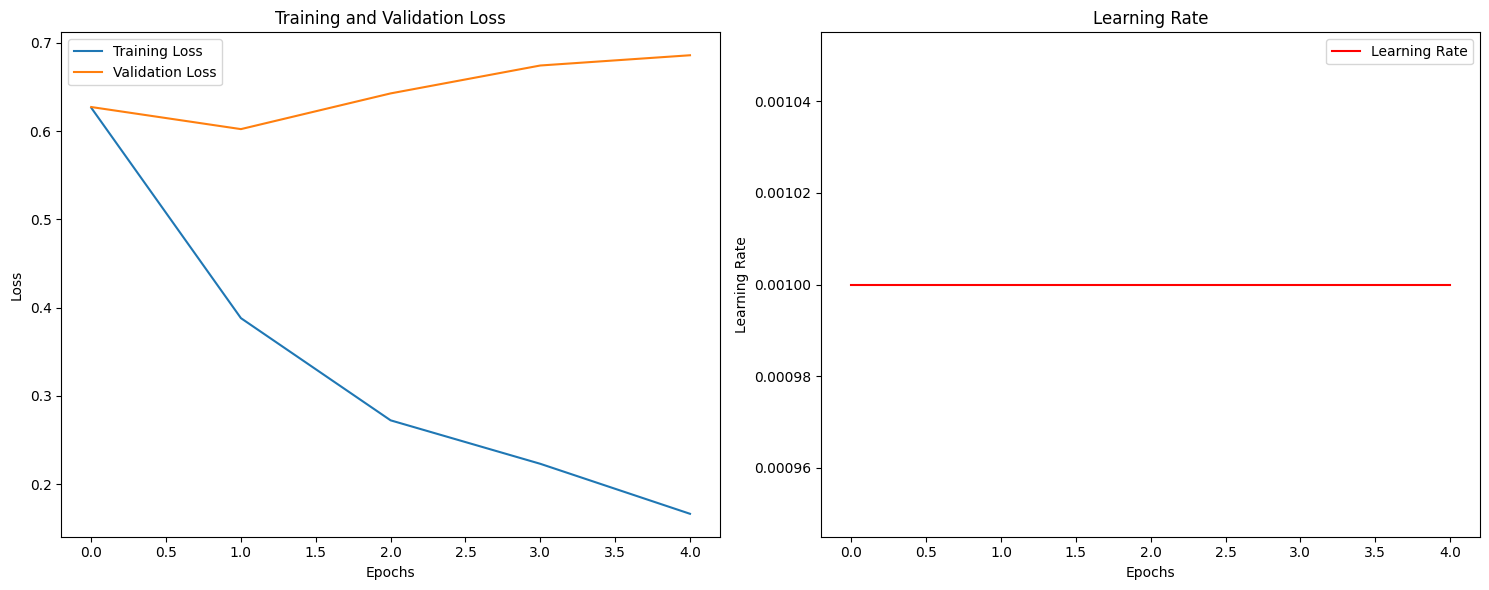

-----testing on the initial test dataset-----
/kaggle/input/data913-80-20-db2-lvl1-hh/data913_80_20_db2_lvl1_HH/Test
Found 13 images belonging to 1 classes.
1/1 [==============================] - 0s 137ms/step
{'malware': 0}
------------------
Detected Malware - [0] - 0.46565309  -  malware/0day_HH.png
Detected Malware - [0] - 0.48154676  -  malware/blackEnergy_HH.png
Detected Malware - [0] - 0.46454802  -  malware/distcc_exec_backdoor_HH.png
Detected Malware - [0] - 0.39818591  -  malware/hydra_ftp_HH.png
Detected Malware - [0] - 0.41220719  -  malware/hydra_ssh_HH.png
Detected Malware - [0] - 0.42293021  -  malware/java_rmi_HH.png
Detected Malware - [0] - 0.49038374  -  malware/mirai_HH.png
Detected Malware - [0] - 0.41238415  -  malware/netbios_ssn_HH.png
Detected Malware - [0] - 0.40633252  -  malware/ruby_drb_HH.png
Detected Malware - [0] - 0.42472661  -  malware/smtp_HH.png
Detected Malware - [0] - 0.41210157  -  malware/tomcat_HH.png
Detected Malware - [0] - 0.44690198  -  malwa

In [ ]:

import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import numpy as np
#import tensorflow_decision_forests as tfdf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization,MaxPool2D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
from keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from keras.callbacks import Callback
import os
import shutil
from shutil import copyfile
import time
import random as rn
print(tf.__version__)
start_time = time.time()
results = {}
COUNT = 0
TP_COUNT=0
TN_COUNT=0


#-------------
# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
setup_seed(42)
#------------

def print_results(dictionairy):
    print("--------------")
    # Calculate the maximum width for each field
    max_widths = {}
    for key, value in dictionairy.items():
        for field, val in value.items():
            val_str = f"{val:.5f}" if isinstance(val, float) else str(val)
            if field not in max_widths:
                max_widths[field] = len(val_str)
            else:
                max_widths[field] = max(max_widths[field], len(val_str))

    # Print the results with consistent spacing
    for key, value in dictionairy.items():
        print(f"'{key}': {{", end="")
        for field, val in value.items():
            val_str = f"{val:.5f}" if isinstance(val, float) else str(val)
            print(f"'{field}': {val_str:<{max_widths[field]}}", end=", ")
        print("}")

def run_region_pipeline(img_width, img_height,batch_size,epochs,learn_rate,option,region_count,region, datasets,all_regions_length, previous_misclassified_folder=None, previous_region=None):
    training_path, validation_path, test_folder = datasets
    last_FP, last_FN = 0, 0
    initial_TP, initial_TN = 0,0
    print(f"-----{region}-----")
    last_region=""
    first_region=""
    
    model,datagen = run_cnn(img_width, img_height,batch_size,epochs,learn_rate,option,training_path, validation_path, region)

    if region_count==all_regions_length:
        last_region = region
    elif region_count==1:
        first_region = region
    
    isinitial=False
    print(f"-----testing on the initial test dataset-----")
    
    if region_count== 1:
        isinitial=True
        misclassified_folder = f'misclassified_folder_{region}'
        initial_TP, initial_TN = testing(datagen,isinitial,test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    else:
        misclassified_folder = f'init_misclassified_folder_{region}'
        isinitial=True
        testing(datagen,isinitial,test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    # for inbetween accs for each region separately, this does not count for the transfer learning
    #testing(test_folder, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region)
    
    misclassified_folder = f'misclassified_folder_{region}'
    if previous_misclassified_folder:
        search_folder = test_folder
        validation_of_misclassified = f"misclassified_from_{previous_region}_to_{region}"
        test_path = transfer_misclassified_to_next_region(f"_{previous_region}", f"_{region}", previous_misclassified_folder, search_folder, validation_of_misclassified)
        print(f"-----testing misclassified of {previous_region} in {region}-----")
        if(region_count==all_regions_length):
            isinitial=False
            last_FP, last_FN = testing(datagen,isinitial,test_path, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
        else:
            isinitial=False
            testing(datagen,isinitial,test_path, model, img_width, img_height, batch_size, misclassified_folder, region,last_region,first_region,previous_region)
    else:
        last_FP, last_FN = 0, 0
    
    if region_count== 1:
        return model, initial_TP, initial_TN, misclassified_folder, last_FP, last_FN
    else:
        return model, misclassified_folder, last_FP, last_FN

def custom(img_width,img_height):
    # Creating model
    if K.image_data_format() == 'channels_first':
        input_shape = (3, img_width, img_height)
    else:
        input_shape = (img_width, img_height, 3)

    model = Sequential()

    # Reduce the size of the convolutional layers
    model.add(Conv2D(8,  (1, 1), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))
    
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))

    model.add(Conv2D(32, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
    #model.add(Dropout(0.1))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    outputs = model.add(Dense(1, activation='sigmoid'))
    
    return model,outputs
    #"""

def mobile_netv3_small(img_width,img_height):
    from tensorflow.keras.applications import MobileNetV3Small
    #base_model = MobileNetV3Small(include_top=False, input_shape=(img_width,img_height, 3))
    base_model = MobileNetV3Small(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze all layers in the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    return model, outputs 

def mobile_netv3_large(img_width,img_height):
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    
    return model, outputs 

def efficientnet(img_width,img_height):
    from tensorflow.keras.applications import EfficientNetV2L
    #tf.keras.backend.set_image_data_format('channels_last')
    base_model = EfficientNetV2L(include_top=False, input_shape=(img_width,img_height, 3))
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Freeze the layers of the base model
    #for layer in base_model.layers:
    #    layer.trainable = False
    return model, outputs 
    
def res_net(img_width,img_height):
    from tensorflow.keras.applications.resnet_v2 import ResNet50V2
    base_model = ResNet50V2(input_shape=(img_width,img_height,3), include_top=False) # include top = false better for transfer learning
    # Freeze all layers in the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    
    return model, outputs

def xception(img_width,img_height):
    from tensorflow.keras.applications import Xception
    #base_model = Xception(input_shape=(img_width,img_height,3), include_top=False)
    base_model = Xception(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    #for layer in base_model.layers:
    #    layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    model.layers[-1].trainable = True
    return model, outputs

def dense_net(img_width,img_height):
    from tensorflow.keras.applications import DenseNet121
    # -- stock densenet121 model --
    base_model = DenseNet121(input_shape=(img_width, img_height, 3), include_top=False)
    #for layer in base_model.layers:
    #    layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    #model.layers[-1].trainable = True
    return model, outputs

def dense_net_201(img_width,img_height):
    from tensorflow.keras.applications import DenseNet201
    # -- stock densenet121 model --
    #base_model = DenseNet201(input_shape=(img_width, img_height, 3), include_top=False)
    base_model = DenseNet201(weights='imagenet',include_top=False, input_shape=(img_width,img_height, 3))
    for layer in base_model.layers:
        layer.trainable = False
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    model.layers[-1].trainable = True
    return model, outputs

def inceptionv3(img_width,img_height):
    from tensorflow.keras.applications import InceptionV3
    # -- stock densenet121 model --
    base_model = InceptionV3(input_shape=(img_width, img_height, 3), include_top=False)
    #for layer in base_model.layers:
    #    layer.trainable = False
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    #model.layers[-1].trainable = True
    return model, outputs

def vgg16(img_width,img_height):
    from tensorflow.keras.applications import VGG16
    # -- stock densenet121 model --
    base_model = VGG16(input_shape=(img_width, img_height, 3), include_top=False)
    # Add a global average pooling layer
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    # Add your custom classification layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return model, outputs

def random_forest(img_width,img_height):
    model = tfdf.keras.RandomForestModel()
    return model

def testing(datagen,isinitial,testing_path, model, imgWidth, imgHeight, batch_size, save_path, region_identifier,last_region,first_region,previous_region):
    global COUNT
    COUNT = COUNT+1
    global TP_COUNT
    global TN_COUNT
    
    TP,TN,FP,FN=0,0,0,0
    print(testing_path)
    if os.path.isdir(testing_path)==False:
        return FP,FN
    
    test_generator = datagen.flow_from_directory(
        testing_path, 
        target_size=(imgWidth, imgHeight), 
        batch_size=batch_size, 
        class_mode='binary', 
        shuffle=False)  # keep data in the same order as labels
    
    # Load best model
    model.load_weights(region_identifier+"_best_model.keras")
    if test_generator:
        # Predict classes
        Y_pred_test = model.predict(test_generator, test_generator.samples // test_generator.batch_size+1)
        test_labels = (Y_pred_test > 0.5).astype(int)
        filenames = test_generator.filenames
        #debug misclassified/classified samples
        #print("\n{:<60} | {:<12} | {:<6} | {:<14}".format('Filename', 'Prediction', 'Label', 'Status'))
        #print("{:<60} + {:<12} + {:<6} + {:<14}".format('-'*8, '-'*10, '-'*5, '-'*7))

    if not os.path.exists(save_path):
        os.makedirs(save_path)
    else:
        shutil.rmtree(save_path)
    malwarepath = os.path.join(save_path, "malware")
    softwarepath = os.path.join(save_path, "software")
    os.makedirs(malwarepath, exist_ok=True)
    os.makedirs(softwarepath, exist_ok=True)

    if test_generator:
        misclassified_images = []  # Keeping track of misclassified images
        count = 0
        for i in range(len(filenames)):
            detection_status = "software" if test_labels[i][0] == 1 else "malware"
            #debug misclassified/classified samples
            #print(" "+"{:<60} | {:<12.6f} | {:<6d} | {:<14}".format(filenames[i], Y_pred_test[i][0], test_labels[i][0], detection_status))
            # Extract the folder from the path
            folder_path = os.path.dirname(filenames[i])
            #print(f"detection_status: {detection_status}, folder_path: {folder_path}")
    
            #print("[+] folder path: ",folder_path," - detection_status: ",detection_status)
            # If the image is misclassified, add it to the list and copy it to the misclassified directory
            if folder_path != detection_status:
                # debugging print of misclassified
                #print(" "+"{:<60} | {:<12.6f} | {:<6d} | {:<14}".format(filenames[i], Y_pred_test[i][0], test_labels[i][0], detection_status))
                misclassified_images.append(filenames[i])
                # Construct the source and destination paths
                #print(filenames[i])
                src_path = os.path.join(testing_path, filenames[i])
                dst_path = os.path.join(save_path, filenames[i])
                shutil.copyfile(src_path, dst_path)
                #print(" src:",src_path,"\n"," dst:",dst_path)
                count = count + 1
            else:
                if isinitial == False:
                    # TP = MALWARE = label -> 0, TN = SOFTWARE = label -> 1
                    if detection_status == "Malware":
                        TP_COUNT = TP_COUNT+1
                    else:
                        TN_COUNT = TN_COUNT+1

        y_pred_test_model = model.predict(test_generator, test_generator.n // batch_size + 1)
        Y_pred_test = y_pred_test_model
        y_pred_test_model = np.where(y_pred_test_model > 0.5, 1, 0)
        #cm = confusion_matrix(test_generator.classes, test_labels)
        #print(cm)
        #print("test_labels: ",test_labels)
        test_labels = y_pred_test_model
        print(test_generator.class_indices)
        summ = 0 
        print("------------------")
        for i in range (0,len(test_generator.filenames)):
            detection_status = "Undetected      " if y_pred_test_model[i] > 0.5 else "Detected Malware"
            print(detection_status,"-",test_labels[i],"-","{:.8f}".format(Y_pred_test[i][0])," - ",test_generator.filenames[i])
            summ = summ + Y_pred_test[i][0]
        print("------------------")
        print("-> Avg malware accuracy: ",summ/13)

        

        var="init"
        if isinitial==True:
            results[str(COUNT)+"_"+var+"   -> "+region_identifier] = {
                #"region": region_identifier,
                "misclassified": count,
                "avg_acc": summ/13
            }
        else:
            results[str(COUNT)+"_"+str(previous_region)+"     -> "+region_identifier] = {
                #"region": region_identifier,
                "misclassified": count,
                "avg_acc": summ/13
            }

    if region_identifier == last_region:
        last_FN = -1
        last_FP = -1
        return last_FP,last_FN
    elif region_identifier == first_region:
        initial_TP = -1
        initial_TN = -1
        return initial_TP, initial_TN

def transfer_misclassified_to_next_region(previous_region,next_region,misclassified_folder,search_folder,validation_for_next_region):
    if not os.path.exists(validation_for_next_region):
        os.makedirs(validation_for_next_region)
    else:
        shutil.rmtree(validation_for_next_region)

    def extract_and_modify_filename(filename):
        extracted_string = filename.split(previous_region+".png")[0] # Extract the portion before "region.png"
        return extracted_string + next_region +".png"  # Append "next region" and return

    extracted_strings = [] # Create a list to store the extracted strings
    for root, _, files in os.walk(misclassified_folder):  # Walk through the misclassified folder
        for file in files:
            extracted_string = extract_and_modify_filename(file)
            #print("-> ",extracted_string)
            extracted_strings.append(extracted_string)
        
    print("misclassified samples length: ",len(extracted_strings))
    print("search folder: ",search_folder)
    # Walk through the search folder and copy matching files to the destination folder
    for root, _, files in os.walk(search_folder):
        for file in files:
            for extracted_string in extracted_strings:
                if extracted_string in file:
                    source_file_path = os.path.join(root, file)
                    destination_subfolder = os.path.join(validation_for_next_region, os.path.basename(root))
                    # Create the subfolder if it doesn't exist
                    if not os.path.exists(destination_subfolder):
                        os.makedirs(destination_subfolder)
                    # Copy the file to the appropriate subfolder
                    shutil.copy(source_file_path, os.path.join(destination_subfolder, file))

    return validation_for_next_region

def run_cnn(img_width, img_height,batch_size,epochs,learn_rate,option,training_path,validation_path,region_identifier):
    if (option=="densenet"):
        model,outputs = dense_net(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
    elif (option=="densenet_201"):
        model,outputs = dense_net_201(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
    elif (option=="resnet"):
        model,outputs = res_net(img_width,img_height)  
    elif (option=="mobile_netv3_small"):
        model,outputs = mobile_netv3_small(img_width,img_height)
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
    elif (option=="mobile_netv3_large"):
        model,outputs = mobile_netv3_large(img_width,img_height)
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
    elif (option=="efficientnet"):
        model,outputs = efficientnet(img_width,img_height)
    elif (option=="inceptionv3"):
        model,outputs = inceptionv3(img_width,img_height)
    elif (option=="custom"):
        model,outputs = custom(img_width,img_height)
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)
        #train_datagen = ImageDataGenerator(rescale=1. / 255)
        #valid_datagen = ImageDataGenerator(rescale=1. / 255)
    elif (option=="vgg16"):
        model,outputs = vgg16(img_width,img_height)
    elif (option=="xception"):
        from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=xception_preprocess_input)
        model,outputs = xception(img_width,img_height)
    
    model.compile(optimizer=Adam(learning_rate=learn_rate), loss='binary_crossentropy', metrics=['accuracy'])

    train_generator = datagen.flow_from_directory(
        training_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True)

    valid_generator = datagen.flow_from_directory(
        validation_path,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False)
    
    lr_schedule = ReduceLROnPlateau(
        monitor='val_loss',  # Monitor validation loss
        factor=0.3,            # Factor by which the learning rate will be reduced (new_lr = lr * factor)
        patience=3,            # Number of epochs with no improvement after which learning rate will be reduced
        verbose=1,             # Provide output about learning rate changes
        min_lr=1e-6            # Minimum learning rate (optional) (1e-6 = 0.000001)
    )
    
    Early_Stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        verbose=1,
        restore_best_weights='True',
        #min_delta=0.1
    )

    # Checkpoints
    checkpoint = ModelCheckpoint(region_identifier+"_best_model.keras", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    callbacks_list = [checkpoint,lr_schedule]

    # Training
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.n // batch_size,
        epochs=epochs,
        validation_data=valid_generator,
        validation_steps=valid_generator.n // batch_size,
        callbacks=[callbacks_list]
    )

    # Evaluating model
    model.load_weights(region_identifier+"_best_model.keras") # Loading best model
    valid_generator.reset()
    Y_pred = model.predict(valid_generator, valid_generator.n // batch_size + 1)
    y_pred = np.where(Y_pred > 0.5, 1, 0)
    cm = confusion_matrix(valid_generator.classes, y_pred)
    print('Confusion Matrix')
    print(cm)
    TN, FP, FN, TP = cm.ravel()
    print("[[TN FP]\n[FN TP]]")
    print(f"True Positives  (actual Software) (TP): {TP}")
    print(f"False Negatives (missed Software) (FN): {FN}")
    print(f"True Negatives  (actual Malware)  (TN): {TN}")
    print(f"False Positives (missed Malware)  (FP): {FP}")
    target_names = ['Malware', 'Software']
    print(f"\nimgWidth = {img_width}, imgHeight = {img_height}\nepochs = {epochs}\nbatch size = {batch_size}\nlearning rate = {learn_rate}")
    #model.summary()
    print('\nClassification Report')
    print(classification_report(valid_generator.classes, y_pred, target_names=target_names,zero_division=1,digits=5))
    
    # Plot training and validation loss and learning rate side by side
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
    # Plot Training and Validation Loss
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    # Plot Learning Rate
    axes[1].plot(history.history['lr'], label='Learning Rate', color='red')
    axes[1].set_title('Learning Rate')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Learning Rate')
    axes[1].legend()
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

    return model,datagen

#------------------ main ----------
start_time = time.time()

#img_width, img_height = 32,32
#batch_size = 64
#epochs = 1
#learn_rate = 0.001
#learn_rate = 0.0001 #-> good for epochs = 15 and higher, 25epochs -> 85 tescc
#learn_rate = 0.000001
#option="resnet"
#option="densenet"
#option="densenet_201"
#option="mobile_netv3_small"
#option="efficientnet"
#option="custom"
#option="inceptionv3"
#option="vgg16"
#option="mobile_netv3_large"
#option="xception"

# Define datasets for each region
#"""
datasets_dict = {
    "LL": ['/kaggle/input/data913-80-20-db2-lvl1-ll/data913_80_20_db2_lvl1_LL/Training',
           '/kaggle/input/data913-80-20-db2-lvl1-ll/data913_80_20_db2_lvl1_LL/Validation',
           '/kaggle/input/data913-80-20-db2-lvl1-ll/data913_80_20_db2_lvl1_LL/Test'],
    "LH": ['/kaggle/input/data913-80-20-db2-lvl1-lh/data913_80_20_db2_lvl1_LH/Training',
           '/kaggle/input/data913-80-20-db2-lvl1-lh/data913_80_20_db2_lvl1_LH/Validation',
           '/kaggle/input/data913-80-20-db2-lvl1-lh/data913_80_20_db2_lvl1_LH/Test'],
    "HL": ['/kaggle/input/data913-80-20-db2-lvl1-hl/data913_80_20_db2_lvl1_HL/Training',
           '/kaggle/input/data913-80-20-db2-lvl1-hl/data913_80_20_db2_lvl1_HL/Validation',
           '/kaggle/input/data913-80-20-db2-lvl1-hl/data913_80_20_db2_lvl1_HL/Test'],
    "HH": ['/kaggle/input/data913-80-20-db2-lvl1-hh/data913_80_20_db2_lvl1_HH/Training',
           '/kaggle/input/data913-80-20-db2-lvl1-hh/data913_80_20_db2_lvl1_HH/Validation',
           '/kaggle/input/data913-80-20-db2-lvl1-hh/data913_80_20_db2_lvl1_HH/Test'],
}
#"""

#regions = ["LL","LL","LL","LL"] 
regions = ["LL","LH","HL","HH"] 
# TODO NEXT BELOW
#regions = ["LL", "LH", "HL", "HH","LL", "LH", "HL", "HH","LL", "LH", "HL", "HH"]
model0 = {"model": ["densenet"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model1 = {"model": ["densenet_201"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model2 = {"model": ["xception"],"epochs": [2],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model3 = {"model": ["resnet"],"epochs": [1],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model4 = {"model": ["inceptionv3"],"epochs": [1],"learn_rate": [0.001],"batch_size" : [64],"img_width": [128],"img_height": [128]}

#--------------
regions = ["LL","LH","HL","HH"] 
model5 = {"model": ["mobile_netv3_large"],"epochs": [30],"learn_rate": [0.01],"batch_size" : [64],"img_width": [128],"img_height": [128]}
model6 = {"model": ["mobile_netv3_small"],"epochs": [30],"learn_rate": [0.01],"batch_size" : [64],"img_width": [128],"img_height": [128]}

model7 = {"model": ["custom"],"epochs": [5],"learn_rate": [0.001],"batch_size" : [64],"img_width": [32],"img_height": [32]}

#models_to_train = [model4,model1,model2,model3]
# TODO NEXT BELOW
models_to_train = [model7,model7,model7,model7]

for i in models_to_train:
    print(i)
all_regions_length = len(regions)
print("all regions count: ",all_regions_length)
# manage regions at first gets initial_TP, initial_TN, and in the end of the procedure we get the last_FP, last_FN which is what we need for the final confusion matrix and final classification report
initial_TP, initial_TN, last_FP, last_FN = 0, 0, 0, 0
previous_misclassified_folder = None
previous_region = None
region_count = 0
models_index = 0
for region in regions:
    region_count = region_count + 1
    dataset = datasets_dict[region]
    if (region_count==1):
        #models_to_train[models_index]["img_width"], models_to_train[models_index]["img_height"],models_to_train[models_index]["batch_size"],models_to_train[models_index]["epochs"],models_to_train[models_index]["learn_rate"],models_to_train[models_index]["model"][0]
        
        model, initial_TP, initial_TN, previous_misclassified_folder, last_FP, last_FN = run_region_pipeline(
            models_to_train[models_index]["img_width"][0], models_to_train[models_index]["img_height"][0],models_to_train[models_index]["batch_size"][0],models_to_train[models_index]["epochs"][0],models_to_train[models_index]["learn_rate"][0],models_to_train[models_index]["model"][0],region_count,region, dataset,all_regions_length, previous_misclassified_folder, previous_region)
        models_index = models_index +1 
    else:
        model, previous_misclassified_folder, last_FP, last_FN = run_region_pipeline(
            models_to_train[models_index]["img_width"][0], models_to_train[models_index]["img_height"][0],models_to_train[models_index]["batch_size"][0],models_to_train[models_index]["epochs"][0],models_to_train[models_index]["learn_rate"][0],models_to_train[models_index]["model"][0],region_count,region, dataset,all_regions_length, previous_misclassified_folder, previous_region)
        models_index = models_index +1 
    previous_region = region

# Generate the overall report for a single class (Malware)
last_TP = 0 + 0  # True Positives (Malware correctly detected)
last_FN = 0 + 0  # False Negatives (Malware missed)
last_FP = 0  # False Positives (no "Software" in the test set)
last_TN = 0  # True Negatives (no "Software" in the test set)

print("-------------[ OVERALL REPORT ]--------------")
for i in models_to_train:
    print(i)

print_results(results)

# Calculate elapsed runtime
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60
runtime_hours = runtime_minutes / 60
print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")

## 1.3 Naive-DWT simplified - pretransformed

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization,MaxPool2D
import matplotlib.pyplot as plt


# Dictionary to store predictions for each model
model_predictions_hard = {} #used also for any
model_predictions_soft = {}
ensemble_predictions = {}
model_metrics = {}  # Stores performance metrics for weighting

def compute_model_weights(metric="f1-score", class_label=None):
    """Compute model weights based on the specified metric (overall or per-class), with normalization."""
    global model_metrics
    weights = {}
    # Calculate raw weights based on the specified metric
    for model, metrics in model_metrics.items():
        if metric == "accuracy":
            # Extract overall accuracy (default to 0 if not available)
            weight = metrics.get("accuracy", 0)
        elif class_label is None:
            # Extract weighted avg metrics (for "f1-score", "precision", etc.)
            weight = metrics["weighted avg"].get(metric, 0)
        else:
            # Extract per-class metric (default to 0 if not available)
            weight = metrics.get(str(class_label), {}).get(metric, 0)

        # Store the raw weight
        weights[model] = weight

    # Normalize the weights so they sum to 1
    total_weight = sum(weights.values())
    if total_weight > 0:
        # Normalize weights: Divide each model's weight by the total weight
        weights = {model: weight / total_weight for model, weight in weights.items()}
    else:
        # If all weights are 0, assign equal weights (to avoid division by zero)
        num_models = len(weights)
        weights = {model: 1 / num_models for model in weights}

    return weights

def train_cnn(img_width, img_height, batch_size, epochs, learn_rate, model_type, training_path, validation_path):
    model = None

    if model_type == "mobile_netv3_large":
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
        from tensorflow.keras.applications import MobileNetV3Large
        base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))
        # Freeze all layers in the base model
        for layer in base_model.layers:
            layer.trainable = False
        x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
        outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
        model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

    if model_type == "custom":
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)

        model = Sequential()
        model.add(Conv2D(16,  (1, 1), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=(img_width, img_height, 3)))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
        model.add(Conv2D(32, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
        model.add(Conv2D(64, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
        model.add(Flatten())
        model.add(Dense(128, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.1))
        outputs = model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learn_rate), loss='binary_crossentropy', metrics=['accuracy'])
    
    train_generator = datagen.flow_from_directory(training_path, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary',shuffle=True)
    valid_generator = datagen.flow_from_directory(validation_path, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary',shuffle=False)

    lr_schedule = ReduceLROnPlateau( monitor='val_loss', factor=0.3, patience=3, verbose=1, min_lr=1e-6)
    Early_Stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=7,verbose=1,restore_best_weights='True',min_delta=0.1)
    checkpoint = ModelCheckpoint("_best_model.keras", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    callbacks_list = [checkpoint,lr_schedule]
    model.fit(train_generator, epochs=epochs, validation_data=valid_generator,callbacks=[callbacks_list])

    return model, datagen

def make_prediction(model, datagen, test_path, img_width, img_height, batch_size, model_index, dataset_key):
    test_generator = datagen.flow_from_directory(test_path, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)
    predictions = model.predict(test_generator)
    true_labels = test_generator.classes

    predicted_classes_hard = (predictions > 0.5).astype(int).flatten()
    model_predictions_hard[model_index] = predicted_classes_hard.tolist()

    probabilities = predictions
    model_predictions_soft[model_index] = probabilities.flatten().tolist()  # Store raw probabilities

    # Compute accuracy and return it
    accuracy = cf_and_classification_report(true_labels, predicted_classes_hard, dataset_key)
    return true_labels, accuracy

def ensemble_any_voting(true_labels):
    global ensemble_predictions
    num_samples = len(true_labels)  # Number of samples in the test dataset

    print("-----------------\n- Ensemble ANY voting")
    
    # Iterate over each sample
    for i in range(num_samples): # model_predictions_hard is used for any beacuse both refer to labels rather than probabilities (soft)
        # Check if any model predicted the sample correctly
        correct_prediction = any(model_predictions_hard[model][i] == true_labels[i] for model in model_predictions_hard)
        
        # If at least one model predicted correctly, assign the true label as the ensemble prediction
        if correct_prediction:
            ensemble_predictions[i] = true_labels[i]
        else:
            # If no model predicted correctly, assign the majority vote (or some other rule)
            votes = [model_predictions_hard[model][i] for model in model_predictions_hard]
            ensemble_predictions[i] = max(set(votes), key=votes.count)  # Fallback to majority vote

def cf_and_classification_report(true_labels, preds, model_name):
    """Compute classification report & store all metrics, including per-class & overall."""
    conf_matrix = confusion_matrix(true_labels, preds)
    print(f"Confusion Matrix for {model_name}:")
    print(conf_matrix)

    class_report = classification_report(true_labels, preds, digits=5, zero_division=1, output_dict=True)
    accuracy = class_report["accuracy"]  # Extract overall accuracy

    print(f"Classification Report for {model_name}:")
    print(classification_report(true_labels, preds, digits=5, zero_division=1))
    print(f"Accuracy for {model_name}: {accuracy:.5f}\n")

    # Store ALL metrics (both per-class & weighted avg)
    model_metrics[model_name] = {
        "accuracy": accuracy,  
        "weighted avg": class_report["weighted avg"],
        "0": class_report["0"],  # Class 0 metrics
        "1": class_report["1"]   # Class 1 metrics
    }

    return accuracy

def ensemble_hard_voting(true_labels):
    global ensemble_predictions
    num_samples = len(true_labels)

    print("-----------------\n- Ensemble HARD voting (majority/sample)")
    
    for i in range(num_samples):
        votes = [model_predictions_hard[model][i] for model in model_predictions_hard]
        ensemble_predictions[i] = max(set(votes), key=votes.count)

def ensemble_weighted_hard_voting(true_labels, metric="f1-score", class_label=None):
    global ensemble_predictions
    weights = compute_model_weights(metric, class_label)
    num_samples = len(true_labels)
    
    print(f"-----------------\n- Ensemble WEIGHTED HARD voting (Metric: {metric}, Class: {class_label})")
    
    for i in range(num_samples):
        weighted_votes = {}
        for model, predictions in model_predictions_hard.items():
            vote = predictions[i]
            weighted_votes[vote] = weighted_votes.get(vote, 0) + weights.get(model, 1)
        
        ensemble_predictions[i] = max(weighted_votes, key=weighted_votes.get)

def ensemble_soft_voting(true_labels):
    global ensemble_predictions
    num_samples = len(true_labels)
    print("-----------------\n- Ensemble SOFT voting (class-wise average probability)")

    # Initialize list for ensemble predictions
    ensemble_predictions = []

    for i in range(num_samples):
        # Initialize accumulators for probabilities of each class (0 and 1)
        class_probabilities = {0: 0, 1: 0}

        # For each model, get the predicted probabilities for class 0 and class 1
        for model in model_predictions_soft:
            prediction = model_predictions_soft[model][i]  # Probability for class 1 (0-1 range)
            # We assume binary classification, so class 0's probability is 1 - class 1's probability
            class_probabilities[0] += (1 - prediction)  # Probability for class 0
            class_probabilities[1] += prediction        # Probability for class 1

        # Average the probabilities for each class across all models
        num_models = len(model_predictions_soft)
        class_probabilities[0] /= num_models
        class_probabilities[1] /= num_models

        # Assign the class with the higher average probability as the final prediction
        if class_probabilities[1] > class_probabilities[0]:
            ensemble_predictions.append(1)  # Class 1 has higher probability
        else:
            ensemble_predictions.append(0)  # Class 0 has higher probability

    # Convert list of predictions to numpy array
    ensemble_predictions = np.array(ensemble_predictions)


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from statistics import mean
import numpy as np

import numpy as np

def ensemble_weighted_soft_voting(true_labels, metric="recall"):
    global ensemble_predictions
    num_samples = len(true_labels)
    print(f"-----------------\n- Ensemble WEIGHTED SOFT voting (Per class Metric: {metric})")

    # Compute model weights based on the metric (recall or any other metric)
    weights = compute_model_weights(metric)
    print("Weights for each model:", weights)

    ensemble_predictions = []

    # Map indices of model_predictions_soft to model names in model_metrics
    model_names = list(model_predictions_soft.keys())

    for i in range(num_samples):
        # Initialize accumulators for weighted probabilities of each class (0 and 1)
        class_probabilities = {0: 0, 1: 0}

        # Get the true label for this sample
        true_label = true_labels[i]

        # For each model, get the predicted probabilities for class 0 and class 1
        for idx, model in enumerate(model_names):
            prediction = model_predictions_soft[model][i]  # Probability for class 1 (0-1 range)
            weight = weights.get(model, 1)  # Default to weight 1 if no weight is found
            
            # Make sure the model metrics contain the expected structure
            #model_metric = model_metrics.get(model, {})
            #if not model_metric:
            #    print(f"Warning: Model '{model}' does not have metrics, skipping.")
            #    continue

            #print("idx:", idx)
            data_items = list(model_metrics.items())
            # Ensure we are accessing class metrics as strings "0" and "1"
            model_name, metrics = data_items[idx]
            recall_for_class_0 = metrics["0"]["recall"]  # Default to 1 if not available
            recall_for_class_1 = metrics["1"]["recall"]  # Default to 1 if not available
            #print(f"Model at index {idx}: {model_name}")
            #print(f"Recall for {model_name} model, class 0: {recall_for_class_0}, class 1: {recall_for_class_1}")
            
            # Apply the recall for the predicted class for this sample (class-specific recall)
            if prediction >= 0.5:
                # Class 1 prediction
                class_probabilities[1] += prediction * weight * recall_for_class_1
                class_probabilities[0] += (1 - prediction) * weight * (1 - recall_for_class_1)  # For class 0, inverse recall
            else:
                # Class 0 prediction
                class_probabilities[0] += (1 - prediction) * weight * recall_for_class_0
                class_probabilities[1] += prediction * weight * (1 - recall_for_class_0)  # For class 1, inverse recall

        # Normalize the weighted class probabilities (sum of weights)
        total_weight = sum(weights.values())
        if total_weight > 0:
            class_probabilities[0] /= total_weight
            class_probabilities[1] /= total_weight

        # Assign the class with the higher weighted average probability as the final prediction
        if class_probabilities[1] > class_probabilities[0]:
            ensemble_predictions.append(1)  # Class 1 has higher weighted probability
        else:
            ensemble_predictions.append(0)  # Class 0 has higher weighted probability

    ensemble_predictions = np.array(ensemble_predictions)
    return ensemble_predictions



def plot_graphs(accuracies):
    categories = list(accuracies.keys())  # ["LL", "LH", "HL", "HH", "Hard", "Soft", "Any"]
    values = list(accuracies.values())  # Corresponding accuracy values

    plt.figure(figsize=(10, 6))
    bars = plt.bar(categories, values, color=['yellow', 'orange', 'green', 'red', 'purple', 'cyan', 'magenta'])

    # Add text labels inside bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        text_color = "white" if height < 0.5 else "black"  # Adapt text color for contrast
        plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f"{value*100:.2f}%", 
                 ha='center', va='center', fontsize=12, color=text_color, fontweight='bold')

    plt.xlabel("Regions & Voting Methods")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 1)  # Accuracy is between 0 and 1
    plt.title("Naive-DWT: Test Accuracy for Each Region and Voting Method")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

import pprint

def main():
    img_width, img_height = 128, 128
    batch_size = 64
    epochs = 1
    learn_rate = 0.001
    datasets = {
        "LL": ["C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_LL_60_15_25\\Training", 
                "C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_LL_60_15_25\\Validation",
                "C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_LL_60_15_25\\Test"],
        "LH": ["C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_LH_60_15_25\\Training", 
                "C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_LH_60_15_25\\Validation",
                "C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_LH_60_15_25\\Test"],
        "HL": ["C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_HL_60_15_25\\Training", 
                "C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_HL_60_15_25\\Validation",
                "C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_HL_60_15_25\\Test"],
        "HH": ["C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_HH_60_15_25\\Training", 
                "C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_HH_60_15_25\\Validation",
                "C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_db2_lvl1_HH_60_15_25\\Test"],
    }

    models_to_train = [
        {"model": "custom", "dataset": "LL", "epochs": 20},
        {"model": "custom", "dataset": "LH", "epochs": 20},
        {"model": "custom", "dataset": "HL", "epochs": 20},
        {"model": "custom", "dataset": "HH", "epochs": 20},
        #{"model": "custom", "dataset": "HL"},
        #{"model": "custom", "dataset": "HH"}
    ]
    
    true_labels = None  # Initialize true_labels
    accuracies = {}
    
    for index, model_config in enumerate(models_to_train):
        dataset_key = model_config["dataset"]  # "LL", "LH", etc.
        print(f"> Training model on dataset: {dataset_key}")

        train_path, val_path, test_path = datasets[dataset_key]
        model, datagen = train_cnn(img_width, img_height, batch_size, model_config["epochs"], learn_rate, model_config["model"], train_path, val_path)
        
        true_labels, accuracy = make_prediction(model, datagen, test_path, img_width, img_height, batch_size, index, dataset_key)
        
        accuracies[dataset_key] = accuracy  # Store accuracy for plotting

    pprint.pprint(model_metrics)
    #pprint.pprint(model_predictions_soft)

    #-----------------------------------------------
    # Hard voting ensemble
    ensemble_hard_voting(true_labels)
    ensemble_preds = [ensemble_predictions[i] for i in range(len(true_labels))]
    accuracies["Hard"] = cf_and_classification_report(true_labels, ensemble_preds, "Hard Voting")
    # Weighted Hard voting
    class_label=None
    ensemble_weighted_hard_voting(true_labels, metric="f1-score")
    #ensemble_weighted_hard_voting(true_labels, metric="precision", class_label=0)
    # ensemble_weighted_hard_voting(true_labels, metric="accuracy")
    ensemble_preds = [ensemble_predictions[i] for i in range(len(true_labels))]
    accuracies[f"WHard-{class_label}"] = cf_and_classification_report(true_labels, ensemble_preds, "Weighted Hard Voting")
    #-----------------------------------------------
    # Soft voting ensemble
    ensemble_soft_voting(true_labels)
    ensemble_preds = ensemble_predictions.tolist()
    accuracies["Soft"] = cf_and_classification_report(true_labels, ensemble_preds, "Soft Voting")
    # Weighted Soft voting
    class_label=None
    ensemble_weighted_soft_voting(true_labels, metric="f1-score")
    #ensemble_weighted_soft_voting(true_labels, metric="recall", class_label=0)
    #ensemble_weighted_soft_voting(true_labels, metric="accuracy")
    ensemble_preds = ensemble_predictions.tolist()
    accuracies[f"WSoft-{class_label}"] = cf_and_classification_report(true_labels, ensemble_preds, "Weighted Soft Voting")
    #-----------------------------------------------
    # Any voting ensemble
    ensemble_any_voting(true_labels)
    ensemble_preds = [ensemble_predictions[i] for i in range(len(true_labels))]
    accuracies["Any"] = cf_and_classification_report(true_labels, ensemble_preds, "Any Voting")
    
    plot_graphs(accuracies)

if __name__ == "__main__":
    main()

> Training model on dataset: LL
Found 14465 images belonging to 2 classes.
Found 3616 images belonging to 2 classes.
Epoch 1/20
227/227 [==============================] - ETA: 0s - loss: 0.2248 - accuracy: 0.9288
Epoch 1: val_loss improved from inf to 0.31153, saving model to _best_model.keras
227/227 [==============================] - 13s 53ms/step - loss: 0.2248 - accuracy: 0.9288 - val_loss: 0.3115 - val_accuracy: 0.9029 - lr: 1.0000e-04
Epoch 2/20
226/227 [============================>.] - ETA: 0s - loss: 0.1333 - accuracy: 0.9699
Epoch 2: val_loss improved from 0.31153 to 0.16567, saving model to _best_model.keras
227/227 [==============================] - 12s 53ms/step - loss: 0.1331 - accuracy: 0.9699 - val_loss: 0.1657 - val_accuracy: 0.9635 - lr: 1.0000e-04
Epoch 3/20
226/227 [============================>.] - ETA: 0s - loss: 0.1007 - accuracy: 0.9818
Epoch 3: val_loss improved from 0.16567 to 0.11519, saving model to _best_model.keras
227/227 [==============================] 

KeyboardInterrupt: 

## 1.4 Naive-DWT simplified: on-the-fly DWT

Wavelet Level: 3 - New dimensions: 32x32
> Training model: custom on dataset: LL
222/227 [============================>.] - ETA: 0s - loss: 0.3474 - accuracy: 0.8895
Epoch 1: val_loss improved from inf to 0.67613, saving model to Models_12_DWT-lvl_3_20-04-2026-22-02-18\0_custom_LL.keras
227/227 [==============================] - 3s 9ms/step - loss: 0.3455 - accuracy: 0.8901 - val_loss: 0.6761 - val_accuracy: 0.7470 - lr: 0.0010
Found 6028 images belonging to 2 classes.
95/95 [==============================] - 4s 39ms/step
Confusion Matrix for 0_LL:
[[2936   44]
 [1394 1654]]
Classification Report for 0_LL:
              precision    recall  f1-score   support

           0    0.67806   0.98523   0.80328      2980
           1    0.97409   0.54265   0.69701      3048

    accuracy                        0.76145      6028
   macro avg    0.82607   0.76394   0.75015      6028
weighted avg    0.82774   0.76145   0.74955      6028

Accuracy for 0_LL: 0.76145

> Training model: custom on dat

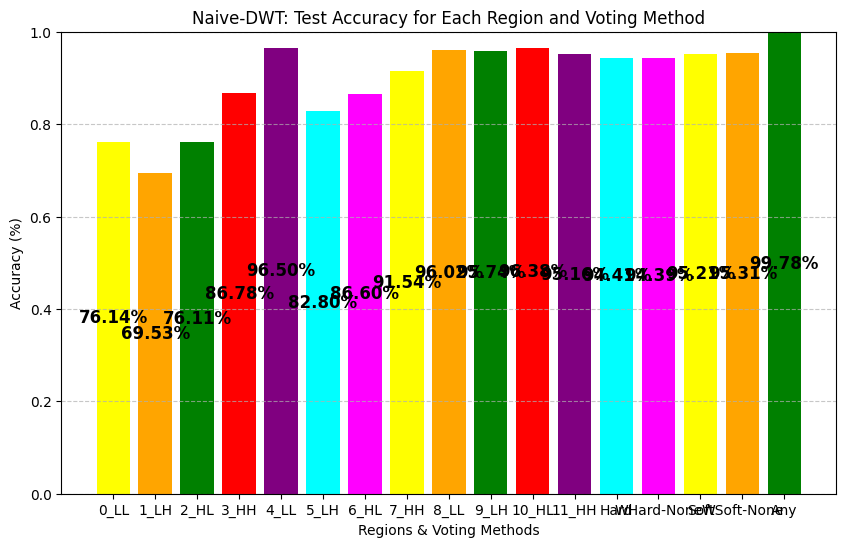

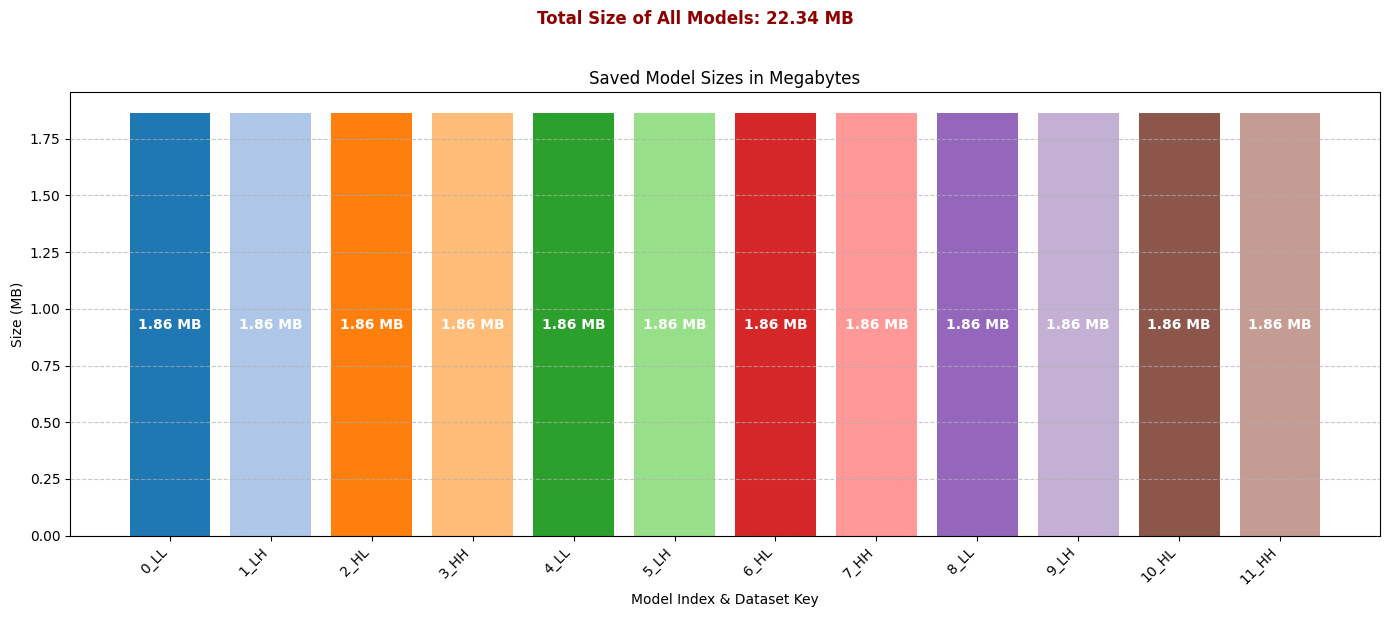


Total Runtime: 0 hours, 1 minutes.


In [6]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization,MaxPool2D
import matplotlib.pyplot as plt
import random as rn
import time
from tensorflow.keras.utils import Sequence
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Dictionary to store predictions for each model
model_predictions_hard = {} #used also for any
model_predictions_soft = {}
ensemble_predictions = {}
model_metrics = {}  # Stores performance metrics for weighting

start_time = time.time()

# Convert the timestamp to a structured time (local time)
local_time = time.localtime(start_time)
# Format the time as day-month-year-hours-minutes-seconds
formatted_time = time.strftime("%d-%m-%Y-%H-%M-%S", local_time)

# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
#setup_seed(42)
#------------
# Wavelet Transformation Function with region selection
def wavelet_transform(image, region='LL', wavelet='db2', level=3, target_size=(32, 32)):
    wavelet_mode = 'periodization'

    # Applying 3-level DWT to each color channel separately
    C_R = pywt.wavedec2(image[:, :, 0], wavelet, mode=wavelet_mode, level=level)
    C_G = pywt.wavedec2(image[:, :, 1], wavelet, mode=wavelet_mode, level=level)
    C_B = pywt.wavedec2(image[:, :, 2], wavelet, mode=wavelet_mode, level=level)

    # Function to scale coefficients to [0, 255] range
    def scale_coefficients(coeff):
        coeff_min = np.min(coeff)
        coeff_max = np.max(coeff)
        if coeff_max - coeff_min == 0:
            return coeff
        scaled_coeff = 255 * (coeff - coeff_min) / (coeff_max - coeff_min)
        return scaled_coeff

    # Extract and scale the coefficients for each color channel
    CA3_R = scale_coefficients(C_R[0])
    (CH3_R, CV3_R, CD3_R) = [scale_coefficients(c) for c in C_R[-level]]
    CA3_G = scale_coefficients(C_G[0])
    (CH3_G, CV3_G, CD3_G) = [scale_coefficients(c) for c in C_G[-level]]
    CA3_B = scale_coefficients(C_B[0])
    (CH3_B, CV3_B, CD3_B) = [scale_coefficients(c) for c in C_B[-level]]

    # Create a single RGB image for each coefficient plot
    def create_rgb_image(channel_r, channel_g, channel_b):
        h, w = channel_r.shape
        rgb_image = np.zeros((h, w, 3), dtype=np.uint8)
        rgb_image[:, :, 0] = channel_r
        rgb_image[:, :, 1] = channel_g
        rgb_image[:, :, 2] = channel_b
        return rgb_image

    # Choose the appropriate region
    if region == 'LL':
        transformed_image = create_rgb_image(CA3_R, CA3_G, CA3_B)
    elif region == 'LH':
        transformed_image = create_rgb_image(CH3_R, CH3_G, CH3_B)
    elif region == 'HL':
        transformed_image = create_rgb_image(CV3_R, CV3_G, CV3_B)
    elif region == 'HH':
        transformed_image = create_rgb_image(CD3_R, CD3_G, CD3_B)
    else:
        raise ValueError("Invalid region specified. Choose from 'LL', 'LH', 'HL', 'HH'.")

    # Resize the transformed image to the target size
    #transformed_image = cv2.resize(transformed_image, target_size)

    return transformed_image

from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)

def create_datagen_with_wavelet(region, wavelet='db2', level=3, target_size=(32, 32), preprocessing_function=True):
    def wavelet_transform_function(img):
        return wavelet_transform(img, region=region, wavelet=wavelet, level=level, target_size=target_size)

    if preprocessing_function:
        datagen = ImageDataGenerator(
            preprocessing_function=densenet_preprocess_input
        )
    else:
        datagen = ImageDataGenerator(
            preprocessing_function=wavelet_transform_function
        )

    return datagen

def compute_model_weights(metric="f1-score", class_label=None):
    """Compute model weights based on the specified metric (overall or per-class), with normalization."""
    global model_metrics
    weights = {}
    # Calculate raw weights based on the specified metric
    for model, metrics in model_metrics.items():
        if metric == "accuracy":
            # Extract overall accuracy (default to 0 if not available)
            weight = metrics.get("accuracy", 0)
        elif class_label is None:
            # Extract weighted avg metrics (for "f1-score", "precision", etc.)
            weight = metrics["weighted avg"].get(metric, 0)
        else:
            # Extract per-class metric (default to 0 if not available)
            weight = metrics.get(str(class_label), {}).get(metric, 0)

        # Store the raw weight
        weights[model] = weight

    # Normalize the weights so they sum to 1
    total_weight = sum(weights.values())
    if total_weight > 0:
        # Normalize weights: Divide each model's weight by the total weight
        weights = {model: weight / total_weight for model, weight in weights.items()}
    else:
        # If all weights are 0, assign equal weights (to avoid division by zero)
        num_models = len(weights)
        weights = {model: 1 / num_models for model in weights}

    return weights

def train_cnn(img_width, img_height, batch_size, epochs, learn_rate, model_type, all_images_train, all_labels_train,all_images_val, all_labels_val,mode,level, dataset_key, index, models_to_train):
    model = None

    print(f"> Training model: {model_type} on dataset: {dataset_key}")

    if model_type == "mobile_netv3_large":
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)
        from tensorflow.keras.applications import MobileNetV3Large
        base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))
        # Freeze all layers in the base model
        for layer in base_model.layers:
            layer.trainable = False
        x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
        outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
        model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

    if model_type == "custom":
        from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
        datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)

        model = Sequential()
        model.add(Conv2D(16,  (1, 1), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=(img_width, img_height, 3)))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
        model.add(Conv2D(32, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
        model.add(Conv2D(64, (3, 3), padding='same', activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2),strides=2))
        model.add(Flatten())
        model.add(Dense(128, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.1))
        outputs = model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learn_rate), loss='binary_crossentropy', metrics=['accuracy'])
    
    #train_generator = datagen.flow_from_directory(training_path, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary',shuffle=True)
    #valid_generator = datagen.flow_from_directory(validation_path, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary',shuffle=False)
    train_generator = create_datagen_with_wavelet(dataset_key, mode, level).flow(all_images_train, all_labels_train, batch_size=batch_size, shuffle=True)
    valid_generator = create_datagen_with_wavelet(dataset_key, mode, level).flow(all_images_val, all_labels_val, batch_size=batch_size, shuffle=False)

    lr_schedule = ReduceLROnPlateau( monitor='val_loss', factor=0.3, patience=3, verbose=1, min_lr=1e-6)
    Early_Stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=7,verbose=1,restore_best_weights='True',min_delta=0.1)

    directory = f"Models_{len(models_to_train)}_DWT-lvl_{level}_{formatted_time}"
    # Check if the directory exists, and if not, create it
    if not os.path.exists(directory):
        os.makedirs(directory)
        #print(f"Directory '{directory}' created.")
    #else:
        #print(f"Directory '{directory}' already exists.")
    indexwithdatasetkey= str(index) + "_" +model_type + "_" + dataset_key + ".keras"
    checkpoint = ModelCheckpoint(f"{directory}/{indexwithdatasetkey}", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
    callbacks_list = [checkpoint,lr_schedule]
    model.fit(train_generator, epochs=epochs, validation_data=valid_generator,callbacks=[callbacks_list])

    return model, datagen

def make_prediction(model, datagen, test_path, img_width, img_height, batch_size, model_index, dataset_key,mode,level):
    #test_generator = datagen.flow_from_directory(test_path, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)
    test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(test_path, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)
    predictions = model.predict(test_generator)
    true_labels = test_generator.classes

    predicted_classes_hard = (predictions > 0.5).astype(int).flatten()
    model_predictions_hard[model_index] = predicted_classes_hard.tolist()

    probabilities = predictions
    model_predictions_soft[model_index] = probabilities.flatten().tolist()  # Store raw probabilities

    
    # Compute accuracy and return it
    indexwithdatasetkey= str(model_index) + "_" + dataset_key
    accuracy = cf_and_classification_report(true_labels, predicted_classes_hard, indexwithdatasetkey)

    return true_labels, accuracy

def ensemble_any_voting(true_labels):
    global ensemble_predictions
    num_samples = len(true_labels)  # Number of samples in the test dataset

    print("-----------------\n- Ensemble ANY voting")
    
    # Iterate over each sample
    for i in range(num_samples): # model_predictions_hard is used for any beacuse both refer to labels rather than probabilities (soft)
        # Check if any model predicted the sample correctly
        correct_prediction = any(model_predictions_hard[model][i] == true_labels[i] for model in model_predictions_hard)
        
        # If at least one model predicted correctly, assign the true label as the ensemble prediction
        if correct_prediction:
            ensemble_predictions[i] = true_labels[i]
        else:
            # If no model predicted correctly, assign the majority vote (or some other rule)
            votes = [model_predictions_hard[model][i] for model in model_predictions_hard]
            ensemble_predictions[i] = max(set(votes), key=votes.count)  # Fallback to majority vote

def cf_and_classification_report(true_labels, preds, model_name):
    """Compute classification report & store all metrics, including per-class & overall."""
    conf_matrix = confusion_matrix(true_labels, preds)
    print(f"Confusion Matrix for {model_name}:")
    print(conf_matrix)

    class_report = classification_report(true_labels, preds, digits=5, zero_division=1, output_dict=True)
    accuracy = class_report["accuracy"]  # Extract overall accuracy

    print(f"Classification Report for {model_name}:")
    print(classification_report(true_labels, preds, digits=5, zero_division=1))
    print(f"Accuracy for {model_name}: {accuracy:.5f}\n")

    # Store ALL metrics (both per-class & weighted avg)
    model_metrics[model_name] = {
        "accuracy": accuracy,  
        "weighted avg": class_report["weighted avg"],
        "0": class_report["0"],  # Class 0 metrics
        "1": class_report["1"]   # Class 1 metrics
    }

    return accuracy

def ensemble_hard_voting(true_labels):
    global ensemble_predictions
    num_samples = len(true_labels)

    print("-----------------\n- Ensemble HARD voting (majority/sample)")
    
    for i in range(num_samples):
        votes = [model_predictions_hard[model][i] for model in model_predictions_hard]
        ensemble_predictions[i] = max(set(votes), key=votes.count)

def ensemble_weighted_hard_voting(true_labels, metric="f1-score", class_label=None):
    global ensemble_predictions
    weights = compute_model_weights(metric, class_label)
    num_samples = len(true_labels)
    
    print(f"-----------------\n- Ensemble WEIGHTED HARD voting (Metric: {metric}, Class: {class_label})")
    
    for i in range(num_samples):
        weighted_votes = {}
        for model, predictions in model_predictions_hard.items():
            vote = predictions[i]
            weighted_votes[vote] = weighted_votes.get(vote, 0) + weights.get(model, 1)
        
        ensemble_predictions[i] = max(weighted_votes, key=weighted_votes.get)

def ensemble_soft_voting(true_labels):
    global ensemble_predictions
    num_samples = len(true_labels)
    print("-----------------\n- Ensemble SOFT voting (class-wise average probability)")

    # Initialize list for ensemble predictions
    ensemble_predictions = []

    for i in range(num_samples):
        # Initialize accumulators for probabilities of each class (0 and 1)
        class_probabilities = {0: 0, 1: 0}

        # For each model, get the predicted probabilities for class 0 and class 1
        for model in model_predictions_soft:
            prediction = model_predictions_soft[model][i]  # Probability for class 1 (0-1 range)
            # We assume binary classification, so class 0's probability is 1 - class 1's probability
            class_probabilities[0] += (1 - prediction)  # Probability for class 0
            class_probabilities[1] += prediction        # Probability for class 1

        # Average the probabilities for each class across all models
        num_models = len(model_predictions_soft)
        class_probabilities[0] /= num_models
        class_probabilities[1] /= num_models

        # Assign the class with the higher average probability as the final prediction
        if class_probabilities[1] > class_probabilities[0]:
            ensemble_predictions.append(1)  # Class 1 has higher probability
        else:
            ensemble_predictions.append(0)  # Class 0 has higher probability

    # Convert list of predictions to numpy array
    ensemble_predictions = np.array(ensemble_predictions)


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from statistics import mean
import numpy as np

import numpy as np

def ensemble_weighted_soft_voting(true_labels, metric="recall"):
    global ensemble_predictions
    num_samples = len(true_labels)
    print(f"-----------------\n- Ensemble WEIGHTED SOFT voting (Per class Metric: {metric})")

    # Compute model weights based on the metric (recall or any other metric)
    weights = compute_model_weights(metric)
    print("Weights for each model:", weights)

    ensemble_predictions = []

    # Map indices of model_predictions_soft to model names in model_metrics
    model_names = list(model_predictions_soft.keys())

    for i in range(num_samples):
        # Initialize accumulators for weighted probabilities of each class (0 and 1)
        class_probabilities = {0: 0, 1: 0}

        # Get the true label for this sample
        true_label = true_labels[i]

        # For each model, get the predicted probabilities for class 0 and class 1
        for idx, model in enumerate(model_names):
            prediction = model_predictions_soft[model][i]  # Probability for class 1 (0-1 range)
            weight = weights.get(model, 1)  # Default to weight 1 if no weight is found
            
            # Make sure the model metrics contain the expected structure
            #model_metric = model_metrics.get(model, {})
            #if not model_metric:
            #    print(f"Warning: Model '{model}' does not have metrics, skipping.")
            #    continue

            #print("idx:", idx)
            data_items = list(model_metrics.items())
            # Ensure we are accessing class metrics as strings "0" and "1"
            model_name, metrics = data_items[idx]
            recall_for_class_0 = metrics["0"]["recall"]  # Default to 1 if not available
            recall_for_class_1 = metrics["1"]["recall"]  # Default to 1 if not available
            #print(f"Model at index {idx}: {model_name}")
            #print(f"Recall for {model_name} model, class 0: {recall_for_class_0}, class 1: {recall_for_class_1}")
            
            # Apply the recall for the predicted class for this sample (class-specific recall)
            if prediction >= 0.5:
                # Class 1 prediction
                class_probabilities[1] += prediction * weight * recall_for_class_1
                class_probabilities[0] += (1 - prediction) * weight * (1 - recall_for_class_1)  # For class 0, inverse recall
            else:
                # Class 0 prediction
                class_probabilities[0] += (1 - prediction) * weight * recall_for_class_0
                class_probabilities[1] += prediction * weight * (1 - recall_for_class_0)  # For class 1, inverse recall

        # Normalize the weighted class probabilities (sum of weights)
        total_weight = sum(weights.values())
        if total_weight > 0:
            class_probabilities[0] /= total_weight
            class_probabilities[1] /= total_weight

        # Assign the class with the higher weighted average probability as the final prediction
        if class_probabilities[1] > class_probabilities[0]:
            ensemble_predictions.append(1)  # Class 1 has higher weighted probability
        else:
            ensemble_predictions.append(0)  # Class 0 has higher weighted probability

    ensemble_predictions = np.array(ensemble_predictions)
    return ensemble_predictions



def plot_graphs(accuracies):
    categories = list(accuracies.keys())  # ["LL", "LH", "HL", "HH", "Hard", "Soft", "Any"]
    values = list(accuracies.values())  # Corresponding accuracy values

    plt.figure(figsize=(10, 6))
    bars = plt.bar(categories, values, color=['yellow', 'orange', 'green', 'red', 'purple', 'cyan', 'magenta'])

    # Add text labels inside bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        text_color = "white" if height < 0.5 else "black"  # Adapt text color for contrast
        plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f"{value*100:.2f}%", 
                 ha='center', va='center', fontsize=12, color=text_color, fontweight='bold')

    plt.xlabel("Regions & Voting Methods")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 1)  # Accuracy is between 0 and 1
    plt.title("Naive-DWT: Test Accuracy for Each Region and Voting Method")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

import pprint

def load_images_and_labels(directory_path, target_size):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory_path))  # List all subdirectories (class names)
    
    for class_name in class_names:
        class_path = os.path.join(directory_path, class_name)
        if not os.path.isdir(class_path):
            continue
        image_files = [os.path.join(class_path, fname) for fname in os.listdir(class_path) if fname.endswith(('.png', '.jpg', '.jpeg'))]
        
        for image_file in image_files:
            img = load_img(image_file, target_size=target_size)
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(class_name)  # Append the class label
            
    images = np.array(images)
    labels = np.array(labels)
    
    # Ensure that images and labels have the same length
    if len(images) != len(labels):
        raise ValueError(f"Number of images ({len(images)}) does not match number of labels ({len(labels)}).")
        
    #encode labels
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(labels)
    
    return images, labels

def plot_model_sizes(directory, models_to_train):
    """Plot bar chart of saved model sizes in MB."""
    model_sizes = {}
    
    for index, model_config in enumerate(models_to_train):
        dataset_key = model_config["dataset"]
        model_type = model_config["model"]
        filename = f"{str(index)}_{model_type}_{dataset_key}.keras"
        filepath = os.path.join(directory, filename)
        
        if os.path.exists(filepath):
            size_mb = os.path.getsize(filepath) / (1024 * 1024)  # Convert bytes to MB
            label = f"{index}_{dataset_key}"
            model_sizes[label] = size_mb
        else:
            print(f"Warning: Model file not found: {filepath}")
    
    if not model_sizes:
        print("No model files found to plot sizes.")
        return
    
    categories = list(model_sizes.keys())
    values = list(model_sizes.values())

    colors = plt.cm.tab20.colors[:len(categories)]

    plt.figure(figsize=(14, 6))
    bars = plt.bar(categories, values, color=colors)

    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f"{value:.2f} MB",
                 ha='center', va='center', fontsize=10, color='white', fontweight='bold')

    plt.xlabel("Model Index & Dataset Key")
    plt.ylabel("Size (MB)")
    plt.title("Saved Model Sizes in Megabytes")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    total_size = sum(values)
    plt.suptitle(f"Total Size of All Models: {total_size:.2f} MB", fontsize=12, fontweight='bold', color='darkred', y=1.02)
    plt.tight_layout()
    plt.show()

def main():
    img_width, img_height = 256, 256
    batch_size = 64
    epochs = 1
    learn_rate = 0.001
    level = 3
    mode = 'db2'
    seed = 41
    setup_seed(seed)
    
    train_dataset = 'C:\\Users\\\George Petrog\\\Documents\\\Projects\DL\\\PTIXIAKI\\\Data48240\\\Data_48240_60_15_25\\Training'
    valid_dataset = 'C:\\Users\\\George Petrog\\\Documents\\\Projects\DL\\\PTIXIAKI\\\Data48240\\\Data_48240_60_15_25\\Validation'
    testing_path  = 'C:\\Users\\\George Petrog\\\Documents\\\Projects\DL\\\PTIXIAKI\\\Data48240\\\Data_48240_60_15_25\\Test'

    img_width = img_width // (2 ** level)
    img_height = img_height // (2 ** level)

    print(f"Wavelet Level: {level} - New dimensions: {img_width}x{img_height}")

    all_images_train, all_labels_train = load_images_and_labels(train_dataset, target_size=(img_width, img_height))
    all_images_val, all_labels_val = load_images_and_labels(valid_dataset, target_size=(img_width, img_height))

    models_to_train = [
        {"model": "custom", "dataset": "LL", "epochs": 1},
        {"model": "custom", "dataset": "LH", "epochs": 1},
        {"model": "custom", "dataset": "HL", "epochs": 1},
        {"model": "custom", "dataset": "HH", "epochs": 1},
        {"model": "custom", "dataset": "LL", "epochs": 2},
        {"model": "custom", "dataset": "LH", "epochs": 2},
        {"model": "custom", "dataset": "HL", "epochs": 2},
        {"model": "custom", "dataset": "HH", "epochs": 2},
        {"model": "custom", "dataset": "LL", "epochs": 3},
        {"model": "custom", "dataset": "LH", "epochs": 3},
        {"model": "custom", "dataset": "HL", "epochs": 3},
        {"model": "custom", "dataset": "HH", "epochs": 3},
    ]
    
    true_labels = None  # Initialize true_labels
    accuracies = {}
    
    for index, model_config in enumerate(models_to_train):
        dataset_key = model_config["dataset"]  # "LL", "LH", etc.
        #print(f"> Training model on dataset: {dataset_key}")

        model, datagen = train_cnn(img_width, img_height, batch_size, model_config["epochs"], learn_rate, model_config["model"], all_images_train, all_labels_train,all_images_val, all_labels_val,mode,level, dataset_key, index,models_to_train)
        
        true_labels, accuracy = make_prediction(model, datagen, testing_path, img_width, img_height, batch_size, index, dataset_key,mode,level)
        
        indexwithdatasetkey = str(index)+"_"+dataset_key
        accuracies[indexwithdatasetkey] = accuracy  # Store accuracy for plotting

    pprint.pprint(model_metrics)
    #pprint.pprint(model_predictions_soft)

    #-----------------------------------------------
    # Hard voting ensemble
    ensemble_hard_voting(true_labels)
    ensemble_preds = [ensemble_predictions[i] for i in range(len(true_labels))]
    accuracies["Hard"] = cf_and_classification_report(true_labels, ensemble_preds, "Hard Voting")
    # Weighted Hard voting
    class_label=None
    ensemble_weighted_hard_voting(true_labels, metric="f1-score")
    #ensemble_weighted_hard_voting(true_labels, metric="precision", class_label=0)
    # ensemble_weighted_hard_voting(true_labels, metric="accuracy")
    ensemble_preds = [ensemble_predictions[i] for i in range(len(true_labels))]
    accuracies[f"WHard-{class_label}"] = cf_and_classification_report(true_labels, ensemble_preds, "Weighted Hard Voting")
    #-----------------------------------------------
    # Soft voting ensemble
    ensemble_soft_voting(true_labels)
    ensemble_preds = ensemble_predictions.tolist()
    accuracies["Soft"] = cf_and_classification_report(true_labels, ensemble_preds, "Soft Voting")
    
    #"""
    # Weighted Soft voting
    class_label=None
    ensemble_weighted_soft_voting(true_labels, metric="f1-score")
    #ensemble_weighted_soft_voting(true_labels, metric="recall", class_label=0)
    #ensemble_weighted_soft_voting(true_labels, metric="accuracy")
    ensemble_preds = ensemble_predictions.tolist()
    accuracies[f"WSoft-{class_label}"] = cf_and_classification_report(true_labels, ensemble_preds, "Weighted Soft Voting")
    #"""
    #-----------------------------------------------
    # Any voting ensemble
    ensemble_any_voting(true_labels)
    ensemble_preds = [ensemble_predictions[i] for i in range(len(true_labels))]
    accuracies["Any"] = cf_and_classification_report(true_labels, ensemble_preds, "Any Voting")
    
    print("------------\nseed: ", seed)
    plot_graphs(accuracies)

    # Plot saved model sizes
    directory = f"Models_{len(models_to_train)}_DWT-lvl_{level}_{formatted_time}"
    plot_model_sizes(directory, models_to_train)

    # calculate elapesed runtime
    end_time = time.time()
    runtime_seconds = end_time - start_time
    runtime_minutes = runtime_seconds / 60
    runtime_hours = runtime_minutes / 60
    print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")

if __name__ == "__main__":
    main()

## more test (feature extraction too)

In [64]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, GlobalAveragePooling2D, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Constants
image_size = (64, 64)  # Image size
batch_size = 64
num_classes = 2  # Binary classification
num_base_models = 3

# Paths to the dataset
train_dir = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_train_test_only\\Training'  # Replace with your train directory path
test_dir = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data48240\\Data_48240_train_test_only\\Test'    # Replace with your test directory path

# Data generators
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess_input)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary'  # Binary classification
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',  # Binary classification
    shuffle=False  # Ensure order is preserved for evaluation
)

# Simulate base models (e.g., CNNs)
def build_base_model(input_shape):
    model = Sequential()
    # Reduce the size of the convolutional layers
    model.add(Conv2D(8,  (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))

    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))  # Binary classification output
    return model

# Train base models on the training set
base_models = []
for i in range(num_base_models):
    print(f"Training Base Model {i+1}")
    model = build_base_model((image_size[0], image_size[1], 3))  # RGB images
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(train_generator, epochs=1, verbose=1)
    base_models.append(model)

print("> Predicting on Training Set")
# Generate predictions for the training set using base models
X_train_base_preds = []
for model in base_models:
    train_generator.reset()  # Reset generator to ensure consistent ordering
    preds = model.predict(train_generator)
    X_train_base_preds.append(preds)
X_train_base_preds = np.array(X_train_base_preds)  # Shape: (3, num_samples, 1)
X_train_base_preds = np.transpose(X_train_base_preds, (1, 0, 2))  # Shape: (num_samples, 3, 1)

# Reshape the base model predictions for the meta-model
X_train_meta_preds = X_train_base_preds.reshape(X_train_base_preds.shape[0], -1)  # Shape: (num_samples, 3)

print("Base Model Predictions Correlation:")
print(np.corrcoef(X_train_meta_preds.T))  # Check correlation between base models

# Get true labels for the training set
train_generator.reset()
y_train_true = train_generator.classes

from tensorflow.keras.applications import DenseNet121
base_cnn = DenseNet121(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
base_cnn.trainable = False  # Freeze the base CNN


print("> Feature extraction on train set")
# Extract image features for the training set
train_generator.reset()
X_train_features = base_cnn.predict(train_generator)  # Shape: (num_samples, 2, 2, 512)
X_train_features_flat = GlobalAveragePooling2D()(X_train_features).numpy()  # Shape: (num_samples, 512)

# pca 
from sklearn.decomposition import PCA
pca = PCA(n_components=200)  # Reduce 512 VGG16 features to 50
X_train_features_pca = pca.fit_transform(X_train_features_flat)
print("Explained variance ratio (PCA):", np.cumsum(pca.explained_variance_ratio_))


# Combine image features and base model predictions for the training set
X_train_meta = np.concatenate([X_train_features_pca, X_train_meta_preds], axis=1)  # Shape: (num_samples, 515)

# Normalize the meta features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_meta = scaler.fit_transform(X_train_meta)  # Fit and transform training data

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

from tensorflow.keras.layers import LeakyReLU, Add

from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dense

from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, concatenate
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention

# Inputs for Base Model Outputs and VGG16 Features
input_meta_base = Input(shape=(X_train_meta_preds.shape[1],))  # Base model outputs
input_meta_vgg = Input(shape=(X_train_features_pca.shape[1],))  # VGG16 PCA features

# Process Base Model Outputs
base_stream = Dense(64, activation=None, kernel_regularizer=tf.keras.regularizers.l2(0.001))(input_meta_base)
base_stream = BatchNormalization()(base_stream)
base_stream = tf.keras.layers.Activation('relu')(base_stream)
base_stream = Dropout(0.3)(base_stream)

# Process VGG16 Features
vgg_stream = Dense(64, activation=None, kernel_regularizer=tf.keras.regularizers.l2(0.001))(input_meta_vgg)
vgg_stream = BatchNormalization()(vgg_stream)
vgg_stream = tf.keras.layers.Activation('relu')(vgg_stream)
vgg_stream = Dropout(0.3)(vgg_stream)

# Merge Processed Features
merged_stream = concatenate([base_stream, vgg_stream])  # Combine both streams

# Reshape to 3D for MultiHeadAttention
merged_stream = tf.expand_dims(merged_stream, axis=1)  # Shape: (batch_size, 1, features)

# Multi-Head Attention Layer
attention_output = MultiHeadAttention(num_heads=4, key_dim=merged_stream.shape[-1])(merged_stream, merged_stream)

# Residual Connection and Layer Normalization
attention_output = tf.squeeze(attention_output, axis=1)  # Remove the sequence dimension
attention_output = LayerNormalization()(attention_output + merged_stream[:, 0, :])  # Match shapes


# Fully Connected Layers
x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(attention_output)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = Dropout(0.3)(x)

# Output Layer
output_meta = Dense(1, activation='sigmoid')(x)  # Binary classification output

# Build and Compile the Meta-Model
meta_model = Model(inputs=[input_meta_base, input_meta_vgg], outputs=output_meta)
meta_model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

# Train the Meta-Model
print("> Training the Improved Meta-Model")


from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define learning rate scheduler callback
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# Train the meta-model with LR scheduler
meta_model.fit([X_train_meta_preds, X_train_features_pca], y_train_true, epochs=60, batch_size=64, 
               validation_split=0.15, callbacks=[lr_scheduler])


print("> Testing Base Models on Test Set")
# Evaluate each base model on the test set and print confusion matrices
for i, model in enumerate(base_models):
    print(f"\nEvaluating Base Model {i+1}")
    test_generator.reset()  # Reset the generator to ensure consistent ordering
    y_test_pred = []
    y_test_true = []
    
    # Iterate through the generator to collect all predictions and true labels
    for _ in range(len(test_generator)):
        X_batch, y_batch = next(test_generator)
        y_test_true.extend(y_batch)
        y_pred_batch = model.predict(X_batch)
        y_test_pred.extend(y_pred_batch.flatten())  # Flatten predictions to 1D array
    
    # Ensure the lengths of y_test_true and y_test_pred match
    y_test_true = np.array(y_test_true)
    y_test_pred_classes = (np.array(y_test_pred) > 0.5).astype(int)
    
    # Check if lengths match
    if len(y_test_true) != len(y_test_pred_classes):
        print(f"Warning: Length mismatch! y_true: {len(y_test_true)}, y_pred: {len(y_test_pred_classes)}")
        # Truncate the longer array to match the shorter one
        min_length = min(len(y_test_true), len(y_test_pred_classes))
        y_test_true = y_test_true[:min_length]
        y_test_pred_classes = y_test_pred_classes[:min_length]
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test_true, y_test_pred_classes)
    print(f"Confusion Matrix for Base Model {i+1}:")
    print(conf_matrix)
    
    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for Base Model {i+1}')
    plt.show()
    
    # Classification Report
    class_report = classification_report(y_test_true, y_test_pred_classes, digits=5, zero_division=1, target_names=['Class 0', 'Class 1'])
    print(f"Classification Report for Base Model {i+1}:")
    print(class_report)

print("> Testing Meta-Model on Test Set")
# Generate predictions for the test set using base models
X_test_base_preds = []
for model in base_models:
    test_generator.reset()
    preds = model.predict(test_generator)
    X_test_base_preds.append(preds)
X_test_base_preds = np.array(X_test_base_preds)  # Shape: (3, num_samples, 1)
X_test_base_preds = np.transpose(X_test_base_preds, (1, 0, 2))  # Shape: (num_samples, 3, 1)

# Reshape the base model predictions for the meta-model
X_test_meta_preds = X_test_base_preds.reshape(X_test_base_preds.shape[0], -1)  # Shape: (num_samples, 3)

# Extract image features for the test set
test_generator.reset()
X_test_features = base_cnn.predict(test_generator)  # Shape: (num_samples, 2, 2, 512)
X_test_features_flat = GlobalAveragePooling2D()(X_test_features).numpy()  # Shape: (num_samples, 512)

# apply pca
X_test_features_pca = pca.transform(X_test_features_flat)

# Combine image features and base model predictions for the test set
X_test_meta = np.concatenate([X_test_features_pca, X_test_meta_preds], axis=1)  # Shape: (num_samples, 515)
#normalize test meta
X_test_meta = scaler.transform(X_test_meta)  # Transform test data using the same scaler


# Predict on the test set using the meta-model
# Predict on the test set using the meta-model
test_predictions = meta_model.predict([X_test_meta_preds, X_test_features_pca])  # Pass both inputs as a list
test_predicted_classes = (test_predictions > 0.5).astype(int)  # Convert probabilities to binary classes


# Evaluate the meta-model on the test set
test_accuracy = accuracy_score(test_generator.classes, test_predicted_classes)
print(f"Meta-Model Test Accuracy: {test_accuracy}")

# Confusion Matrix for Meta-Model
conf_matrix = confusion_matrix(test_generator.classes, test_predicted_classes)
print("Confusion Matrix for Meta-Model:")
print(conf_matrix)

# Plot Confusion Matrix for Meta-Model
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Meta-Model')
plt.show()

# Classification Report for Meta-Model
class_report = classification_report(test_generator.classes, test_predicted_classes, digits=5, zero_division=1, target_names=['Class 0', 'Class 1'])
print("Classification Report for Meta-Model:")
print(class_report)

Found 18081 images belonging to 2 classes.
Found 6028 images belonging to 2 classes.
Training Base Model 1
 13/283 [>.............................] - ETA: 36s - loss: 0.5139 - accuracy: 0.7812

KeyboardInterrupt: 

# 2. Smart-DWT-Ensemble
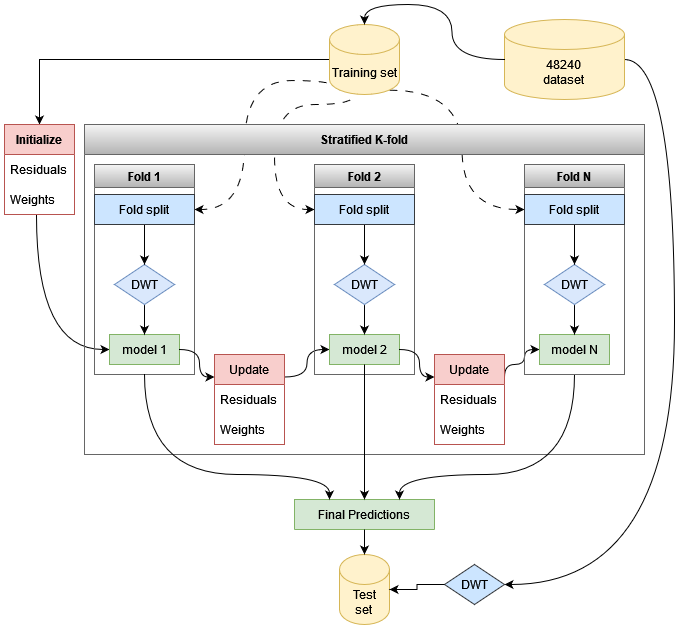

## 2.1. Smart-DWT-Ensemble on 48240 dataset featuring cnn + adaboost + gradboost + DWT (on the fly) + kfold

In [ ]:
# tf.keras.backend.clear_session()
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
#from keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam
from keras import backend as K 
from tensorflow.keras.utils import Sequence
import keras
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import os
import random as rn
import time
import pywt
import cv2
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import gc

start_time = time.time()

# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
#setup_seed(42)
#------------
# Wavelet Transformation Function with region selection
def wavelet_transform(image, region='LL', wavelet='db2', level=3, target_size=(32, 32)):
    wavelet_mode = 'periodization'

    # Applying 3-level DWT to each color channel separately
    C_R = pywt.wavedec2(image[:, :, 0], wavelet, mode=wavelet_mode, level=level)
    C_G = pywt.wavedec2(image[:, :, 1], wavelet, mode=wavelet_mode, level=level)
    C_B = pywt.wavedec2(image[:, :, 2], wavelet, mode=wavelet_mode, level=level)

    # Function to scale coefficients to [0, 255] range
    def scale_coefficients(coeff):
        coeff_min = np.min(coeff)
        coeff_max = np.max(coeff)
        if coeff_max - coeff_min == 0:
            return coeff
        scaled_coeff = 255 * (coeff - coeff_min) / (coeff_max - coeff_min)
        
        del coeff_min,coeff_max,coeff
        gc.collect()
        
        return scaled_coeff

    # Extract and scale the coefficients for each color channel
    CA3_R = scale_coefficients(C_R[0])
    (CH3_R, CV3_R, CD3_R) = [scale_coefficients(c) for c in C_R[-level]]
    CA3_G = scale_coefficients(C_G[0])
    (CH3_G, CV3_G, CD3_G) = [scale_coefficients(c) for c in C_G[-level]]
    CA3_B = scale_coefficients(C_B[0])
    (CH3_B, CV3_B, CD3_B) = [scale_coefficients(c) for c in C_B[-level]]

    # Create a single RGB image for each coefficient plot
    def create_rgb_image(channel_r, channel_g, channel_b):
        h, w = channel_r.shape
        rgb_image = np.zeros((h, w, 3), dtype=np.uint8)
        rgb_image[:, :, 0] = channel_r
        rgb_image[:, :, 1] = channel_g
        rgb_image[:, :, 2] = channel_b
        del h,w,channel_r,channel_g,channel_b
        
        return rgb_image

    # Choose the appropriate region
    if region == 'LL':
        transformed_image = create_rgb_image(CA3_R, CA3_G, CA3_B)
    elif region == 'LH':
        transformed_image = create_rgb_image(CH3_R, CH3_G, CH3_B)
    elif region == 'HL':
        transformed_image = create_rgb_image(CV3_R, CV3_G, CV3_B)
    elif region == 'HH':
        transformed_image = create_rgb_image(CD3_R, CD3_G, CD3_B)
    else:
        raise ValueError("Invalid region specified. Choose from 'LL', 'LH', 'HL', 'HH'.")

    del CH3_R, CV3_R, CD3_R
    del CH3_G, CV3_G, CD3_G
    del CH3_B, CV3_B, CD3_B
    del C_R, C_G, C_B
    gc.collect()

    # Resize the transformed image to the target size
    #transformed_image = cv2.resize(transformed_image, target_size)

    return transformed_image


# Set up ImageDataGenerator with dynamic region parameter
#def create_datagen_with_wavelet(region):
#    return ImageDataGenerator(preprocessing_function=lambda x: custom_preprocess_function(x, region=region))    
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input

def create_datagen_with_wavelet(region, wavelet='db2', level=3, target_size=(32, 32), preprocessing_function=True):
    def wavelet_transform_function(img):
        return wavelet_transform(img, region=region, wavelet=wavelet, level=level, target_size=target_size)

    if preprocessing_function:
        datagen = ImageDataGenerator(
            preprocessing_function=densenet_preprocess_input
        )
    else:
        datagen = ImageDataGenerator(
            preprocessing_function=wavelet_transform_function
        )

    return datagen

def create_cnn_model(input_shape):
    #"""
    model = Sequential()
    model.add(Conv2D(8, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    
    #"""
    """
    from tensorflow.keras.applications import DenseNet121
    base_model = DenseNet121(include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
     # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    """
    #model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])
    
    return model
    
def compute_sample_weights(y_true, y_pred, epsilon=2):
    # Convert predictions to binary class labels
    y_pred_binary = (y_pred >= 0.5).astype(int)
    #print(y_pred_binary)
    
    # Identify misclassified samples
    misclassified = (y_true != y_pred_binary)
    #print("y_true: ",y_true)
    #print("y_pred_binary: ",y_pred_binary)
    
    #print("misclassified: ",len(misclassified))
    # Count the number of misclassified samples
    num_misclassified = np.sum(misclassified)

    # Print the number of misclassified samples
    print(f"Number of misclassified samples: {num_misclassified}")
    
    # Compute residuals
    residuals = np.abs(y_true - y_pred_binary)
    
    # Assign higher weights to misclassified samples
    misclassified_weights = residuals + epsilon
    correct_classified_weights = 1
    weights = np.where(misclassified,  misclassified_weights, correct_classified_weights)
    
    del y_pred_binary,misclassified,num_misclassified
    gc.collect()
    
    print("epsilon + residuals: ",residuals + epsilon)
    
    return weights

class ResidualDataGenerator(Sequence):
    def __init__(self, data_generator, sample_weights):
        self.data_generator = data_generator
        self.sample_weights = sample_weights

    def __len__(self):
        return len(self.data_generator)

    def __getitem__(self, index):
        x_batch, y_batch = self.data_generator[index]
        gc.collect()
        return x_batch, y_batch, self.sample_weights[index * self.data_generator.batch_size:(index + 1) * self.data_generator.batch_size]

def train_gradient_boosting(num_folds, input_shape, learning_rate, mode, level, img_width, img_height, batch_size, epochs, all_images, all_labels, testing_path1):
    models = []
    histories = []
    from sklearn.model_selection import StratifiedKFold
    
    # Initialize weights to 1 for all samples
    sample_weights = np.ones(len(all_labels))
    
    kfold = StratifiedKFold(n_splits=num_folds, shuffle=False)
    regions = ['LL', 'LH', 'HL', 'HH']

    for fold_index, (train_idx, val_idx) in enumerate(kfold.split(all_images, all_labels)):
        i = fold_index % len(regions)
        print(f"--> Starting Fold {fold_index+1}/{num_folds} with region: {regions[i]}")

        x_train_fold = all_images[train_idx]
        y_train_fold = all_labels[train_idx]
        x_val_fold = all_images[val_idx]
        y_val_fold = all_labels[val_idx]

        print("- Training samples: ", len(y_train_fold))
        print("- Validation samples: ", len(y_val_fold))

        train_generator = create_datagen_with_wavelet(regions[i], mode, level).flow(x_train_fold, y_train_fold, batch_size=batch_size, shuffle=True)
        valid_generator = create_datagen_with_wavelet(regions[i], mode, level).flow(x_val_fold, y_val_fold, batch_size=batch_size, shuffle=False)

        residuals_generator = ResidualDataGenerator(train_generator, sample_weights[train_idx])

        model = create_cnn_model(input_shape)
        model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])

        checkpoint = ModelCheckpoint(f"best_model_fold_{fold_index+1}.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
        lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)

        # Train the model with sample weights
        history = model.fit(
            residuals_generator,
            validation_data=valid_generator,
            epochs=epochs,
            callbacks=[checkpoint, early_stopping],
            verbose=1
        )

        # Predict on training and validation data
        y_pred_train = model.predict(train_generator).flatten()
        y_pred_val = model.predict(valid_generator).flatten()

        # Compute weights based on misclassified samples
        weights_train = compute_sample_weights(y_train_fold, y_pred_train, 1.5)
        weights_val = compute_sample_weights(y_val_fold, y_pred_val, 1.5)

        # Apply higher weights to misclassified samples
        sample_weights[train_idx] = weights_train
        sample_weights[val_idx] = weights_val

        models.append(model)
        histories.append(history)

        # Clear session and free up memory
        tf.keras.backend.clear_session()
        del x_train_fold, y_train_fold, x_val_fold, y_val_fold, train_generator, valid_generator, residuals_generator, model
        gc.collect()

    
    return models, histories

def gradient_boosting_predict(models, test_generator):
    num_samples = test_generator.samples
    batch_size = test_generator.batch_size
    predictions_matrix = np.zeros((num_samples, len(models)))

    # Iterate through models
    for idx, model in enumerate(models):
        # Predict for all batches in one go
        predictions_matrix[:, idx] = model.predict(test_generator, verbose=1).flatten()

    # Vectorized final predictions
    true_labels = test_generator.classes
    positive_case = true_labels == 1
    negative_case = ~positive_case

    final_predictions = np.zeros(num_samples)
    for i in range(num_samples):
        if true_labels[i] == 1:
            # Check if any model predicts positive
            if np.any(predictions_matrix[i] >= 0.5):
                final_predictions[i] = 1
            else:
                final_predictions[i] = 0
        else:
            # Check if any model predicts negative
            if np.any(predictions_matrix[i] < 0.5):
                final_predictions[i] = 0
            else:
                final_predictions[i] = 1
    

    return final_predictions.astype(int)


def load_images_and_labels(directory_path, target_size):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory_path))  # List all subdirectories (class names)
    
    for class_name in class_names:
        class_path = os.path.join(directory_path, class_name)
        if not os.path.isdir(class_path):
            continue
        image_files = [os.path.join(class_path, fname) for fname in os.listdir(class_path) if fname.endswith(('.png', '.jpg', '.jpeg'))]
        
        for image_file in image_files:
            img = load_img(image_file, target_size=target_size)
            img_array = img_to_array(img)
            
            images.append(img_array)
            labels.append(class_name)  # Append the class label
            
            del img_array,img,image_file
            #gc.collect()
        del class_path,class_name,image_files
            
    del class_names
            
    images = np.array(images)
    labels = np.array(labels)
    
    # Ensure that images and labels have the same length
    if len(images) != len(labels):
        raise ValueError(f"Number of images ({len(images)}) does not match number of labels ({len(labels)}).")
        
    #encode labels
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(labels)
    
    gc.collect()
    
    return images, labels


# Load data
seed =46
setup_seed(seed)
img_width, img_height = 32, 32
level = 3
mode = 'db2'
batch_size = 64
input_shape = (img_width, img_height, 3)
num_learners = 12
epochs = 1
#learning_rate = 0.00000001  # A smaller learning rate for updating predictions
learning_rate = 0.1
train_dataset1 = '/kaggle/input/data-48240-train-test-only/Data_48240_train_test_only/Training'
testing_path1  = '/kaggle/input/data-48240-train-test-only/Data_48240_train_test_only/Test'
#train_dataset1 = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_913\\Data_913\\latest\\data913_80_20_train_test_only\\Training'
#testing_path1  = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_913\\Data_913\\latest\\data913_80_20_train_test_only\\Test'

all_images, all_labels = load_images_and_labels(train_dataset1, target_size=(img_width, img_height))

# Train Gradient Boosting
models, histories = train_gradient_boosting(
    num_folds=num_learners,  # Number of folds, corresponds to the number of regions (LL, LH, HL, HH)
    input_shape=(img_width, img_height, 3),
    learning_rate=learning_rate,
    mode=mode,
    level=level,
    img_width=img_width,
    img_height=img_height,
    batch_size=batch_size,
    epochs=epochs,
    all_images= all_images,
    all_labels = all_labels,
    testing_path1=testing_path1  # Path to the testing dataset
)

# Predict on test set
test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
        testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)

y_pred = gradient_boosting_predict(models, test_generator)

# Evaluate results
target_names = ['Malware', 'Software']
print('Confusion Matrix')
print(confusion_matrix(test_generator.classes, y_pred))
print('Classification Report')
print(classification_report(test_generator.classes, y_pred, target_names=target_names, zero_division=1, digits=5))

# calculate elapesed runtime
end_time = time.time()
runtime_seconds = end_time - start_time
runtime_minutes = runtime_seconds / 60
runtime_hours = runtime_minutes / 60
print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")
# 10 epochs with lr = 0.01
# 0.1 with 1 epoch X
# 0.1 with 3 epoch

In [ ]:
print(np.__version__)
print(keras.__version__)

In [ ]:
tf.keras.backend.clear_session()

## 2.2. Smart-DWT-Ensemble on 913 dataset featuring cnn + adaboost + gradboost + DWT (on the fly) + kfold

In [ ]:
# tf.keras.backend.clear_session()
import tensorflow as tf
print(tf.__version__)
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
#from keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam

from sklearn.metrics import classification_report, confusion_matrix
import os
import random as rn
import time
import pywt
import cv2
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import load_img, img_to_array


start_time = time.time()

# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
#setup_seed(42)
#------------
# Wavelet Transformation Function with region selection
def wavelet_transform(image, region='LL', wavelet='db2', level=3, target_size=(32, 32)):
    wavelet_mode = 'periodization'

    # Applying 3-level DWT to each color channel separately
    C_R = pywt.wavedec2(image[:, :, 0], wavelet, mode=wavelet_mode, level=level)
    C_G = pywt.wavedec2(image[:, :, 1], wavelet, mode=wavelet_mode, level=level)
    C_B = pywt.wavedec2(image[:, :, 2], wavelet, mode=wavelet_mode, level=level)

    # Function to scale coefficients to [0, 255] range
    def scale_coefficients(coeff):
        coeff_min = np.min(coeff)
        coeff_max = np.max(coeff)
        if coeff_max - coeff_min == 0:
            return coeff
        scaled_coeff = 255 * (coeff - coeff_min) / (coeff_max - coeff_min)
        return scaled_coeff

    # Extract and scale the coefficients for each color channel
    CA3_R = scale_coefficients(C_R[0])
    (CH3_R, CV3_R, CD3_R) = [scale_coefficients(c) for c in C_R[-level]]
    CA3_G = scale_coefficients(C_G[0])
    (CH3_G, CV3_G, CD3_G) = [scale_coefficients(c) for c in C_G[-level]]
    CA3_B = scale_coefficients(C_B[0])
    (CH3_B, CV3_B, CD3_B) = [scale_coefficients(c) for c in C_B[-level]]

    # Create a single RGB image for each coefficient plot
    def create_rgb_image(channel_r, channel_g, channel_b):
        h, w = channel_r.shape
        rgb_image = np.zeros((h, w, 3), dtype=np.uint8)
        rgb_image[:, :, 0] = channel_r
        rgb_image[:, :, 1] = channel_g
        rgb_image[:, :, 2] = channel_b
        return rgb_image

    # Choose the appropriate region
    if region == 'LL':
        transformed_image = create_rgb_image(CA3_R, CA3_G, CA3_B)
    elif region == 'LH':
        transformed_image = create_rgb_image(CH3_R, CH3_G, CH3_B)
    elif region == 'HL':
        transformed_image = create_rgb_image(CV3_R, CV3_G, CV3_B)
    elif region == 'HH':
        transformed_image = create_rgb_image(CD3_R, CD3_G, CD3_B)
    else:
        raise ValueError("Invalid region specified. Choose from 'LL', 'LH', 'HL', 'HH'.")

    # Resize the transformed image to the target size
    #transformed_image = cv2.resize(transformed_image, target_size)

    return transformed_image


# Set up ImageDataGenerator with dynamic region parameter
#def create_datagen_with_wavelet(region):
#    return ImageDataGenerator(preprocessing_function=lambda x: custom_preprocess_function(x, region=region))    
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)

def create_datagen_with_wavelet(region, wavelet='db2', level=3, target_size=(32, 32), preprocessing_function=True):
    def wavelet_transform_function(img):
        return wavelet_transform(img, region=region, wavelet=wavelet, level=level, target_size=target_size)

    if preprocessing_function:
        datagen = ImageDataGenerator(
            preprocessing_function=mobilenet_preprocess_input
        )
    else:
        datagen = ImageDataGenerator(
            preprocessing_function=wavelet_transform_function
        )

    return datagen

def create_cnn_model(input_shape):
    """
    model = Sequential()
    model.add(Conv2D(2, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(4, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(8, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(16, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    """
    
    """
    model = Sequential()
    model.add(Conv2D(4, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(8, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    """
    #"""
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
     # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    #"""
    #model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])
    
    return model
    
def compute_residuals(y_true, y_pred):
    return y_true - y_pred

def compute_sample_weights(y_true, y_pred, epsilon=2):
    # Convert predictions to binary class labels
    y_pred_binary = (y_pred >= 0.5).astype(int)
    #print(y_pred_binary)
    
    # Identify misclassified samples
    misclassified = (y_true != y_pred_binary)
    #print("y_true: ",y_true)
    #print("y_pred_binary: ",y_pred_binary)
    
    #print("misclassified: ",len(misclassified))
    # Count the number of misclassified samples
    num_misclassified = np.sum(misclassified)

    # Print the number of misclassified samples
    print(f"Number of misclassified samples: {num_misclassified}")
    
    # Compute residuals
    residuals = np.abs(y_true - y_pred_binary)
    
    # Assign higher weights to misclassified samples
    misclassified_weights = residuals + epsilon
    correct_classified_weights = 1
    weights = np.where(misclassified,  misclassified_weights, correct_classified_weights)
    
    #print("epsilon + residuals: ",residuals + epsilon)
    
    return weights

class ResidualDataGenerator(Sequence):
    def __init__(self, data_generator, sample_weights):
        self.data_generator = data_generator
        self.sample_weights = sample_weights

    def __len__(self):
        return len(self.data_generator)

    def __getitem__(self, index):
        x_batch, y_batch = self.data_generator[index]
        return x_batch, y_batch, self.sample_weights[index * self.data_generator.batch_size:(index + 1) * self.data_generator.batch_size]

def train_gradient_boosting(num_folds, input_shape, learning_rate, mode, level, img_width, img_height, batch_size, epochs, all_images, all_labels, testing_path1):
    models = []
    histories = []
    from sklearn.model_selection import StratifiedKFold
    
    # Initialize weights to 1 for all samples
    sample_weights = np.ones(len(all_labels))
    
    kfold = StratifiedKFold(n_splits=num_folds, shuffle=False)
    regions = ['LL', 'LH', 'HL', 'HH']

    for fold_index, (train_idx, val_idx) in enumerate(kfold.split(all_images, all_labels)):
        i = fold_index % len(regions)
        print(f"--> Starting Fold {fold_index+1}/{num_folds} with region: {regions[i]}")

        x_train_fold = all_images[train_idx]
        y_train_fold = all_labels[train_idx]
        x_val_fold = all_images[val_idx]
        y_val_fold = all_labels[val_idx]

        print("- Training samples: ", len(y_train_fold))
        print("- Validation samples: ", len(y_val_fold))

        train_generator = create_datagen_with_wavelet(regions[i], mode, level).flow(x_train_fold, y_train_fold, batch_size=batch_size, shuffle=True)
        valid_generator = create_datagen_with_wavelet(regions[i], mode, level).flow(x_val_fold, y_val_fold, batch_size=batch_size, shuffle=False)

        residuals_generator = ResidualDataGenerator(train_generator, sample_weights[train_idx])

        model = create_cnn_model(input_shape)
        model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])

        checkpoint = ModelCheckpoint(f"best_model_fold_{fold_index+1}.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
        lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)

        # Train the model with sample weights
        history = model.fit(
            residuals_generator,
            validation_data=valid_generator,
            epochs=epochs,
            callbacks=[checkpoint, early_stopping,lr_schedule],
            verbose=1
        )

        # Predict on training and validation data
        y_pred_train = model.predict(train_generator).flatten()
        y_pred_val = model.predict(valid_generator).flatten()

        # Compute weights based on misclassified samples
        weights_train = compute_sample_weights(y_train_fold, y_pred_train,1.5)
        weights_val = compute_sample_weights(y_val_fold, y_pred_val,1.5)

        # Apply higher weights to misclassified samples
        sample_weights[train_idx] = weights_train
        sample_weights[val_idx] = weights_val
        
        # Predict on validation data
        val_pred_test_model = model.predict(valid_generator)
        val_pred_test_model = np.where(val_pred_test_model > 0.5, 1, 0)

        val_true = y_val_fold

        # Evaluate results
        target_names = ['Malware', 'Software']
        print('Confusion Matrix')
        print(confusion_matrix(val_true, val_pred_test_model))
        print('Classification Report')
        print(classification_report(val_true, val_pred_test_model, target_names=target_names, zero_division=1, digits=5))

        test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
            testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)
        y_pred_test_model = model.predict(test_generator, test_generator.n // batch_size + 1)
        Y_pred_test = y_pred_test_model
        y_pred_test_model = np.where(y_pred_test_model > 0.5, 1, 0)
        #cm = confusion_matrix(test_generator.classes, test_labels)
        #print(cm)
        #print("test_labels: ",test_labels)
        test_labels = y_pred_test_model
        print(test_generator.class_indices)
        summ = 0 
        print("------------------")
        for i in range (0,len(test_generator.filenames)):
            detection_status = "Undetected      " if y_pred_test_model[i] > 0.5 else "Detected Malware"
            print(detection_status,"-",test_labels[i],"-","{:.8f}".format(Y_pred_test[i][0])," - ",test_generator.filenames[i])
            summ = summ + Y_pred_test[i][0]
        print("------------------")
        print("-> Avg malware accuracy: ",summ/13)

        models.append(model)
        histories.append(history)
    
    return models, histories


def gradient_boosting_predict(models, test_generator):
    num_samples = test_generator.samples
    batch_size = test_generator.batch_size
    predictions_matrix = np.zeros((num_samples, len(models)))

    for idx, model in enumerate(models):
        #print(idx)
        y_pred_list = []
        steps = num_samples // batch_size + (num_samples % batch_size != 0)
        
        for _ in range(steps):
            x_batch, _ = test_generator.next()
            y_pred_batch = model.predict(x_batch)
            y_pred_list.append(y_pred_batch)
        
        y_pred = np.concatenate(y_pred_list)
        
        # Ensure that predictions array is aligned
        if y_pred.shape[0] != num_samples:
            raise ValueError(f"Mismatch in prediction shape: {y_pred.shape[0]} != {num_samples}")
        
        predictions_matrix[:, idx] = y_pred.flatten()
    
    #each line, per sample for all models 
    print(predictions_matrix)
    
    #print("-> Avg malware accuracy: ",sum(y_pred)/13)
    # Check if any model's prediction is correct for each sample
    final_predictions = np.zeros(num_samples)
    true_labels = test_generator.classes
    for i in range(num_samples):
        # Compute distances from the true label (1 or 0)
        distances = np.abs(predictions_matrix[i] - true_labels[i])
        # Find the index of the minimum distance
        closest_model_index = np.argmin(distances)
        #print(closest_model_index)
        # Save the probability of the closest model
        final_predictions[i] = predictions_matrix[i][closest_model_index]
    
    print(final_predictions)

    return final_predictions

def load_images_and_labels(directory_path, target_size):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory_path))  # List all subdirectories (class names)
    
    for class_name in class_names:
        class_path = os.path.join(directory_path, class_name)
        if not os.path.isdir(class_path):
            continue
        image_files = [os.path.join(class_path, fname) for fname in os.listdir(class_path) if fname.endswith(('.png', '.jpg', '.jpeg'))]
        
        for image_file in image_files:
            img = load_img(image_file, target_size=target_size)
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(class_name)  # Append the class label
            
    images = np.array(images)
    labels = np.array(labels)
    
    # Ensure that images and labels have the same length
    if len(images) != len(labels):
        raise ValueError(f"Number of images ({len(images)}) does not match number of labels ({len(labels)}).")
        
    #encode labels
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(labels)
    
    return images, labels

#import sys
#old_stdout = sys.stdout # keep reference to existing stdout
#sys.stdout = open('logfile.txt', 'w')

accuracies = []
for i in range(100):
    # Load data
    seed = i
    setup_seed(seed)
    img_width, img_height = 256,1024
    level = 3
    mode = 'db2'
    batch_size = 32
    input_shape = (img_width, img_height, 3)
    num_learners = 8
    epochs = 1
    learning_rate = 0.1  # A smaller learning rate for updating predictions
    #train_dataset1 = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_48240\\latest\\Data_48240_train_test_only\\Training'
    #testing_path1  = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_48240\\latest\\Data_48240_train_test_only\\Test'
    train_dataset1 = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20_train_test_only\\Training'
    testing_path1  = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20_train_test_only\\Test'


    img_width = img_width // (2 ** level)
    img_height = img_height // (2 ** level)

    print(f"Wavelet Level: {level} - New dimensions: {img_width}x{img_height}")

    all_images, all_labels = load_images_and_labels(train_dataset1, target_size=(img_width, img_height))

    # Train Gradient Boosting
    models, histories = train_gradient_boosting(
        num_folds=num_learners,  # Number of folds, corresponds to the number of regions (LL, LH, HL, HH)
        input_shape=(img_width, img_height, 3),
        learning_rate=learning_rate,
        mode=mode,
        level=level,
        img_width=img_width,
        img_height=img_height,
        batch_size=batch_size,
        epochs=epochs,
        all_images= all_images,
        all_labels = all_labels,
        testing_path1=testing_path1  # Path to the testing dataset
    )

    # Predict on test set
    test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
            testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)

    y_pred = gradient_boosting_predict(models, test_generator)

    # DATA_913
    print(test_generator.class_indices)
    print("------------------")
    for i in range(len(test_generator.filenames)):
        detection_status = "Undetected      " if y_pred[i] > 0.5 else "Detected Malware"
        print(f"{detection_status} - {y_pred[i]:.8f} - {test_generator.filenames[i]}")
    print("------------------")
    print("-> Avg malware accuracy: ",sum(y_pred)/13)
    #"""
    
    accuracies.append(sum(y_pred)/13)

    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

    import numpy as np

    # Assuming y_true and y_pred are already obtained
    y_true = test_generator.classes  # Ground truth labels

    class_of_interest = 0  # Assuming Software is class 0, Malware is class 1

    print("y_true: ",y_true)
    y_pred_binary = y_pred
    for i in range(len(test_generator.filenames)):
        y_pred_binary[i] = 1 if y_pred_binary[i] >= 0.5 else 0
    #y_pred_binary = [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] #for testing purposes
    print("y_pred_binary: ",y_pred_binary)
    # Create the classification report only for classes present in y_true
    unique_classes = np.unique(y_true)
    labels = unique_classes  # Use only classes present in y_true
    target_names = ['Malware' if cls == 0 else 'Software' for cls in labels]

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred_binary, labels=labels)
    print(f"Confusion Matrix:\n{conf_matrix}")
    class_report = classification_report(y_true, y_pred_binary, labels=labels, target_names=target_names, zero_division=1, digits=5)
    print(class_report)
    # Compute and print accuracy
    #accuracy = accuracy_score(y_true, y_pred_binary)
    #print(f"Accuracy: {accuracy:.5f}")

    print("seed: ",seed)

    # calculate elapesed runtime
    end_time = time.time()
    runtime_seconds = end_time - start_time
    runtime_minutes = runtime_seconds / 60
    runtime_hours = runtime_minutes / 60
    print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")
    # 10 epochs with lr = 0.01
    
    #from IPython.core.display import HTML
    #HTML("<script>Jupyter.notebook.kernel.restart()</script>")
    
    print("###################################")
    
average = sum(accuracies) / len(accuracies)

# Print the average with 6 decimal places
print(f"{average:.6f}")
#sys.stdout = old_stdout # restore stdout

2.10.0
Wavelet Level: 3 - New dimensions: 32x128
--> Starting Fold 1/8 with region: LL
- Training samples:  759
- Validation samples:  109
21/24 [=========================>....] - ETA: 0s - loss: 1.0609 - accuracy: 0.7572
Epoch 1: val_loss improved from inf to 0.26875, saving model to best_model_fold_1.h5
4/4 [==============================] - 0s 15ms/step
Number of misclassified samples: 362
Number of misclassified samples: 6
4/4 [==============================] - 0s 14ms/step
Confusion Matrix
[[64  3]
 [ 3 39]]
Classification Report
              precision    recall  f1-score   support

     Malware    0.95522   0.95522   0.95522        67
    Software    0.92857   0.92857   0.92857        42

    accuracy                        0.94495       109
   macro avg    0.94190   0.94190   0.94190       109
weighted avg    0.94495   0.94495   0.94495       109

Found 13 images belonging to 1 classes.
1/1 [==============================] - 1s 513ms/step
{'Malware': 0}
------------------
Detec

c:\Users\George Petrog\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


--> Starting Fold 1/8 with region: LL
- Training samples:  759
- Validation samples:  109
21/24 [=========================>....] - ETA: 0s - loss: 1.1551 - accuracy: 0.7632
Epoch 1: val_loss improved from inf to 0.55791, saving model to best_model_fold_1.h5
4/4 [==============================] - 0s 13ms/step
Number of misclassified samples: 331
Number of misclassified samples: 13
4/4 [==============================] - 0s 12ms/step
Confusion Matrix
[[66  1]
 [12 30]]
Classification Report
              precision    recall  f1-score   support

     Malware    0.84615   0.98507   0.91034        67
    Software    0.96774   0.71429   0.82192        42

    accuracy                        0.88073       109
   macro avg    0.90695   0.84968   0.86613       109
weighted avg    0.89300   0.88073   0.87627       109

Found 13 images belonging to 1 classes.
1/1 [==============================] - 0s 482ms/step
{'Malware': 0}
------------------
Detected Malware - [0] - 0.01232505  -  Malware\0day.

KeyboardInterrupt: 

## 2.3 test

In [7]:
# tf.keras.backend.clear_session()
import tensorflow as tf
print(tf.__version__)
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
#from keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam

from sklearn.metrics import classification_report, confusion_matrix
import os
import random as rn
import time
import pywt
import cv2
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import load_img, img_to_array


start_time = time.time()

# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
#setup_seed(42)
#------------
# Wavelet Transformation Function with region selection
def wavelet_transform(image, region='LL', wavelet='db2', level=3, target_size=(32, 32)):
    wavelet_mode = 'periodization'

    # Applying 3-level DWT to each color channel separately
    C_R = pywt.wavedec2(image[:, :, 0], wavelet, mode=wavelet_mode, level=level)
    C_G = pywt.wavedec2(image[:, :, 1], wavelet, mode=wavelet_mode, level=level)
    C_B = pywt.wavedec2(image[:, :, 2], wavelet, mode=wavelet_mode, level=level)

    # Function to scale coefficients to [0, 255] range
    def scale_coefficients(coeff):
        coeff_min = np.min(coeff)
        coeff_max = np.max(coeff)
        if coeff_max - coeff_min == 0:
            return coeff
        scaled_coeff = 255 * (coeff - coeff_min) / (coeff_max - coeff_min)
        return scaled_coeff

    # Extract and scale the coefficients for each color channel
    CA3_R = scale_coefficients(C_R[0])
    (CH3_R, CV3_R, CD3_R) = [scale_coefficients(c) for c in C_R[-level]]
    CA3_G = scale_coefficients(C_G[0])
    (CH3_G, CV3_G, CD3_G) = [scale_coefficients(c) for c in C_G[-level]]
    CA3_B = scale_coefficients(C_B[0])
    (CH3_B, CV3_B, CD3_B) = [scale_coefficients(c) for c in C_B[-level]]

    # Create a single RGB image for each coefficient plot
    def create_rgb_image(channel_r, channel_g, channel_b):
        h, w = channel_r.shape
        rgb_image = np.zeros((h, w, 3), dtype=np.uint8)
        rgb_image[:, :, 0] = channel_r
        rgb_image[:, :, 1] = channel_g
        rgb_image[:, :, 2] = channel_b
        return rgb_image

    # Choose the appropriate region
    if region == 'LL':
        transformed_image = create_rgb_image(CA3_R, CA3_G, CA3_B)
    elif region == 'LH':
        transformed_image = create_rgb_image(CH3_R, CH3_G, CH3_B)
    elif region == 'HL':
        transformed_image = create_rgb_image(CV3_R, CV3_G, CV3_B)
    elif region == 'HH':
        transformed_image = create_rgb_image(CD3_R, CD3_G, CD3_B)
    else:
        raise ValueError("Invalid region specified. Choose from 'LL', 'LH', 'HL', 'HH'.")

    # Resize the transformed image to the target size
    #transformed_image = cv2.resize(transformed_image, target_size)

    return transformed_image


# Set up ImageDataGenerator with dynamic region parameter
#def create_datagen_with_wavelet(region):
#    return ImageDataGenerator(preprocessing_function=lambda x: custom_preprocess_function(x, region=region))    
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)

def create_datagen_with_wavelet(region, wavelet='db2', level=3, target_size=(32, 32), preprocessing_function=True):
    def wavelet_transform_function(img):
        return wavelet_transform(img, region=region, wavelet=wavelet, level=level, target_size=target_size)

    if preprocessing_function:
        datagen = ImageDataGenerator(
            preprocessing_function=mobilenet_preprocess_input
        )
    else:
        datagen = ImageDataGenerator(
            preprocessing_function=wavelet_transform_function
        )

    return datagen

def create_cnn_model(input_shape):
    """
    model = Sequential()
    model.add(Conv2D(2, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(4, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(8, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(16, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    """
    
    #"""
    model = Sequential()
    model.add(Conv2D(4, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(8, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    #"""
    """
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
     # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    """
    #model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])
    
    return model
    
def compute_residuals(y_true, y_pred):
    return y_true - y_pred

def compute_sample_weights(y_true, y_pred, epsilon=2):
    # Convert predictions to binary class labels
    y_pred_binary = (y_pred >= 0.5).astype(int)
    #print(y_pred_binary)
    
    # Identify misclassified samples
    misclassified = (y_true != y_pred_binary)
    #print("y_true: ",y_true)
    #print("y_pred_binary: ",y_pred_binary)
    
    #print("misclassified: ",len(misclassified))
    # Count the number of misclassified samples
    num_misclassified = np.sum(misclassified)

    # Print the number of misclassified samples
    print(f"Number of misclassified samples: {num_misclassified}")
    
    # Compute residuals
    residuals = np.abs(y_true - y_pred_binary)
    
    # Assign higher weights to misclassified samples
    misclassified_weights = residuals + epsilon
    correct_classified_weights = 1
    weights = np.where(misclassified,  misclassified_weights, correct_classified_weights)
    
    #print("epsilon + residuals: ",residuals + epsilon)
    
    return weights

class ResidualDataGenerator(Sequence):
    def __init__(self, data_generator, sample_weights):
        self.data_generator = data_generator
        self.sample_weights = sample_weights

    def __len__(self):
        return len(self.data_generator)

    def __getitem__(self, index):
        x_batch, y_batch = self.data_generator[index]
        return x_batch, y_batch, self.sample_weights[index * self.data_generator.batch_size:(index + 1) * self.data_generator.batch_size]

def train_gradient_boosting(num_folds, input_shape, learning_rate, mode, level, img_width, img_height, batch_size, epochs, all_images, all_labels, testing_path1):
    models = []
    histories = []
    from sklearn.model_selection import StratifiedKFold
    
    # Initialize weights to 1 for all samples
    sample_weights = np.ones(len(all_labels))
    
    kfold = StratifiedKFold(n_splits=num_folds, shuffle=False)
    regions = ['LL', 'LH', 'HL', 'HH']

    for fold_index, (train_idx, val_idx) in enumerate(kfold.split(all_images, all_labels)):
        i = fold_index % len(regions)
        print(f"--> Starting Fold {fold_index+1}/{num_folds} with region: {regions[i]}")

        x_train_fold = all_images[train_idx]
        y_train_fold = all_labels[train_idx]
        x_val_fold = all_images[val_idx]
        y_val_fold = all_labels[val_idx]

        print("- Training samples: ", len(y_train_fold))
        print("- Validation samples: ", len(y_val_fold))

        train_generator = create_datagen_with_wavelet(regions[i], mode, level).flow(x_train_fold, y_train_fold, batch_size=batch_size, shuffle=True)
        valid_generator = create_datagen_with_wavelet(regions[i], mode, level).flow(x_val_fold, y_val_fold, batch_size=batch_size, shuffle=False)

        residuals_generator = ResidualDataGenerator(train_generator, sample_weights[train_idx])

        model = create_cnn_model(input_shape)
        model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])

        checkpoint = ModelCheckpoint(f"best_model_fold_{fold_index+1}.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
        lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)

        # Train the model with sample weights
        history = model.fit(
            residuals_generator,
            validation_data=valid_generator,
            epochs=epochs,
            callbacks=[checkpoint, early_stopping,lr_schedule],
            verbose=1
        )

        # Predict on training and validation data
        y_pred_train = model.predict(train_generator).flatten()
        y_pred_val = model.predict(valid_generator).flatten()

        # Compute weights based on misclassified samples
        weights_train = compute_sample_weights(y_train_fold, y_pred_train,1.5)
        weights_val = compute_sample_weights(y_val_fold, y_pred_val,1.5)

        # Apply higher weights to misclassified samples
        sample_weights[train_idx] = weights_train
        sample_weights[val_idx] = weights_val
        
        # Predict on validation data
        val_pred_test_model = model.predict(valid_generator)
        val_pred_test_model = np.where(val_pred_test_model > 0.5, 1, 0)

        val_true = y_val_fold

        # Evaluate results
        target_names = ['Malware', 'Software']
        print('Confusion Matrix')
        print(confusion_matrix(val_true, val_pred_test_model))
        print('Classification Report')
        print(classification_report(val_true, val_pred_test_model, target_names=target_names, zero_division=1, digits=5))

        test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
            testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)
        y_pred_test_model = model.predict(test_generator, test_generator.n // batch_size + 1)
        Y_pred_test = y_pred_test_model
        y_pred_test_model = np.where(y_pred_test_model > 0.5, 1, 0)
        #cm = confusion_matrix(test_generator.classes, test_labels)
        #print(cm)
        #print("test_labels: ",test_labels)
        test_labels = y_pred_test_model
        print(test_generator.class_indices)
        summ = 0 
        print("------------------")
        for i in range (0,len(test_generator.filenames)):
            detection_status = "Undetected      " if y_pred_test_model[i] > 0.5 else "Detected Malware"
            print(detection_status,"-",test_labels[i],"-","{:.8f}".format(Y_pred_test[i][0])," - ",test_generator.filenames[i])
            summ = summ + Y_pred_test[i][0]
        print("------------------")
        print("-> Avg malware accuracy: ",summ/13)

        models.append(model)
        histories.append(history)
    
    return models, histories


def gradient_boosting_predict(models, test_generator):
    num_samples = test_generator.samples
    batch_size = test_generator.batch_size
    predictions_matrix = np.zeros((num_samples, len(models)))

    for idx, model in enumerate(models):
        #print(idx)
        y_pred_list = []
        steps = num_samples // batch_size + (num_samples % batch_size != 0)
        
        for _ in range(steps):
            x_batch, _ = test_generator.next()
            y_pred_batch = model.predict(x_batch)
            y_pred_list.append(y_pred_batch)
        
        y_pred = np.concatenate(y_pred_list)
        
        # Ensure that predictions array is aligned
        if y_pred.shape[0] != num_samples:
            raise ValueError(f"Mismatch in prediction shape: {y_pred.shape[0]} != {num_samples}")
        
        predictions_matrix[:, idx] = y_pred.flatten()
    
    #each line, per sample for all models 
    print(predictions_matrix)
    
    #print("-> Avg malware accuracy: ",sum(y_pred)/13)
    # Check if any model's prediction is correct for each sample
    final_predictions = np.zeros(num_samples)
    true_labels = test_generator.classes
    for i in range(num_samples):
        # Compute distances from the true label (1 or 0)
        distances = np.abs(predictions_matrix[i] - true_labels[i])
        # Find the index of the minimum distance
        closest_model_index = np.argmin(distances)
        #print(closest_model_index)
        # Save the probability of the closest model
        final_predictions[i] = predictions_matrix[i][closest_model_index]
    
    print(final_predictions)

    return final_predictions

def load_images_and_labels(directory_path, target_size):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory_path))  # List all subdirectories (class names)
    
    for class_name in class_names:
        class_path = os.path.join(directory_path, class_name)
        if not os.path.isdir(class_path):
            continue
        image_files = [os.path.join(class_path, fname) for fname in os.listdir(class_path) if fname.endswith(('.png', '.jpg', '.jpeg'))]
        
        for image_file in image_files:
            img = load_img(image_file, target_size=target_size)
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(class_name)  # Append the class label
            
    images = np.array(images)
    labels = np.array(labels)
    
    # Ensure that images and labels have the same length
    if len(images) != len(labels):
        raise ValueError(f"Number of images ({len(images)}) does not match number of labels ({len(labels)}).")
        
    #encode labels
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(labels)
    
    return images, labels

#import sys
#old_stdout = sys.stdout # keep reference to existing stdout
#sys.stdout = open('logfile.txt', 'w')

accuracies = []
for i in range(1):
    # Load data
    seed = i
    setup_seed(seed)
    img_width, img_height = 256,1024
    level = 3
    mode = 'db2'
    batch_size = 32
    input_shape = (img_width, img_height, 3)
    num_learners = 8
    epochs = 1
    learning_rate = 0.1  # A smaller learning rate for updating predictions
    #train_dataset1 = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_48240\\latest\\Data_48240_train_test_only\\Training'
    #testing_path1  = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_48240\\latest\\Data_48240_train_test_only\\Test'
    train_dataset1 = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20_train_test_only\\Training'
    testing_path1  = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20_train_test_only\\Test'


    img_width = img_width // (2 ** level)
    img_height = img_height // (2 ** level)

    print(f"Wavelet Level: {level} - New dimensions: {img_width}x{img_height}")

    all_images, all_labels = load_images_and_labels(train_dataset1, target_size=(img_width, img_height))

    # Train Gradient Boosting
    models, histories = train_gradient_boosting(
        num_folds=num_learners,  # Number of folds, corresponds to the number of regions (LL, LH, HL, HH)
        input_shape=(img_width, img_height, 3),
        learning_rate=learning_rate,
        mode=mode,
        level=level,
        img_width=img_width,
        img_height=img_height,
        batch_size=batch_size,
        epochs=epochs,
        all_images= all_images,
        all_labels = all_labels,
        testing_path1=testing_path1  # Path to the testing dataset
    )

    # Predict on test set
    test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
            testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)

    y_pred = gradient_boosting_predict(models, test_generator)

    # DATA_913
    print(test_generator.class_indices)
    print("------------------")
    for i in range(len(test_generator.filenames)):
        detection_status = "Undetected      " if y_pred[i] > 0.5 else "Detected Malware"
        print(f"{detection_status} - {y_pred[i]:.8f} - {test_generator.filenames[i]}")
    print("------------------")
    print("-> Avg malware accuracy: ",sum(y_pred)/13)
    #"""
    
    accuracies.append(sum(y_pred)/13)

    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

    import numpy as np

    # Assuming y_true and y_pred are already obtained
    y_true = test_generator.classes  # Ground truth labels

    class_of_interest = 0  # Assuming Software is class 0, Malware is class 1

    print("y_true: ",y_true)
    y_pred_binary = y_pred
    for i in range(len(test_generator.filenames)):
        y_pred_binary[i] = 1 if y_pred_binary[i] >= 0.5 else 0
    #y_pred_binary = [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] #for testing purposes
    print("y_pred_binary: ",y_pred_binary)
    # Create the classification report only for classes present in y_true
    unique_classes = np.unique(y_true)
    labels = unique_classes  # Use only classes present in y_true
    target_names = ['Malware' if cls == 0 else 'Software' for cls in labels]

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred_binary, labels=labels)
    print(f"Confusion Matrix:\n{conf_matrix}")
    class_report = classification_report(y_true, y_pred_binary, labels=labels, target_names=target_names, zero_division=1, digits=5)
    print(class_report)
    # Compute and print accuracy
    #accuracy = accuracy_score(y_true, y_pred_binary)
    #print(f"Accuracy: {accuracy:.5f}")

    print("seed: ",seed)

    # calculate elapesed runtime
    end_time = time.time()
    runtime_seconds = end_time - start_time
    runtime_minutes = runtime_seconds / 60
    runtime_hours = runtime_minutes / 60
    print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")
    # 10 epochs with lr = 0.01
    
    #from IPython.core.display import HTML
    #HTML("<script>Jupyter.notebook.kernel.restart()</script>")
    
    print("###################################")
    
average = sum(accuracies) / len(accuracies)

# Print the average with 6 decimal places
print(f"{average:.6f}")
#sys.stdout = old_stdout # restore stdout

2.10.0
Wavelet Level: 3 - New dimensions: 32x128
--> Starting Fold 1/8 with region: LL
- Training samples:  759
- Validation samples:  109
18/24 [=====================>........] - ETA: 0s - loss: 0.7513 - accuracy: 0.7637
Epoch 1: val_loss improved from inf to 198.69525, saving model to best_model_fold_1.h5
4/4 [==============================] - 0s 3ms/step
Number of misclassified samples: 463
Number of misclassified samples: 67
4/4 [==============================] - 0s 3ms/step
Confusion Matrix
[[ 0 67]
 [ 0 42]]
Classification Report
              precision    recall  f1-score   support

     Malware    1.00000   0.00000   0.00000        67
    Software    0.38532   1.00000   0.55629        42

    accuracy                        0.38532       109
   macro avg    0.69266   0.50000   0.27815       109
weighted avg    0.76315   0.38532   0.21435       109

Found 13 images belonging to 1 classes.
1/1 [==============================] - 0s 159ms/step
{'Malware': 0}
------------------
Unde

c:\Users\George Petrog\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


# 3. Differences between pre-transformed and on-the-fly DWT (wavelet)

## 3.1 On-the-fly DWT on 913 dataset

In [11]:
# tf.keras.backend.clear_session()
import tensorflow as tf
print(tf.__version__)
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
#from keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam

from sklearn.metrics import classification_report, confusion_matrix
import os
import random as rn
import time
import pywt
import cv2
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import load_img, img_to_array


start_time = time.time()

# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
#setup_seed(42)
#------------
# Wavelet Transformation Function with region selection
def wavelet_transform(image, region='LL', wavelet='db2', level=3, target_size=(32, 32)):
    wavelet_mode = 'periodization'

    # Applying 3-level DWT to each color channel separately
    C_R = pywt.wavedec2(image[:, :, 0], wavelet, mode=wavelet_mode, level=level)
    C_G = pywt.wavedec2(image[:, :, 1], wavelet, mode=wavelet_mode, level=level)
    C_B = pywt.wavedec2(image[:, :, 2], wavelet, mode=wavelet_mode, level=level)

    # Function to scale coefficients to [0, 255] range
    def scale_coefficients(coeff):
        coeff_min = np.min(coeff)
        coeff_max = np.max(coeff)
        if coeff_max - coeff_min == 0:
            return coeff
        scaled_coeff = 255 * (coeff - coeff_min) / (coeff_max - coeff_min)
        return scaled_coeff

    # Extract and scale the coefficients for each color channel
    CA3_R = scale_coefficients(C_R[0])
    (CH3_R, CV3_R, CD3_R) = [scale_coefficients(c) for c in C_R[-level]]
    CA3_G = scale_coefficients(C_G[0])
    (CH3_G, CV3_G, CD3_G) = [scale_coefficients(c) for c in C_G[-level]]
    CA3_B = scale_coefficients(C_B[0])
    (CH3_B, CV3_B, CD3_B) = [scale_coefficients(c) for c in C_B[-level]]

    # Create a single RGB image for each coefficient plot
    def create_rgb_image(channel_r, channel_g, channel_b):
        h, w = channel_r.shape
        rgb_image = np.zeros((h, w, 3), dtype=np.uint8)
        rgb_image[:, :, 0] = channel_r
        rgb_image[:, :, 1] = channel_g
        rgb_image[:, :, 2] = channel_b
        return rgb_image

    # Choose the appropriate region
    if region == 'LL':
        transformed_image = create_rgb_image(CA3_R, CA3_G, CA3_B)
    elif region == 'LH':
        transformed_image = create_rgb_image(CH3_R, CH3_G, CH3_B)
    elif region == 'HL':
        transformed_image = create_rgb_image(CV3_R, CV3_G, CV3_B)
    elif region == 'HH':
        transformed_image = create_rgb_image(CD3_R, CD3_G, CD3_B)
    else:
        raise ValueError("Invalid region specified. Choose from 'LL', 'LH', 'HL', 'HH'.")

    # Resize the transformed image to the target size
    #transformed_image = cv2.resize(transformed_image, target_size)

    return transformed_image


# Set up ImageDataGenerator with dynamic region parameter
#def create_datagen_with_wavelet(region):
#    return ImageDataGenerator(preprocessing_function=lambda x: custom_preprocess_function(x, region=region))    
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)

def create_datagen_with_wavelet(region, wavelet='db2', level=3, target_size=(32, 32), preprocessing_function=True):
    def wavelet_transform_function(img):
        return wavelet_transform(img, region=region, wavelet=wavelet, level=level, target_size=target_size)

    if preprocessing_function:
        datagen = ImageDataGenerator(
            preprocessing_function=mobilenet_preprocess_input
        )
    else:
        datagen = ImageDataGenerator(
            preprocessing_function=wavelet_transform_function
        )

    return datagen

def create_cnn_model(input_shape):
    #"""
    model = Sequential()
    model.add(Conv2D(8, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    #"""
    
    """
    model = Sequential()
    model.add(Conv2D(4, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(8, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    """
    """
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
     # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    """
    #model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])
    
    return model
    
def compute_residuals(y_true, y_pred):
    return y_true - y_pred

def compute_sample_weights(y_true, y_pred, epsilon=2):
    # Convert predictions to binary class labels
    y_pred_binary = (y_pred >= 0.5).astype(int)
    #print(y_pred_binary)
    
    # Identify misclassified samples
    misclassified = (y_true != y_pred_binary)
    #print("y_true: ",y_true)
    #print("y_pred_binary: ",y_pred_binary)
    
    #print("misclassified: ",len(misclassified))
    # Count the number of misclassified samples
    num_misclassified = np.sum(misclassified)

    # Print the number of misclassified samples
    print(f"Number of misclassified samples: {num_misclassified}")
    
    # Compute residuals
    residuals = np.abs(y_true - y_pred_binary)
    
    # Assign higher weights to misclassified samples
    misclassified_weights = residuals + epsilon
    correct_classified_weights = 1
    weights = np.where(misclassified,  misclassified_weights, correct_classified_weights)
    
    #print("epsilon + residuals: ",residuals + epsilon)
    
    return weights

class ResidualDataGenerator(Sequence):
    def __init__(self, data_generator, sample_weights):
        self.data_generator = data_generator
        self.sample_weights = sample_weights

    def __len__(self):
        return len(self.data_generator)

    def __getitem__(self, index):
        x_batch, y_batch = self.data_generator[index]
        return x_batch, y_batch, self.sample_weights[index * self.data_generator.batch_size:(index + 1) * self.data_generator.batch_size]

def train_gradient_boosting(num_folds, input_shape, learning_rate, mode, level, img_width, img_height, batch_size, epochs, all_images_train, all_labels_train,all_images_val,all_labels_val, testing_path1):
    models = []
    histories = []
    from sklearn.model_selection import StratifiedKFold
    
    # Initialize weights to 1 for all samples
    #sample_weights = np.ones(len(all_labels))
    
    #kfold = StratifiedKFold(n_splits=num_folds, shuffle=False)
    regions = ['LL', 'LH', 'HL', 'HH']

    #for fold_index, (train_idx, val_idx) in enumerate(kfold.split(all_images, all_labels)):
    #i = fold_index % len(regions)

    #print(f"--> Starting Fold {fold_index+1}/{num_folds} with region: {regions[i]}")


    #print("- Training samples: ", len(y_train_fold))
    #print("- Validation samples: ", len(y_val_fold))

    train_generator = create_datagen_with_wavelet(regions[0], mode, level).flow(all_images_train, all_labels_train, batch_size=batch_size, shuffle=True)
    valid_generator = create_datagen_with_wavelet(regions[0], mode, level).flow(all_images_val, all_labels_val, batch_size=batch_size, shuffle=False)

    #residuals_generator = ResidualDataGenerator(train_generator, sample_weights[train_idx])

    model = create_cnn_model(input_shape)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])

    checkpoint = ModelCheckpoint(f"best_model.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)

    # Train the model with sample weights
    history = model.fit(
        train_generator,
        validation_data=valid_generator,
        epochs=epochs,
        callbacks=[checkpoint, early_stopping,lr_schedule],
        verbose=1
    )

    # Predict on training and validation data
    y_pred_train = model.predict(train_generator).flatten()
    y_pred_val = model.predict(valid_generator).flatten()

    # Compute weights based on misclassified samples
    #weights_train = compute_sample_weights(y_train_fold, y_pred_train,1.5)
    #weights_val = compute_sample_weights(y_val_fold, y_pred_val,1.5)

    # Apply higher weights to misclassified samples
    #sample_weights[train_idx] = weights_train
    #sample_weights[val_idx] = weights_val
    
    # Predict on validation data
    val_pred_test_model = model.predict(valid_generator)
    val_pred_test_model = np.where(val_pred_test_model > 0.5, 1, 0)

    val_true = all_labels_val

    # Evaluate results
    target_names = ['Malware', 'Software']
    print('Confusion Matrix')
    print(confusion_matrix(val_true, val_pred_test_model))
    print('Classification Report')
    print(classification_report(val_true, val_pred_test_model, target_names=target_names, zero_division=1, digits=5))

    """
    test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
        testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)
    y_pred_test_model = model.predict(test_generator, test_generator.n // batch_size + 1)
    Y_pred_test = y_pred_test_model
    y_pred_test_model = np.where(y_pred_test_model > 0.5, 1, 0)
    #cm = confusion_matrix(test_generator.classes, test_labels)
    #print(cm)
    #print("test_labels: ",test_labels)
    test_labels = y_pred_test_model
    print(test_generator.class_indices)
    summ = 0 
    print("------------------")
    for i in range (0,len(test_generator.filenames)):
        detection_status = "Undetected      " if y_pred_test_model[i] > 0.5 else "Detected Malware"
        print(detection_status,"-",test_labels[i],"-","{:.8f}".format(Y_pred_test[i][0])," - ",test_generator.filenames[i])
        summ = summ + Y_pred_test[i][0]
    print("------------------")
    print("-> Avg malware accuracy: ",summ/13)
    """

    models.append(model)
    histories.append(history)
    
    return models, histories


def gradient_boosting_predict(models, test_generator):
    num_samples = test_generator.samples
    batch_size = test_generator.batch_size
    predictions_matrix = np.zeros((num_samples, len(models)))

    for idx, model in enumerate(models):
        #print(idx)
        y_pred_list = []
        steps = num_samples // batch_size + (num_samples % batch_size != 0)
        
        for _ in range(steps):
            x_batch, _ = test_generator.next()
            y_pred_batch = model.predict(x_batch)
            y_pred_list.append(y_pred_batch)
        
        y_pred = np.concatenate(y_pred_list)
        
        # Ensure that predictions array is aligned
        if y_pred.shape[0] != num_samples:
            raise ValueError(f"Mismatch in prediction shape: {y_pred.shape[0]} != {num_samples}")
        
        predictions_matrix[:, idx] = y_pred.flatten()
    
    #each line, per sample for all models 
    print(predictions_matrix)
    
    #print("-> Avg malware accuracy: ",sum(y_pred)/13)
    # Check if any model's prediction is correct for each sample
    final_predictions = np.zeros(num_samples)
    true_labels = test_generator.classes
    for i in range(num_samples):
        # Compute distances from the true label (1 or 0)
        distances = np.abs(predictions_matrix[i] - true_labels[i])
        # Find the index of the minimum distance
        closest_model_index = np.argmin(distances)
        #print(closest_model_index)
        # Save the probability of the closest model
        final_predictions[i] = predictions_matrix[i][closest_model_index]
    
    print(final_predictions)

    return final_predictions

def load_images_and_labels(directory_path, target_size):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory_path))  # List all subdirectories (class names)
    
    for class_name in class_names:
        class_path = os.path.join(directory_path, class_name)
        if not os.path.isdir(class_path):
            continue
        image_files = [os.path.join(class_path, fname) for fname in os.listdir(class_path) if fname.endswith(('.png', '.jpg', '.jpeg'))]
        
        for image_file in image_files:
            img = load_img(image_file, target_size=target_size)
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(class_name)  # Append the class label
            
    images = np.array(images)
    labels = np.array(labels)
    
    # Ensure that images and labels have the same length
    if len(images) != len(labels):
        raise ValueError(f"Number of images ({len(images)}) does not match number of labels ({len(labels)}).")
        
    #encode labels
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(labels)
    
    return images, labels

#import sys
#old_stdout = sys.stdout # keep reference to existing stdout
#sys.stdout = open('logfile.txt', 'w')

accuracies = []
for i in range(10):
    # Load data
    seed = i
    setup_seed(seed)
    img_width, img_height = 256,1024
    level = 5
    mode = 'db2'
    batch_size = 32
    input_shape = (img_width, img_height, 3)
    num_learners = 8
    epochs = 50
    learning_rate = 0.01  # A smaller learning rate for updating predictions
    #train_dataset1 = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_48240\\latest\\Data_48240_train_test_only\\Training'
    #testing_path1  = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_48240\\latest\\Data_48240_train_test_only\\Test'
    train_dataset1 = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20\\Training'
    valid_dataset1 = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20\\Validation'
    testing_path1  = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20\\Test'


    img_width = img_width // (2 ** level)
    img_height = img_height // (2 ** level)

    print(f"Wavelet Level: {level} - New dimensions: {img_width}x{img_height}")

    all_images_train, all_labels_train = load_images_and_labels(train_dataset1, target_size=(img_width, img_height))
    all_images_val, all_labels_val = load_images_and_labels(train_dataset1, target_size=(img_width, img_height))

    # Train Gradient Boosting
    models, histories = train_gradient_boosting(
        num_folds=num_learners,  # Number of folds, corresponds to the number of regions (LL, LH, HL, HH)
        input_shape=(img_width, img_height, 3),
        learning_rate=learning_rate,
        mode=mode,
        level=level,
        img_width=img_width,
        img_height=img_height,
        batch_size=batch_size,
        epochs=epochs,
        all_images_train= all_images_train,
        all_labels_train = all_labels_train,
        all_images_val= all_images_val,
        all_labels_val = all_labels_val,
        testing_path1=testing_path1  # Path to the testing dataset
    )

    # Predict on test set
    test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
            testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)

    y_pred = gradient_boosting_predict(models, test_generator)

    # DATA_913
    print(test_generator.class_indices)
    print("------------------")
    for i in range(len(test_generator.filenames)):
        detection_status = "Undetected      " if y_pred[i] > 0.5 else "Detected Malware"
        print(f"{detection_status} - {y_pred[i]:.8f} - {test_generator.filenames[i]}")
    print("------------------")
    print("-> Avg malware accuracy: ",sum(y_pred)/13)
    #"""
    
    accuracies.append(sum(y_pred)/13)

    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

    import numpy as np

    # Assuming y_true and y_pred are already obtained
    y_true = test_generator.classes  # Ground truth labels

    class_of_interest = 0  # Assuming Software is class 0, Malware is class 1

    print("y_true: ",y_true)
    y_pred_binary = y_pred
    for i in range(len(test_generator.filenames)):
        y_pred_binary[i] = 1 if y_pred_binary[i] >= 0.5 else 0
    #y_pred_binary = [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] #for testing purposes
    print("y_pred_binary: ",y_pred_binary)
    # Create the classification report only for classes present in y_true
    unique_classes = np.unique(y_true)
    
    labels = unique_classes  # Use only classes present in y_true

    target_names = ['Malware' if cls == 0 else 'Software' for cls in labels]

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred_binary, labels=labels)
    print(f"Confusion Matrix:\n{conf_matrix}")
    class_report = classification_report(y_true, y_pred_binary, labels=labels, target_names=target_names, zero_division=1, digits=5)
    print(class_report)
    # Compute and print accuracy
    #accuracy = accuracy_score(y_true, y_pred_binary)
    #print(f"Accuracy: {accuracy:.5f}")

    print("seed: ",seed)

    # calculate elapesed runtime
    end_time = time.time()
    runtime_seconds = end_time - start_time
    runtime_minutes = runtime_seconds / 60
    runtime_hours = runtime_minutes / 60
    print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")
    # 10 epochs with lr = 0.01
    
    #from IPython.core.display import HTML
    #HTML("<script>Jupyter.notebook.kernel.restart()</script>")
    
    print("###################################")
    
average = sum(accuracies) / len(accuracies)

# Print the average with 6 decimal places
print(f"{average:.6f}")
#sys.stdout = old_stdout # restore stdout

2.10.0
Wavelet Level: 5 - New dimensions: 8x32
Epoch 1/50
17/22 [======================>.......] - ETA: 0s - loss: 0.6099 - accuracy: 0.7631
Epoch 1: val_loss improved from inf to 10.40623, saving model to best_model.h5
22/22 [==============================] - 1s 27ms/step - loss: 0.5840 - accuracy: 0.7701 - val_loss: 10.4062 - val_accuracy: 0.6121 - lr: 0.0100
Epoch 2/50
19/22 [========================>.....] - ETA: 0s - loss: 0.4608 - accuracy: 0.8117
Epoch 2: val_loss improved from 10.40623 to 6.14211, saving model to best_model.h5
22/22 [==============================] - 0s 15ms/step - loss: 0.4642 - accuracy: 0.8147 - val_loss: 6.1421 - val_accuracy: 0.6135 - lr: 0.0100
Epoch 3/50
21/22 [===========================>..] - ETA: 0s - loss: 0.4281 - accuracy: 0.8408
Epoch 3: val_loss improved from 6.14211 to 5.94162, saving model to best_model.h5
22/22 [==============================] - 0s 14ms/step - loss: 0.4281 - accuracy: 0.8420 - val_loss: 5.9416 - val_accuracy: 0.6164 - lr: 0.01

c:\Users\George Petrog\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 1/50
21/22 [===========================>..] - ETA: 0s - loss: 0.6165 - accuracy: 0.7334
Epoch 1: val_loss improved from inf to 3.64707, saving model to best_model.h5
22/22 [==============================] - 1s 24ms/step - loss: 0.6071 - accuracy: 0.7399 - val_loss: 3.6471 - val_accuracy: 0.6121 - lr: 0.0100
Epoch 2/50
22/22 [==============================] - ETA: 0s - loss: 0.4873 - accuracy: 0.8161
Epoch 2: val_loss did not improve from 3.64707
22/22 [==============================] - 0s 13ms/step - loss: 0.4873 - accuracy: 0.8161 - val_loss: 5.4486 - val_accuracy: 0.6121 - lr: 0.0100
Epoch 3/50
18/22 [=======================>......] - ETA: 0s - loss: 0.4504 - accuracy: 0.8327
Epoch 3: val_loss improved from 3.64707 to 2.05124, saving model to best_model.h5
22/22 [==============================] - 0s 16ms/step - loss: 0.4411 - accuracy: 0.8362 - val_loss: 2.0512 - val_accuracy: 0.6307 - lr: 0.0100
Epoch 4/50
22/22 [==============================] - ETA: 0s - loss: 0.3902 - accur

c:\Users\George Petrog\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 1/50
21/22 [===========================>..] - ETA: 0s - loss: 0.5760 - accuracy: 0.7861
Epoch 1: val_loss improved from inf to 7.92831, saving model to best_model.h5
22/22 [==============================] - 1s 26ms/step - loss: 0.5805 - accuracy: 0.7787 - val_loss: 7.9283 - val_accuracy: 0.3836 - lr: 0.0100
Epoch 2/50
18/22 [=======================>......] - ETA: 0s - loss: 0.4647 - accuracy: 0.8222
Epoch 2: val_loss improved from 7.92831 to 0.82476, saving model to best_model.h5
22/22 [==============================] - 0s 14ms/step - loss: 0.4655 - accuracy: 0.8261 - val_loss: 0.8248 - val_accuracy: 0.7270 - lr: 0.0100
Epoch 3/50
19/22 [========================>.....] - ETA: 0s - loss: 0.4100 - accuracy: 0.8600
Epoch 3: val_loss improved from 0.82476 to 0.65978, saving model to best_model.h5
22/22 [==============================] - 0s 15ms/step - loss: 0.4144 - accuracy: 0.8592 - val_loss: 0.6598 - val_accuracy: 0.7601 - lr: 0.0100
Epoch 4/50
22/22 [=============================

...

c:\Users\George Petrog\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 1/50
20/22 [==========================>...] - ETA: 0s - loss: 0.5759 - accuracy: 0.7690
Epoch 1: val_loss improved from inf to 1.46067, saving model to best_model.h5
22/22 [==============================] - 1s 24ms/step - loss: 0.5736 - accuracy: 0.7672 - val_loss: 1.4607 - val_accuracy: 0.6494 - lr: 0.0100
Epoch 2/50
22/22 [==============================] - ETA: 0s - loss: 0.4761 - accuracy: 0.8017
Epoch 2: val_loss did not improve from 1.46067
22/22 [==============================] - 0s 19ms/step - loss: 0.4761 - accuracy: 0.8017 - val_loss: 4.6130 - val_accuracy: 0.6164 - lr: 0.0100
Epoch 3/50
19/22 [========================>.....] - ETA: 0s - loss: 0.4012 - accuracy: 0.8550
Epoch 3: val_loss did not improve from 1.46067
22/22 [==============================] - 0s 14ms/step - loss: 0.4125 - accuracy: 0.8520 - val_loss: 2.4905 - val_accuracy: 0.6451 - lr: 0.0100
Epoch 4/50
22/22 [==============================] - ETA: 0s - loss: 0.3628 - accuracy: 0.8649
Epoch 4: val_loss impro

c:\Users\George Petrog\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 1/50
16/22 [====================>.........] - ETA: 0s - loss: 0.6281 - accuracy: 0.7639
Epoch 1: val_loss improved from inf to 1.96776, saving model to best_model.h5
22/22 [==============================] - 1s 21ms/step - loss: 0.5751 - accuracy: 0.7874 - val_loss: 1.9678 - val_accuracy: 0.6810 - lr: 0.0100
Epoch 2/50
22/22 [==============================] - ETA: 0s - loss: 0.4729 - accuracy: 0.8218
Epoch 2: val_loss did not improve from 1.96776
22/22 [==============================] - 0s 8ms/step - loss: 0.4729 - accuracy: 0.8218 - val_loss: 6.3570 - val_accuracy: 0.6149 - lr: 0.0100
Epoch 3/50
21/22 [===========================>..] - ETA: 0s - loss: 0.4089 - accuracy: 0.8434
Epoch 3: val_loss did not improve from 1.96776
22/22 [==============================] - 0s 9ms/step - loss: 0.4077 - accuracy: 0.8434 - val_loss: 2.1880 - val_accuracy: 0.6695 - lr: 0.0100
Epoch 4/50
21/22 [===========================>..] - ETA: 0s - loss: 0.3726 - accuracy: 0.8705
Epoch 4: val_loss improve

c:\Users\George Petrog\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## 3.2 test LR finder

2.10.0
Wavelet Level: 3 - New dimensions: 32x128


C:\Users\George Petrog\AppData\Local\Temp\ipykernel_8448\558772868.py:379: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  self.model.fit_generator(generator=generator,


Length of losses: 12
Length of derivatives: 12
Length of lrs: 12
Acceptable indices: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Derivatives after slicing: [-0.03626927773157755, -0.03435976028442382, -0.030915994644165036, -0.023319146633148203, -0.019202520847320548, -0.015605978965759281, -0.012704153060913081, -0.010189576148986811, -0.006661906242370596, -0.004071395397186284, -0.0018404889106750533]
Best indices before bounds checking: [1 2 3 4 5]
Best indices after bounds checking: [1 2 3 4 5]
Best indices after filtering by acceptable loss: [1 2 3 4 5]
Best indices after final filtering: [5]



C:\Users\George Petrog\AppData\Local\Temp\ipykernel_8448\558772868.py:421: MatplotlibDeprecationWarning: the (unused) 'frac' key in 'arrowprops' was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  ax.annotate(


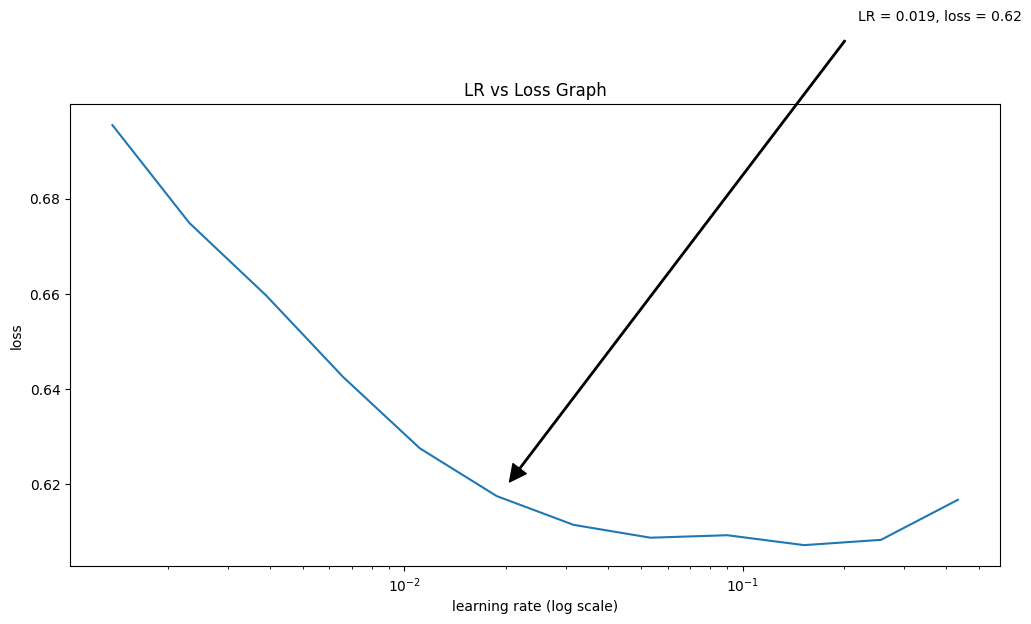

Best learning rates: [(0.019, 5)]
Using best learning rate: 0.019
Epoch 1/50
17/22 [======================>.......] - ETA: 0s - loss: 0.6885 - accuracy: 0.7593
Epoch 1: val_loss improved from inf to 25.65083, saving model to best_model.h5
22/22 [==============================] - 1s 17ms/step - loss: 0.6360 - accuracy: 0.7816 - val_loss: 25.6508 - val_accuracy: 0.6149 - lr: 0.0190
Epoch 2/50
17/22 [======================>.......] - ETA: 0s - loss: 0.4528 - accuracy: 0.8548
Epoch 2: val_loss improved from 25.65083 to 4.87507, saving model to best_model.h5
22/22 [==============================] - 0s 12ms/step - loss: 0.4578 - accuracy: 0.8491 - val_loss: 4.8751 - val_accuracy: 0.6580 - lr: 0.0190
Epoch 3/50
17/22 [======================>.......] - ETA: 0s - loss: 0.4229 - accuracy: 0.8657
Epoch 3: val_loss did not improve from 4.87507
22/22 [==============================] - 0s 11ms/step - loss: 0.4366 - accuracy: 0.8649 - val_loss: 5.0545 - val_accuracy: 0.6178 - lr: 0.0190
Epoch 4/50
17

c:\Users\George Petrog\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Epoch 1/50
21/22 [===========================>..] - ETA: 0s - loss: 0.5874 - accuracy: 0.8027
Epoch 1: val_loss improved from inf to 5.96696, saving model to best_model.h5
22/22 [==============================] - 1s 24ms/step - loss: 0.5807 - accuracy: 0.8046 - val_loss: 5.9670 - val_accuracy: 0.6121 - lr: 0.0190
Epoch 2/50
17/22 [======================>.......] - ETA: 0s - loss: 0.4525 - accuracy: 0.8451
Epoch 2: val_loss did not improve from 5.96696
22/22 [==============================] - 0s 11ms/step - loss: 0.4392 - accuracy: 0.8549 - val_loss: 8.6410 - val_accuracy: 0.6121 - lr: 0.0190
Epoch 3/50
17/22 [======================>.......] - ETA: 0s - loss: 0.4354 - accuracy: 0.8694
Epoch 3: val_loss improved from 5.96696 to 5.34650, saving model to best_model.h5
22/22 [==============================] - 0s 12ms/step - loss: 0.4334 - accuracy: 0.8736 - val_loss: 5.3465 - val_accuracy: 0.6121 - lr: 0.0190
Epoch 4/50
17/22 [======================>.......] - ETA: 0s - loss: 0.4006 - accur

c:\Users\George Petrog\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [9]:
# tf.keras.backend.clear_session()
import tensorflow as tf
print(tf.__version__)
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten,BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
#from keras.optimizers import Adam
from tensorflow.keras.optimizers.legacy import Adam

from sklearn.metrics import classification_report, confusion_matrix
import os
import random as rn
import time
import pywt
import cv2
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import load_img, img_to_array


start_time = time.time()

# reproducable results !!!! , requires: pip install tensorflow-determinism
def setup_seed(seed):
    rn.seed(seed)  
    np.random.seed(seed) 
    tf.random.set_seed(seed)  # tf cpu fix seed
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # tf gpu fix seed,do `pip install tensorflow-determinism` first
#setup_seed(42)
#------------
# Wavelet Transformation Function with region selection
def wavelet_transform(image, region='LL', wavelet='db2', level=3, target_size=(32, 32)):
    wavelet_mode = 'periodization'

    # Applying 3-level DWT to each color channel separately
    C_R = pywt.wavedec2(image[:, :, 0], wavelet, mode=wavelet_mode, level=level)
    C_G = pywt.wavedec2(image[:, :, 1], wavelet, mode=wavelet_mode, level=level)
    C_B = pywt.wavedec2(image[:, :, 2], wavelet, mode=wavelet_mode, level=level)

    # Function to scale coefficients to [0, 255] range
    def scale_coefficients(coeff):
        coeff_min = np.min(coeff)
        coeff_max = np.max(coeff)
        if coeff_max - coeff_min == 0:
            return coeff
        scaled_coeff = 255 * (coeff - coeff_min) / (coeff_max - coeff_min)
        return scaled_coeff

    # Extract and scale the coefficients for each color channel
    CA3_R = scale_coefficients(C_R[0])
    (CH3_R, CV3_R, CD3_R) = [scale_coefficients(c) for c in C_R[-level]]
    CA3_G = scale_coefficients(C_G[0])
    (CH3_G, CV3_G, CD3_G) = [scale_coefficients(c) for c in C_G[-level]]
    CA3_B = scale_coefficients(C_B[0])
    (CH3_B, CV3_B, CD3_B) = [scale_coefficients(c) for c in C_B[-level]]

    # Create a single RGB image for each coefficient plot
    def create_rgb_image(channel_r, channel_g, channel_b):
        h, w = channel_r.shape
        rgb_image = np.zeros((h, w, 3), dtype=np.uint8)
        rgb_image[:, :, 0] = channel_r
        rgb_image[:, :, 1] = channel_g
        rgb_image[:, :, 2] = channel_b
        return rgb_image

    # Choose the appropriate region
    if region == 'LL':
        transformed_image = create_rgb_image(CA3_R, CA3_G, CA3_B)
    elif region == 'LH':
        transformed_image = create_rgb_image(CH3_R, CH3_G, CH3_B)
    elif region == 'HL':
        transformed_image = create_rgb_image(CV3_R, CV3_G, CV3_B)
    elif region == 'HH':
        transformed_image = create_rgb_image(CD3_R, CD3_G, CD3_B)
    else:
        raise ValueError("Invalid region specified. Choose from 'LL', 'LH', 'HL', 'HH'.")

    # Resize the transformed image to the target size
    #transformed_image = cv2.resize(transformed_image, target_size)

    return transformed_image


# Set up ImageDataGenerator with dynamic region parameter
#def create_datagen_with_wavelet(region):
#    return ImageDataGenerator(preprocessing_function=lambda x: custom_preprocess_function(x, region=region))    
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input
datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)

def create_datagen_with_wavelet(region, wavelet='db2', level=3, target_size=(32, 32), preprocessing_function=True):
    def wavelet_transform_function(img):
        return wavelet_transform(img, region=region, wavelet=wavelet, level=level, target_size=target_size)

    if preprocessing_function:
        datagen = ImageDataGenerator(
            preprocessing_function=mobilenet_preprocess_input
        )
    else:
        datagen = ImageDataGenerator(
            preprocessing_function=wavelet_transform_function
        )

    return datagen

def create_cnn_model(input_shape):
    #"""
    model = Sequential()
    model.add(Conv2D(8, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    #"""
    
    """
    model = Sequential()
    model.add(Conv2D(4, (1, 1), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(8, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Conv2D(16, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    #model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    """
    """
    from tensorflow.keras.applications import MobileNetV3Large
    base_model = MobileNetV3Large(include_top=False, input_shape=(img_width,img_height, 3))
    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
     # Ensure the classification layer is trainable
    model.layers[-1].trainable = True
    """
    #model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])
    
    return model
    
def compute_residuals(y_true, y_pred):
    return y_true - y_pred

def compute_sample_weights(y_true, y_pred, epsilon=2):
    # Convert predictions to binary class labels
    y_pred_binary = (y_pred >= 0.5).astype(int)
    #print(y_pred_binary)
    
    # Identify misclassified samples
    misclassified = (y_true != y_pred_binary)
    #print("y_true: ",y_true)
    #print("y_pred_binary: ",y_pred_binary)
    
    #print("misclassified: ",len(misclassified))
    # Count the number of misclassified samples
    num_misclassified = np.sum(misclassified)

    # Print the number of misclassified samples
    print(f"Number of misclassified samples: {num_misclassified}")
    
    # Compute residuals
    residuals = np.abs(y_true - y_pred_binary)
    
    # Assign higher weights to misclassified samples
    misclassified_weights = residuals + epsilon
    correct_classified_weights = 1
    weights = np.where(misclassified,  misclassified_weights, correct_classified_weights)
    
    #print("epsilon + residuals: ",residuals + epsilon)
    
    return weights

import os
import numpy as np
import warnings

from keras.callbacks import Callback
from keras import backend as K

import numpy as np
import scipy.ndimage.filters as filters
import scipy.ndimage.morphology as morphology
import pandas as pd


def detect_local_minima(arr):
    # https://stackoverflow.com/questions/4624970/finding-local-maxima-minima-with-numpy-in-a-1d-numpy-array
    # https://stackoverflow.com/questions/3986345/how-to-find-the-local-minima-of-a-smooth-multidimensional-array-in-numpy-efficien
    # https://stackoverflow.com/questions/3684484/peak-detection-in-a-2d-array/3689710#3689710
    """
    Takes an array and detects the troughs using the local maximum filter.
    Returns a boolean mask of the troughs (i.e. 1 when
    the pixel's value is the neighborhood maximum, 0 otherwise)
    """
    # define an connected neighborhood
    # http://www.scipy.org/doc/api_docs/SciPy.ndimage.morphology.html#generate_binary_structure
    neighborhood = morphology.generate_binary_structure(len(arr.shape), 2)
    # apply the local minimum filter; all locations of minimum value
    # in their neighborhood are set to 1
    # http://www.scipy.org/doc/api_docs/SciPy.ndimage.filters.html#minimum_filter
    local_min = (filters.minimum_filter(arr, footprint=neighborhood) == arr)
    # local_min is a mask that contains the peaks we are
    # looking for, but also the background.
    # In order to isolate the peaks we must remove the background from the mask.
    #
    # we create the mask of the background
    background = (arr == 0)
    #
    # a little technicality: we must erode the background in order to
    # successfully subtract it from local_min, otherwise a line will
    # appear along the background border (artifact of the local minimum filter)
    # http://www.scipy.org/doc/api_docs/SciPy.ndimage.morphology.html#binary_erosion
    eroded_background = morphology.binary_erosion(
        background, structure=neighborhood, border_value=1)
    #
    # we obtain the final mask, containing only peaks,
    # by removing the background from the local_min mask
    detected_minima = local_min ^ eroded_background
    return np.where(detected_minima)


def moving_average_fast(x, w):
    # https://stackoverflow.com/questions/14313510/how-to-calculate-moving-average-using-numpy
    return np.convolve(np.array(x), np.ones(w), 'same') / w


def moving_average(x, w):
    df = pd.DataFrame({"x": x})
    return df.rolling(w, win_type=None, min_periods=1, center=True).mean()['x'].values

def get_derivatives(vals, sma=10):
    assert sma >= 1
    derivatives = [0] * sma
    losses = moving_average(vals, 5)
    for i in range(sma, len(vals)):
        derivatives.append((losses[i] - losses[i - sma]) / sma)
    return derivatives


from matplotlib import pyplot as plt
import math
from keras.callbacks import LambdaCallback
import keras.backend as K
import numpy as np


class LRFinder:
    """
    Plots the change of the loss function of a Keras model when the learning rate is exponentially increasing.
    See for details:
    https://towardsdatascience.com/estimating-optimal-learning-rate-for-a-deep-neural-network-ce32f2556ce0
    """

    def __init__(self, model, num_validation_batches=10):
        self.model = model
        self.losses = []
        self.acc = []
        self.lrs = []
        self.best_loss = 1e9
        self.best_acc = 0
        self.one_minus_acc = []
        self.one_minus_acc_best = []
        self.num_validation_batches = num_validation_batches
        self.validation_set = None
        self.validation_generator = None
        self.best_lrs = []  

    def on_batch_end(self, batch, logs):
        # Log the learning rate
        lr = K.get_value(self.model.optimizer.lr)
        self.lrs.append(lr)

        # Log the loss
        loss = logs['loss']
        acc = logs['accuracy']  # Changed from 'acc' to 'accuracy'

        self.losses.append(loss)
        self.acc.append(acc)
        self.one_minus_acc.append(1 - acc)

        # Check whether the loss got too large or NaN
        if batch > 16 and (math.isnan(loss) or loss > self.best_loss * 10):
            self.model.stop_training = True
            print("Stop Training at %s, loss = %.3f" % (batch, loss))
            return

        if loss < self.best_loss:
            self.best_loss = loss
        if acc > self.best_acc:
            self.best_acc = acc

        # Increase the learning rate for the next batch
        lr *= self.lr_mult
        K.set_value(self.model.optimizer.lr, lr)

    # Rest of the LRFinder class remains unchanged...

    def find(self, x_train, y_train, start_lr, end_lr,
             x_test=None, y_test=None,
             batch_size=64, epochs=1):
        num_batches = epochs * x_train.shape[0] / batch_size
        self.lr_mult = (float(end_lr) / float(start_lr)) ** (float(1) / float(num_batches))

        # Save weights into a file
        self.model.save_weights('tmp.h5')

        # Remember the original learning rate
        original_lr = K.get_value(self.model.optimizer.lr)

        # Set the initial learning rate
        K.set_value(self.model.optimizer.lr, start_lr)

        callback = LambdaCallback(on_batch_end=lambda batch, logs: self.on_batch_end(batch, logs))
        self.validation_set = (x_test, y_test) if x_test is not None and y_test is not None else None
        self.batch_size = batch_size

        self.model.fit(x_train, y_train,
                       batch_size=batch_size, epochs=epochs,
                       verbose=0,
                       callbacks=[callback])

        # Restore the weights to the state before model fitting
        self.model.load_weights('tmp.h5')

        # Restore the original learning rate
        K.set_value(self.model.optimizer.lr, original_lr)

    def find_generator(self, generator, start_lr, end_lr,
                       test_generator=None,
                       epochs=1, steps_per_epoch=None, **kw_fit):
        if steps_per_epoch is None:
            try:
                steps_per_epoch = len(generator)
            except (ValueError, NotImplementedError) as e:
                raise e('`steps_per_epoch=None` is only valid for a'
                        ' generator based on the '
                        '`keras.utils.Sequence`'
                        ' class. Please specify `steps_per_epoch` '
                        'or use the `keras.utils.Sequence` class.')
        self.lr_mult = (float(end_lr) / float(start_lr)) ** (float(1) / float(steps_per_epoch * epochs))
        

        # Save weights into a file
        self.model.save_weights('tmp.h5')

        # Remember the original learning rate
        original_lr = K.get_value(self.model.optimizer.lr)

        # Set the initial learning rate
        K.set_value(self.model.optimizer.lr, start_lr)

        callback = LambdaCallback(on_batch_end=lambda batch,
                                                      logs: self.on_batch_end(batch, logs))

        self.validation_generator = test_generator

        self.model.fit_generator(generator=generator,
                                 epochs=epochs,
                                 steps_per_epoch=steps_per_epoch,
                                 callbacks=[callback],
                                 verbose=0,
                                 **kw_fit)

        # Restore the weights to the state before model fitting
        self.model.load_weights('tmp.h5')

        # Restore the original learning rate
        K.set_value(self.model.optimizer.lr, original_lr)

    def plot_loss(self, n_skip_beginning=5, n_skip_end=5, sma=5):
        self.__plot__(n_skip_beginning,n_skip_end,sma,use_acc=False)
        

    def plot_one_minus_acc(self, n_skip_beginning=5, n_skip_end=5, sma=20):
        self.__plot__(n_skip_beginning,n_skip_end,sma,use_acc=True)

    def __plot__(self, n_skip_beginning=5, n_skip_end=5, sma=10, use_acc=False):
        fig = plt.figure(figsize=(12, 6))
        ax = fig.add_subplot(111)
        y_label = "1 - Acc" if use_acc else "loss"
        plt.ylabel(y_label)
        plt.xlabel("learning rate (log scale)")

        losses = self.losses if not use_acc else self.one_minus_acc
        losses = moving_average(losses, sma)
        losses = losses[n_skip_beginning:-n_skip_end]

        plt.plot(self.lrs[n_skip_beginning:-n_skip_end], losses)
        plt.xscale('log')

        # Get the best learning rates
        self.best_lrs = self.get_best_lrs(sma, use_acc=use_acc)  # Store best_lrs
        lrs = [x for x, _ in self.best_lrs]
        positions = [x for _, x in self.best_lrs]

        # Add annotations for the best learning rates
        if self.best_lrs:
            for lr, pos in self.best_lrs:
                ax.annotate(
                    f'LR = {lr:.3f}, {y_label} = {losses[pos]:.2f}',
                    xy=(lr, losses[pos]),
                    xytext=(lr + 0.2, losses[pos] + 0.1),
                    arrowprops=dict(facecolor='black', shrink=0.03, width=1, frac=0.05),
                )

        title = "LR vs 1 - Acc Graph" if use_acc else "LR vs Loss Graph"
        plt.title(title)
        plt.show()

    def get_best_learning_rates(self):
        """Return the best learning rates found during the search."""
        return self.best_lrs

    def __get_best_lr_method1__(self, sma=20, n_skip_beginning=10, n_skip_end=5, use_acc=False):
        losses = self.losses if not use_acc else self.one_minus_acc
        derivatives = get_derivatives(losses, sma)
        losses = np.array(losses[n_skip_beginning:-n_skip_end])
        derivatives = derivatives[n_skip_beginning:-n_skip_end]
        lrs = self.lrs[n_skip_beginning:-n_skip_end]

        # Debugging: Print lengths of arrays
        print(f"Length of losses: {len(losses)}")
        print(f"Length of derivatives: {len(derivatives)}")
        print(f"Length of lrs: {len(lrs)}")

        best_loss = (1 - self.best_acc) if use_acc else self.best_loss
        acceptable_idxs = np.where(losses <= best_loss * 1.75)[0]

        # Debugging: Print acceptable_idxs
        print(f"Acceptable indices: {acceptable_idxs}")

        # Ensure there are enough data points
        if len(acceptable_idxs) == 0:
            print("No acceptable indices found. Returning empty lists.")
            return [], []

        derivatives = derivatives[acceptable_idxs[0]:acceptable_idxs[-1]]

        # Debugging: Print derivatives after slicing
        print(f"Derivatives after slicing: {derivatives}")

        # Ensure there are enough data points for partitioning
        if len(derivatives) < 5:
            print("Not enough derivatives for partitioning. Returning empty lists.")
            return [], []

        best_idxs = np.argpartition(derivatives, -5)[-5:]
        best_idxs = best_idxs - sma + acceptable_idxs[0]

        # Debugging: Print best_idxs before bounds checking
        print(f"Best indices before bounds checking: {best_idxs}")

        # Ensure indices are within bounds
        best_idxs = best_idxs[(best_idxs >= 0) & (best_idxs < len(losses))]

        # Debugging: Print best_idxs after bounds checking
        print(f"Best indices after bounds checking: {best_idxs}")

        if len(best_idxs) == 0:
            print("No valid indices after bounds checking. Returning empty lists.")
            return [], []

        acceptable_loss_or_not = losses[best_idxs] <= best_loss * 1.5
        best_idxs = best_idxs[acceptable_loss_or_not]

        # Debugging: Print best_idxs after filtering by acceptable loss
        print(f"Best indices after filtering by acceptable loss: {best_idxs}")

        if len(best_idxs) == 0:
            print("No valid indices after filtering by acceptable loss. Returning empty lists.")
            return [], []

        acceptable_loss_or_not = losses[best_idxs + sma] > (losses[best_idxs] * 1.0)
        best_idxs = best_idxs[acceptable_loss_or_not]

        # Debugging: Print best_idxs after final filtering
        print(f"Best indices after final filtering: {best_idxs}")

        if len(best_idxs) == 0:
            print("No valid indices after final filtering. Returning empty lists.")
            return [], []

        candidates = list(np.array(lrs)[best_idxs])
        return sorted(candidates), best_idxs

    def get_best_lrs(self, sma=20, n_skip_beginning=5, n_skip_end=5, use_acc=False):
        c1, i1 = self.__get_best_lr_method1__(sma, n_skip_beginning, n_skip_end, use_acc)
        
        # Handle empty candidates
        if not c1:
            print("No valid candidates found. Returning default learning rate.")
            return [(0.001, 0)]  # Default learning rate and index
        
        candidates = list(zip(c1, i1))
        candidates = sorted(candidates, key=lambda pair: pair[0])
        
        final_candidates = [candidates[0]]
        for v, i in candidates:
            if (v - final_candidates[-1][0]) / final_candidates[-1][0] > 0.2:
                final_candidates.append((v, i))
        
        final_candidates = list(map(lambda pair: (float("%.3f" % pair[0]), pair[1]), final_candidates))

        print()

        return final_candidates

class ResidualDataGenerator(Sequence):
    def __init__(self, data_generator, sample_weights):
        self.data_generator = data_generator
        self.sample_weights = sample_weights

    def __len__(self):
        return len(self.data_generator)

    def __getitem__(self, index):
        x_batch, y_batch = self.data_generator[index]
        return x_batch, y_batch, self.sample_weights[index * self.data_generator.batch_size:(index + 1) * self.data_generator.batch_size]

def train_gradient_boosting(num_folds, input_shape, learning_rate, mode, level, img_width, img_height, batch_size, epochs, all_images_train, all_labels_train,all_images_val,all_labels_val, testing_path1, index):
    models = []
    histories = []
    from sklearn.model_selection import StratifiedKFold
    
    # Initialize weights to 1 for all samples
    #sample_weights = np.ones(len(all_labels))
    
    #kfold = StratifiedKFold(n_splits=num_folds, shuffle=False)
    regions = ['LL', 'LH', 'HL', 'HH']

    #for fold_index, (train_idx, val_idx) in enumerate(kfold.split(all_images, all_labels)):
    #i = fold_index % len(regions)

    #print(f"--> Starting Fold {fold_index+1}/{num_folds} with region: {regions[i]}")


    #print("- Training samples: ", len(y_train_fold))
    #print("- Validation samples: ", len(y_val_fold))

    train_generator = create_datagen_with_wavelet(regions[0], mode, level).flow(all_images_train, all_labels_train, batch_size=batch_size, shuffle=True)
    valid_generator = create_datagen_with_wavelet(regions[0], mode, level).flow(all_images_val, all_labels_val, batch_size=batch_size, shuffle=False)

    #residuals_generator = ResidualDataGenerator(train_generator, sample_weights[train_idx])

    model = create_cnn_model(input_shape)

    if(index == 0):
        model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])

        lrf = LRFinder(model)
        #generator = datagen.flow(X_train, Y_train, batch_size=256,shuffle=True)
        #test_generator = datagen_validation.flow(X_test, Y_test, batch_size=256, shuffle=True)
        lrf.find_generator(train_generator, 0.0001, 10.0,valid_generator, epochs=1, steps_per_epoch=None,)
        lrf.plot_loss()

        # Get the best learning rates
        best_lrs = lrf.get_best_learning_rates()
        print(f"Best learning rates: {best_lrs}")

        # Use the best learning rate for training
        if best_lrs:
            best_lr = best_lrs[0][0]  # Use the first (best) learning rate
            print(f"Using best learning rate: {best_lr}")

        learning_rate = best_lr

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
        
    checkpoint = ModelCheckpoint(f"best_model.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)

    # Train the model with sample weights
    history = model.fit(
        train_generator,
        validation_data=valid_generator,
        epochs=epochs,
        callbacks=[checkpoint, early_stopping,lr_schedule],
        verbose=1
    )

    # Predict on training and validation data
    y_pred_train = model.predict(train_generator).flatten()
    y_pred_val = model.predict(valid_generator).flatten()

    # Compute weights based on misclassified samples
    #weights_train = compute_sample_weights(y_train_fold, y_pred_train,1.5)
    #weights_val = compute_sample_weights(y_val_fold, y_pred_val,1.5)

    # Apply higher weights to misclassified samples
    #sample_weights[train_idx] = weights_train
    #sample_weights[val_idx] = weights_val
    
    # Predict on validation data
    val_pred_test_model = model.predict(valid_generator)
    val_pred_test_model = np.where(val_pred_test_model > 0.5, 1, 0)

    val_true = all_labels_val

    # Evaluate results
    target_names = ['Malware', 'Software']
    print('Confusion Matrix')
    print(confusion_matrix(val_true, val_pred_test_model))
    print('Classification Report')
    print(classification_report(val_true, val_pred_test_model, target_names=target_names, zero_division=1, digits=5))

    """ #test right after validation set
    test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
        testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)
    y_pred_test_model = model.predict(test_generator, test_generator.n // batch_size + 1)
    Y_pred_test = y_pred_test_model
    y_pred_test_model = np.where(y_pred_test_model > 0.5, 1, 0)
    #cm = confusion_matrix(test_generator.classes, test_labels)
    #print(cm)
    #print("test_labels: ",test_labels)
    test_labels = y_pred_test_model
    print(test_generator.class_indices)
    summ = 0 
    print("------------------")
    for i in range (0,len(test_generator.filenames)):
        detection_status = "Undetected      " if y_pred_test_model[i] > 0.5 else "Detected Malware"
        print(detection_status,"-",test_labels[i],"-","{:.8f}".format(Y_pred_test[i][0])," - ",test_generator.filenames[i])
        summ = summ + Y_pred_test[i][0]
    print("------------------")
    print("-> Avg malware accuracy: ",summ/13)
    """

    models.append(model)
    histories.append(history)
    
    return models, histories


def gradient_boosting_predict(models, test_generator):
    num_samples = test_generator.samples
    batch_size = test_generator.batch_size
    predictions_matrix = np.zeros((num_samples, len(models)))

    for idx, model in enumerate(models):
        #print(idx)
        y_pred_list = []
        steps = num_samples // batch_size + (num_samples % batch_size != 0)
        
        for _ in range(steps):
            x_batch, _ = test_generator.next()
            y_pred_batch = model.predict(x_batch)
            y_pred_list.append(y_pred_batch)
        
        y_pred = np.concatenate(y_pred_list)
        
        # Ensure that predictions array is aligned
        if y_pred.shape[0] != num_samples:
            raise ValueError(f"Mismatch in prediction shape: {y_pred.shape[0]} != {num_samples}")
        
        predictions_matrix[:, idx] = y_pred.flatten()
    
    #each line, per sample for all models 
    print(predictions_matrix)
    
    #print("-> Avg malware accuracy: ",sum(y_pred)/13)
    # Check if any model's prediction is correct for each sample
    final_predictions = np.zeros(num_samples)
    true_labels = test_generator.classes
    for i in range(num_samples):
        # Compute distances from the true label (1 or 0)
        distances = np.abs(predictions_matrix[i] - true_labels[i])
        # Find the index of the minimum distance
        closest_model_index = np.argmin(distances)
        #print(closest_model_index)
        # Save the probability of the closest model
        final_predictions[i] = predictions_matrix[i][closest_model_index]
    
    print(final_predictions)

    return final_predictions

def load_images_and_labels(directory_path, target_size):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory_path))  # List all subdirectories (class names)
    
    for class_name in class_names:
        class_path = os.path.join(directory_path, class_name)
        if not os.path.isdir(class_path):
            continue
        image_files = [os.path.join(class_path, fname) for fname in os.listdir(class_path) if fname.endswith(('.png', '.jpg', '.jpeg'))]
        
        for image_file in image_files:
            img = load_img(image_file, target_size=target_size)
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(class_name)  # Append the class label
            
    images = np.array(images)
    labels = np.array(labels)
    
    # Ensure that images and labels have the same length
    if len(images) != len(labels):
        raise ValueError(f"Number of images ({len(images)}) does not match number of labels ({len(labels)}).")
        
    #encode labels
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(labels)
    
    return images, labels

#import sys
#old_stdout = sys.stdout # keep reference to existing stdout
#sys.stdout = open('logfile.txt', 'w')

accuracies = []
for i in range(2):
    # Load data
    seed = i
    setup_seed(seed)
    img_width, img_height = 256,1024
    level = 3
    mode = 'db2'
    batch_size = 32
    input_shape = (img_width, img_height, 3)
    num_learners = 12 #not actually used here, we only have 1 model here
    epochs = 50
    learning_rate = 0.019  # A smaller learning rate for updating predictions
    #train_dataset1 = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_48240\\latest\\Data_48240_train_test_only\\Training'
    #testing_path1  = 'E:\\PTIXIAKI\\Malware Visualisation\\Data_48240\\latest\\Data_48240_train_test_only\\Test'
    train_dataset1 = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20\\Training'
    valid_dataset1 = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20\\Validation'
    testing_path1  = 'C:\\Users\\George Petrog\\Documents\\Projects\\DL\\PTIXIAKI\\Data_913\\latest\\data913_80_20\\Test'


    img_width = img_width // (2 ** level)
    img_height = img_height // (2 ** level)

    print(f"Wavelet Level: {level} - New dimensions: {img_width}x{img_height}")

    all_images_train, all_labels_train = load_images_and_labels(train_dataset1, target_size=(img_width, img_height))
    all_images_val, all_labels_val = load_images_and_labels(train_dataset1, target_size=(img_width, img_height))

    # Train Gradient Boosting
    models, histories = train_gradient_boosting(
        num_folds=num_learners,  # Number of folds, corresponds to the number of regions (LL, LH, HL, HH)
        input_shape=(img_width, img_height, 3),
        learning_rate=learning_rate,
        mode=mode,
        level=level,
        img_width=img_width,
        img_height=img_height,
        batch_size=batch_size,
        epochs=epochs,
        all_images_train= all_images_train,
        all_labels_train = all_labels_train,
        all_images_val= all_images_val,
        all_labels_val = all_labels_val,
        testing_path1=testing_path1,  # Path to the testing dataset
        index= i
    )

    # Predict on test set
    test_generator = create_datagen_with_wavelet('LL',mode, level).flow_from_directory(
            testing_path1, target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary', shuffle=False)

    y_pred = gradient_boosting_predict(models, test_generator)

    # DATA_913
    print(test_generator.class_indices)
    print("------------------")
    for i in range(len(test_generator.filenames)):
        detection_status = "Undetected      " if y_pred[i] > 0.5 else "Detected Malware"
        print(f"{detection_status} - {y_pred[i]:.8f} - {test_generator.filenames[i]}")
    print("------------------")
    print("-> Avg malware accuracy: ",sum(y_pred)/13)
    #"""
    
    accuracies.append(sum(y_pred)/13)

    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

    import numpy as np

    # Assuming y_true and y_pred are already obtained
    y_true = test_generator.classes  # Ground truth labels

    class_of_interest = 0  # Assuming Software is class 0, Malware is class 1

    print("y_true: ",y_true)
    y_pred_binary = y_pred
    for i in range(len(test_generator.filenames)):
        y_pred_binary[i] = 1 if y_pred_binary[i] >= 0.5 else 0
    #y_pred_binary = [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] #for testing purposes
    print("y_pred_binary: ",y_pred_binary)
    # Create the classification report only for classes present in y_true
    unique_classes = np.unique(y_true)
    
    labels = unique_classes  # Use only classes present in y_true

    target_names = ['Malware' if cls == 0 else 'Software' for cls in labels]

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred_binary, labels=labels)
    print(f"Confusion Matrix:\n{conf_matrix}")
    class_report = classification_report(y_true, y_pred_binary, labels=labels, target_names=target_names, zero_division=1, digits=5)
    print(class_report)
    # Compute and print accuracy
    #accuracy = accuracy_score(y_true, y_pred_binary)
    #print(f"Accuracy: {accuracy:.5f}")

    print("seed: ",seed)

    # calculate elapesed runtime
    end_time = time.time()
    runtime_seconds = end_time - start_time
    runtime_minutes = runtime_seconds / 60
    runtime_hours = runtime_minutes / 60
    print(f"\nTotal Runtime: {int(runtime_hours)} hours, {int(runtime_minutes % 60)} minutes.")
    # 10 epochs with lr = 0.01
    
    #from IPython.core.display import HTML
    #HTML("<script>Jupyter.notebook.kernel.restart()</script>")
    
    print("###################################")
    
average = sum(accuracies) / len(accuracies)

# Print the average with 6 decimal places
print(f"{average:.6f}")
#sys.stdout = old_stdout # restore stdout